In [ ]:
#!/usr/bin/env python3
"""
Canada-Wide Precipitation Data Scraper — BUENO7 V3.0
(All Provinces & Territories + Quality Audit & ID Verification)
================================================================================

Purpose: Download and audit historical precipitation data from Environment Canada
         with granular failure classification per ECCC's official response.

Author: Adrian Hernandez-del-Valle, PhD
Institution: Services Communautaires pour Réfugiés et Immigrants (SCRI), Montreal
Target: Agricultural insurance research & Minister Julie Dabrusin's office evidence

VERSION 2.3 CHANGES (All Provinces & Territories Edition):
-----------------------------------------------------------------------
1. EXPANDED SCOPE: Now covers all 13 Canadian provinces/territories
   - Default provinces list expanded from 4 to 13: all provinces +
     Manitoba, New Brunswick, Newfoundland, Northwest Territories,
     Nova Scotia, Nunavut, Prince Edward Island, Saskatchewan, Yukon
   - Curated anchor stations added for every newly included jurisdiction
   - All report text (titles, scope lines, narrative paragraphs, footers)
     is now driven by scope_str — a variable computed at runtime from
     whichever provinces are actually present in classification_df.
     No province name is hardcoded in the generated reports.
   - Dashboard province_flags dict updated with all 13 entries
   - NOTE: Province name strings must match the ECCC inventory exactly.
     If a jurisdiction shows 0 stations, inspect
     inventory/full_station_inventory.csv for the exact spelling
     (e.g. 'NEWFOUNDLAND' vs 'NEWFOUNDLAND AND LABRADOR',
            'NORTHWEST TERRITORIES' vs 'N.W.T.').
     Update the provinces list in filter_precipitation_stations() to match.

VERSION 2.2 CHANGES (British Columbia Edition):
-----------------------------------------------------------------------
1. ADDED PROVINCE: British Columbia now included alongside Ontario, Quebec & Alberta
   - 10 curated anchor stations added for British Columbia
   - default provinces list updated to ['ONTARIO', 'QUEBEC', 'ALBERTA', 'BRITISH COLUMBIA']
   - All report titles and scope descriptions updated

VERSION 2.1 CHANGES (Alberta Edition):
-----------------------------------------------------------------------
1. ADDED PROVINCE: Alberta now included alongside Ontario & Quebec
   - 10 curated anchor stations added for Alberta
   - default provinces list updated to ['ONTARIO', 'QUEBEC', 'ALBERTA']
   - All report titles and scope descriptions updated (now also includes BC)

2. BUG FIX: DataFrame.get() → proper column existence check in
   filter_precipitation_stations() — the V2 code called
   dly_stations.get('Inventory_Status', '') which is a dict method
   and silently returns the full DataFrame; replaced with a proper
   `'Inventory_Status' in dly_stations.columns` guard.

3. NOTE ON ECCC_NETWORK_STATS: The stats from Minister Dabrusin's
   January 2026 response (280 active AWS, 138 with precip sensors, etc.)
   are specific to Ontario & Quebec. Alberta figures are not yet confirmed
   from a comparable ministerial response. The stats dict is preserved for
   Ontario/QC cross-reference and labelled accordingly.

VERSION 2 CHANGES (per ECCC official response via MP Rachel Bendayan):
-----------------------------------------------------------------------
1. UPDATED DATA SOURCES:
   - Primary: MSC Datamart (https://dd.weather.gc.ca) — ECCC recommended
   - Secondary: Collaboration server for Station Inventory
   - Removed: Obsolete FTP (ftp://ftp.tor.ec.gc.ca) — flagged by ECCC as obsolete

2. EXPANDED COVERAGE:
   - Full inventory scan for Ontario, Quebec & Alberta (not just hardcoded stations)
   - Filters for stations with DAILY TOTAL PRECIPITATION per ECCC guidance
   - Covers ECCC, NAVCAN, DND, and CCN stations

3. GRANULAR FAILURE CLASSIFICATION (per ECCC's 5 categories):
   - DECOMMISSIONED: Station closed (DLY Last Year well in the past)
   - NO_PRECIP_SENSOR: Station exists but no precipitation columns
   - ACTIVE_DATA_MISSING: Listed as active but returning no/empty data
   - ACTIVE_TRANSMISSION_ISSUE: Has some data but with large gaps
   - ACTIVE_FUNCTIONAL: Working correctly

4. PRESERVED FROM V1:
   - Year-by-year quality statistics with NaN tracking
   - Comprehensive audit reports for each station
   - Evidence reports for policy work
   - Station ID verification logic
   - Per-station data download with quality ratings

5. NEW FEATURES (V2):
   - Per-station smart start year (uses DLY First Year, no more 1900 default)
   - Retry logic with exponential backoff
   - Progress estimation
   - ECCC response cross-reference in reports

ECCC REFERENCE DOCUMENT:
  Response from Minister Julie Dabrusin's office (received Jan 2026)
  Key facts cited (Ontario & Quebec only):
    - ~280 active AWS in Ontario & Quebec
    - ECCC operates 174 AWS (138 with precipitation sensors)
    - NAVCAN operates ~100 stations
    - 36 CCN stations with daily precipitation as of Jan 2026
    - ~256 stations operated by Government of Quebec (MELCCFP)

Google Colab Usage:
    # Run all cells, then:
    scraper, results = run_full_audit(max_stations=50)
"""

# =============================================================================
# IMPORTS
# =============================================================================
import requests
import pandas as pd
import json
import time
import os
import re
import warnings
import traceback
from datetime import datetime, timedelta
from io import StringIO
from collections import defaultdict

warnings.filterwarnings('ignore')

# For Google Colab — ensure output dirs persist
try:
    from google.colab import files as colab_files
    IN_COLAB = True
    print("✓ Running in Google Colab")
except ImportError:
    IN_COLAB = False

# =============================================================================
# CONFIGURATION
# =============================================================================
ECCC_BULK_DATA_URL = "https://climate.weather.gc.ca/climate_data/bulk_data_e.html"

# ECCC-recommended station inventory sources (replaces obsolete FTP)
INVENTORY_SOURCES = [
    {
        'name': 'Collaboration Server (Primary)',
        'url': 'https://collaboration.cmc.ec.gc.ca/cmc/climate/Get_More_Data_Plus_de_donnees/Station%20Inventory%20EN.csv',
        'type': 'http'
    },
    {
        'name': 'DD Weather (MSC Datamart mirror)',
        'url': 'https://dd.weather.gc.ca/climate/observations/climate_station_list_en.csv',
        'type': 'http'
    }
]

# ECCC-stated network statistics (from Minister's response, Jan 2026)
# NOTE: These figures cover Ontario & Quebec only.
# Alberta statistics are not yet confirmed from a comparable ministerial response.
ECCC_NETWORK_STATS = {
    'scope': 'Ontario & Quebec only (Minister response Jan 2026)',
    'total_active_aws_ont_qc': 280,
    'eccc_aws': 174,
    'eccc_aws_with_precip': 138,
    'navcan_stations': 100,
    'ccn_stations_with_precip': 36,
    'quebec_melccfp_stations': 256,
    'source': "Minister Julie Dabrusin's office response, Jan 2026"
}

# Classification thresholds
DECOMMISSION_THRESHOLD_YEAR = 2018  # If DLY Last Year < this, consider decommissioned
RECENT_DATA_THRESHOLD_YEAR = 2023   # For "recent data" checks
DATA_GAP_THRESHOLD_PERCENT = 30     # >30% NaN in a year = data gap


class CanadaPrecipitationScraperV2:
    """
    BUENO7 V3.0 — Canada-Wide Precipitation Data Scraper
    with Quality Audit & Station ID Verification.

    Implements ECCC-aligned failure classification per Minister Dabrusin's
    January 2026 response, now extended to all 13 provinces and territories.

    Improvements over V1:
    - Uses ECCC-recommended data sources (not obsolete FTP)
    - Scans full inventory for all 13 provinces/territories
    - Classifies failures per ECCC's 5 categories
    - Smart per-station start years (DLY First Year from inventory)
    - Retry logic with exponential backoff
    """

    def __init__(self, output_dir='precipitation_audit_v2'):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Research; CanadaPrecipAudit/3.0)'
        })

        # Directory structure
        self.output_dir = output_dir
        self.data_dir = os.path.join(output_dir, 'data')
        self.reports_dir = os.path.join(output_dir, 'reports')
        self.verification_dir = os.path.join(output_dir, 'verification')
        self.inventory_dir = os.path.join(output_dir, 'inventory')

        for d in [self.output_dir, self.data_dir, self.reports_dir,
                  self.verification_dir, self.inventory_dir]:
            os.makedirs(d, exist_ok=True)

        # =====================================================================
        # CURATED STATIONS — All provinces and territories
        # These serve as verified anchor stations for cross-reference.
        # The full inventory scan will find hundreds more, but these anchor
        # the analysis and provide continuity with prior policy reports.
        #
        # STATION ID NOTE: IDs are sourced from the ECCC Climate Data
        # archive and are automatically cross-referenced against the
        # downloaded inventory on every run. Any mismatches are flagged in
        # verification/curated_stations_crossref.csv. The curated list is
        # advisory only — it does NOT control which stations are classified
        # (Step 3 scans the full inventory independently).
        # =====================================================================
        self.curated_stations = {

            # ------------------------------------------------------------------
            # ONTARIO — 15 stations
            # ------------------------------------------------------------------
            'Toronto': {
                'id': 5051, 'name': "Toronto Pearson Int'l A",
                'lat': 43.68, 'lon': -79.63, 'province': 'ONTARIO'
            },
            'Ottawa': {
                'id': 4333, 'name': "Ottawa Macdonald-Cartier Int'l A",
                'lat': 45.38, 'lon': -75.72, 'province': 'ONTARIO'
            },
            'Thunder Bay': {
                'id': 6068, 'name': 'Thunder Bay A',
                'lat': 48.37, 'lon': -89.33, 'province': 'ONTARIO'
            },
            'Windsor': {
                'id': 6139, 'name': 'Windsor A',
                'lat': 42.28, 'lon': -82.96, 'province': 'ONTARIO'
            },
            'London': {
                'id': 4789, 'name': 'London A',
                'lat': 43.03, 'lon': -81.15, 'province': 'ONTARIO'
            },
            'Hamilton': {
                'id': 4374, 'name': 'Hamilton A',
                'lat': 43.26, 'lon': -79.93, 'province': 'ONTARIO'
            },
            'Sudbury': {
                'id': 6021, 'name': 'Sudbury A',
                'lat': 46.63, 'lon': -80.80, 'province': 'ONTARIO'
            },
            'Kingston': {
                'id': 4485, 'name': 'Kingston Pumping Station',
                'lat': 44.22, 'lon': -76.60, 'province': 'ONTARIO'
            },
            'Timmins': {
                'id': 6080, 'name': 'Timmins Victor M. Power',
                'lat': 48.56, 'lon': -81.39, 'province': 'ONTARIO'
            },
            'North Bay': {
                'id': 4924, 'name': 'North Bay A',
                'lat': 46.36, 'lon': -79.42, 'province': 'ONTARIO'
            },
            'Moosonee': {
                'id': 4887, 'name': 'Moosonee UA',
                'lat': 51.29, 'lon': -80.61, 'province': 'ONTARIO'
            },
            'Sault Ste Marie': {
                'id': 5990, 'name': 'Sault Ste Marie A',
                'lat': 46.49, 'lon': -84.51, 'province': 'ONTARIO'
            },
            'Kapuskasing': {
                'id': 4464, 'name': 'Kapuskasing A',
                'lat': 49.41, 'lon': -82.47, 'province': 'ONTARIO'
            },
            'Kenora': {
                'id': 4467, 'name': 'Kenora A',
                'lat': 49.79, 'lon': -94.38, 'province': 'ONTARIO'
            },
            'Trenton': {
                'id': 6108, 'name': 'Trenton A',
                'lat': 44.11, 'lon': -77.53, 'province': 'ONTARIO'
            },

            # ------------------------------------------------------------------
            # QUEBEC — 9 stations
            # ------------------------------------------------------------------
            'Montreal': {
                'id': 30165, 'name': 'Montreal/Pierre Elliott Trudeau Intl',
                'lat': 45.47, 'lon': -73.74, 'province': 'QUEBEC'
            },
            'Quebec City': {
                'id': 26892, 'name': 'Quebec/Jean Lesage Intl',
                'lat': 46.80, 'lon': -71.38, 'province': 'QUEBEC'
            },
            'Sherbrooke': {
                'id': 48371, 'name': 'Sherbrooke',
                'lat': 45.44, 'lon': -71.69, 'province': 'QUEBEC'
            },
            'Trois-Rivieres': {
                'id': 10764, 'name': 'Trois-Rivieres',
                'lat': 46.35, 'lon': -72.52, 'province': 'QUEBEC'
            },
            "Val-d'Or": {
                'id': 6081, 'name': "Val-d'Or A",
                'lat': 48.06, 'lon': -77.79, 'province': 'QUEBEC'
            },
            'Sept-Iles': {
                'id': 42683, 'name': 'Sept-Iles',
                'lat': 50.22, 'lon': -66.25, 'province': 'QUEBEC'
            },
            'Bagotville': {
                'id': 5889, 'name': 'Bagotville A',
                'lat': 48.33, 'lon': -71.00, 'province': 'QUEBEC'
            },
            'Kuujjuaq': {
                'id': 52179, 'name': 'Kuujjuaq A',
                'lat': 58.09, 'lon': -68.42, 'province': 'QUEBEC'
            },
            'Rouyn-Noranda': {
                'id': 50090, 'name': 'Rouyn-Noranda A',
                'lat': 48.21, 'lon': -78.84, 'province': 'QUEBEC'
            },

            # ------------------------------------------------------------------
            # ALBERTA — 10 stations
            # Geographic coverage: south (Lethbridge/Medicine Hat) → central
            # (Calgary/Red Deer/Edmonton) → north (Grande Prairie/Fort McMurray)
            # + mountain (Banff) + eastern agricultural belt (Cold Lake/Peace River)
            #
            # IDs are cross-referenced automatically against the ECCC inventory
            # on each run; mismatches appear in verification/curated_stations_crossref.csv
            # ------------------------------------------------------------------
            'Calgary': {
                'id': 2205, 'name': "Calgary Int'l A",
                'lat': 51.12, 'lon': -114.02, 'province': 'ALBERTA'
            },
            'Edmonton': {
                'id': 1865, 'name': "Edmonton City Centre A",
                'lat': 53.57, 'lon': -113.52, 'province': 'ALBERTA'
            },
            'Edmonton Intl': {
                'id': 1860, 'name': "Edmonton Int'l A",
                'lat': 53.31, 'lon': -113.58, 'province': 'ALBERTA'
            },
            'Lethbridge': {
                'id': 2263, 'name': 'Lethbridge A',
                'lat': 49.63, 'lon': -112.80, 'province': 'ALBERTA'
            },
            'Medicine Hat': {
                'id': 2317, 'name': 'Medicine Hat A',
                'lat': 50.02, 'lon': -110.72, 'province': 'ALBERTA'
            },
            'Red Deer': {
                'id': 2407, 'name': 'Red Deer Regional A',
                'lat': 52.18, 'lon': -113.89, 'province': 'ALBERTA'
            },
            'Grande Prairie': {
                'id': 2100, 'name': 'Grande Prairie A',
                'lat': 55.18, 'lon': -118.88, 'province': 'ALBERTA'
            },
            'Fort McMurray': {
                'id': 2496, 'name': 'Fort McMurray A',
                'lat': 56.65, 'lon': -111.22, 'province': 'ALBERTA'
            },
            'Banff': {
                'id': 2202, 'name': 'Banff CS',
                'lat': 51.19, 'lon': -115.55, 'province': 'ALBERTA'
            },
            'Peace River': {
                'id': 2368, 'name': 'Peace River A',
                'lat': 56.23, 'lon': -117.44, 'province': 'ALBERTA'
            },
            # ------------------------------------------------------------------
            # BRITISH COLUMBIA — 10 stations
            # Geographic coverage: south coast (Vancouver/Victoria/Abbotsford)
            # → southern interior (Kelowna/Penticton/Cranbrook)
            # → central interior (Kamloops/Prince George)
            # → northwest (Terrace/Prince Rupert)
            #
            # IDs are cross-referenced automatically against the ECCC inventory
            # on each run; mismatches appear in verification/curated_stations_crossref.csv
            # ------------------------------------------------------------------
            'Vancouver': {
                'id': 889, 'name': "Vancouver Int'l A",
                'lat': 49.19, 'lon': -123.18, 'province': 'BRITISH COLUMBIA'
            },
            'Victoria': {
                'id': 1018, 'name': "Victoria Int'l A",
                'lat': 48.65, 'lon': -123.43, 'province': 'BRITISH COLUMBIA'
            },
            'Kelowna': {
                'id': 1120, 'name': 'Kelowna A',
                'lat': 49.96, 'lon': -119.38, 'province': 'BRITISH COLUMBIA'
            },
            'Kamloops': {
                'id': 1163, 'name': 'Kamloops A',
                'lat': 50.70, 'lon': -120.44, 'province': 'BRITISH COLUMBIA'
            },
            'Prince George': {
                'id': 1274, 'name': 'Prince George A',
                'lat': 53.89, 'lon': -122.68, 'province': 'BRITISH COLUMBIA'
            },
            'Abbotsford': {
                'id': 737, 'name': 'Abbotsford A',
                'lat': 49.03, 'lon': -122.36, 'province': 'BRITISH COLUMBIA'
            },
            'Cranbrook': {
                'id': 1265, 'name': 'Cranbrook A',
                'lat': 49.61, 'lon': -115.78, 'province': 'BRITISH COLUMBIA'
            },
            'Terrace': {
                'id': 1393, 'name': 'Terrace A',
                'lat': 54.47, 'lon': -128.57, 'province': 'BRITISH COLUMBIA'
            },
            'Prince Rupert': {
                'id': 1334, 'name': 'Prince Rupert A',
                'lat': 54.28, 'lon': -130.44, 'province': 'BRITISH COLUMBIA'
            },
            'Penticton': {
                'id': 1240, 'name': 'Penticton A',
                'lat': 49.47, 'lon': -119.60, 'province': 'BRITISH COLUMBIA'
            },

            # ------------------------------------------------------------------
            # MANITOBA — 5 stations
            # Geographic coverage: south (Winnipeg/Brandon) → central
            # (Portage la Prairie) → north (Thompson/Churchill)
            # IDs cross-referenced against ECCC inventory on each run.
            # ------------------------------------------------------------------
            'Winnipeg': {
                'id': 3698, 'name': "Winnipeg/James Armstrong Richardson Int'l A",
                'lat': 49.91, 'lon': -97.24, 'province': 'MANITOBA'
            },
            'Churchill': {
                'id': 3561, 'name': 'Churchill A',
                'lat': 58.74, 'lon': -94.06, 'province': 'MANITOBA'
            },
            'Brandon': {
                'id': 3471, 'name': 'Brandon A',
                'lat': 49.91, 'lon': -99.95, 'province': 'MANITOBA'
            },
            'Thompson MB': {
                'id': 3781, 'name': 'Thompson A',
                'lat': 55.80, 'lon': -97.86, 'province': 'MANITOBA'
            },
            'Portage la Prairie': {
                'id': 3577, 'name': 'Portage la Prairie A',
                'lat': 49.91, 'lon': -98.27, 'province': 'MANITOBA'
            },

            # ------------------------------------------------------------------
            # NEW BRUNSWICK — 5 stations
            # Geographic coverage: southwest (Saint John/Fredericton)
            # → east coast (Moncton/Miramichi) → north (Charlo)
            # ------------------------------------------------------------------
            'Fredericton': {
                'id': 6159, 'name': 'Fredericton A',
                'lat': 45.87, 'lon': -66.53, 'province': 'NEW BRUNSWICK'
            },
            'Moncton': {
                'id': 6259, 'name': 'Moncton A',
                'lat': 46.11, 'lon': -64.68, 'province': 'NEW BRUNSWICK'
            },
            'Saint John NB': {
                'id': 6323, 'name': 'Saint John A',
                'lat': 45.32, 'lon': -65.88, 'province': 'NEW BRUNSWICK'
            },
            'Charlo': {
                'id': 6125, 'name': 'Charlo A',
                'lat': 47.99, 'lon': -66.33, 'province': 'NEW BRUNSWICK'
            },
            'Miramichi': {
                'id': 6137, 'name': 'Chatham A',
                'lat': 47.01, 'lon': -65.46, 'province': 'NEW BRUNSWICK'
            },

            # ------------------------------------------------------------------
            # NEWFOUNDLAND — 5 stations
            # NOTE: ECCC inventory uses 'NEWFOUNDLAND' (short form).
            # If 0 stations appear, check whether the inventory uses
            # 'NEWFOUNDLAND AND LABRADOR' and update the provinces list.
            # Geographic coverage: northeast (St. John's/Gander)
            # → west coast (Stephenville/Deer Lake) → Labrador (Goose Bay)
            # ------------------------------------------------------------------
            "St. John's": {
                'id': 6720, 'name': "St. John's A",
                'lat': 47.62, 'lon': -52.74, 'province': 'NEWFOUNDLAND'
            },
            'Gander': {
                'id': 6553, 'name': "Gander Int'l A",
                'lat': 48.95, 'lon': -54.57, 'province': 'NEWFOUNDLAND'
            },
            'Goose Bay': {
                'id': 6575, 'name': 'Goose Bay A',
                'lat': 53.32, 'lon': -60.39, 'province': 'NEWFOUNDLAND'
            },
            'Stephenville': {
                'id': 6697, 'name': 'Stephenville A',
                'lat': 48.54, 'lon': -58.55, 'province': 'NEWFOUNDLAND'
            },
            'Deer Lake': {
                'id': 6541, 'name': 'Deer Lake A',
                'lat': 49.21, 'lon': -57.40, 'province': 'NEWFOUNDLAND'
            },

            # ------------------------------------------------------------------
            # NORTHWEST TERRITORIES — 5 stations
            # NOTE: ECCC may use 'NORTHWEST TERRITORIES' or 'N.W.T.' —
            # inspect inventory/full_station_inventory.csv if 0 stations appear.
            # Geographic coverage: south (Fort Smith/Hay River)
            # → central (Yellowknife/Norman Wells) → north (Inuvik)
            # ------------------------------------------------------------------
            'Yellowknife': {
                'id': 2204, 'name': 'Yellowknife A',
                'lat': 62.46, 'lon': -114.44, 'province': 'NORTHWEST TERRITORIES'
            },
            'Inuvik': {
                'id': 1690, 'name': 'Inuvik A',
                'lat': 68.30, 'lon': -133.48, 'province': 'NORTHWEST TERRITORIES'
            },
            'Norman Wells': {
                'id': 1872, 'name': 'Norman Wells A',
                'lat': 65.28, 'lon': -126.80, 'province': 'NORTHWEST TERRITORIES'
            },
            'Hay River': {
                'id': 1657, 'name': 'Hay River A',
                'lat': 60.84, 'lon': -115.78, 'province': 'NORTHWEST TERRITORIES'
            },
            'Fort Smith': {
                'id': 1883, 'name': 'Fort Smith A',
                'lat': 60.02, 'lon': -111.96, 'province': 'NORTHWEST TERRITORIES'
            },

            # ------------------------------------------------------------------
            # NOVA SCOTIA — 5 stations
            # Geographic coverage: central (Halifax/Truro/Greenwood)
            # → southwest (Yarmouth) → Cape Breton (Sydney)
            # ------------------------------------------------------------------
            'Halifax': {
                'id': 6358, 'name': "Halifax Stanfield Int'l A",
                'lat': 44.88, 'lon': -63.51, 'province': 'NOVA SCOTIA'
            },
            'Sydney NS': {
                'id': 6471, 'name': 'Sydney A',
                'lat': 46.17, 'lon': -60.05, 'province': 'NOVA SCOTIA'
            },
            'Yarmouth': {
                'id': 6524, 'name': 'Yarmouth A',
                'lat': 43.83, 'lon': -66.09, 'province': 'NOVA SCOTIA'
            },
            'Greenwood': {
                'id': 6369, 'name': 'Greenwood A',
                'lat': 44.98, 'lon': -64.92, 'province': 'NOVA SCOTIA'
            },
            'Truro': {
                'id': 6481, 'name': 'Truro',
                'lat': 45.37, 'lon': -63.25, 'province': 'NOVA SCOTIA'
            },

            # ------------------------------------------------------------------
            # NUNAVUT — 5 stations
            # NOTE: Nunavut was created in 1999. Some older stations in this
            # territory may still appear under 'NORTHWEST TERRITORIES' in
            # older inventory snapshots; the current ECCC inventory uses 'NUNAVUT'.
            # Geographic coverage: south (Rankin Inlet/Baker Lake)
            # → central (Iqaluit/Cambridge Bay) → high Arctic (Resolute)
            # ------------------------------------------------------------------
            'Iqaluit': {
                'id': 2402, 'name': 'Iqaluit A',
                'lat': 63.75, 'lon': -68.56, 'province': 'NUNAVUT'
            },
            'Rankin Inlet': {
                'id': 2403, 'name': 'Rankin Inlet A',
                'lat': 62.81, 'lon': -92.11, 'province': 'NUNAVUT'
            },
            'Baker Lake': {
                'id': 2335, 'name': 'Baker Lake A',
                'lat': 64.30, 'lon': -96.08, 'province': 'NUNAVUT'
            },
            'Cambridge Bay': {
                'id': 2337, 'name': 'Cambridge Bay A',
                'lat': 69.11, 'lon': -105.14, 'province': 'NUNAVUT'
            },
            'Resolute': {
                'id': 2564, 'name': 'Resolute A',
                'lat': 74.72, 'lon': -94.97, 'province': 'NUNAVUT'
            },

            # ------------------------------------------------------------------
            # PRINCE EDWARD ISLAND — 3 stations
            # Small province — 3 anchor stations provide adequate coverage.
            # ------------------------------------------------------------------
            'Charlottetown': {
                'id': 6526, 'name': 'Charlottetown A',
                'lat': 46.29, 'lon': -63.12, 'province': 'PRINCE EDWARD ISLAND'
            },
            'Summerside': {
                'id': 6523, 'name': 'Summerside A',
                'lat': 46.44, 'lon': -63.84, 'province': 'PRINCE EDWARD ISLAND'
            },
            'Borden PEI': {
                'id': 6521, 'name': 'Borden A',
                'lat': 46.25, 'lon': -63.76, 'province': 'PRINCE EDWARD ISLAND'
            },

            # ------------------------------------------------------------------
            # SASKATCHEWAN — 5 stations
            # Geographic coverage: south (Moose Jaw/Swift Current/Regina)
            # → central (Saskatoon) → north (Prince Albert)
            # ------------------------------------------------------------------
            'Regina': {
                'id': 3002, 'name': 'Regina A',
                'lat': 50.43, 'lon': -104.67, 'province': 'SASKATCHEWAN'
            },
            'Saskatoon': {
                'id': 3012, 'name': 'Saskatoon A',
                'lat': 52.17, 'lon': -106.70, 'province': 'SASKATCHEWAN'
            },
            'Prince Albert': {
                'id': 2993, 'name': 'Prince Albert A',
                'lat': 53.21, 'lon': -105.68, 'province': 'SASKATCHEWAN'
            },
            'Swift Current': {
                'id': 3045, 'name': 'Swift Current A',
                'lat': 50.29, 'lon': -107.69, 'province': 'SASKATCHEWAN'
            },
            'Moose Jaw': {
                'id': 2985, 'name': 'Moose Jaw A',
                'lat': 50.33, 'lon': -105.56, 'province': 'SASKATCHEWAN'
            },

            # ------------------------------------------------------------------
            # YUKON — 3 stations
            # Geographic coverage: south (Whitehorse/Watson Lake) → north (Dawson)
            # NOTE: ECCC may use 'YUKON TERRITORY' in older inventory files.
            # Inspect inventory/full_station_inventory.csv if 0 stations appear.
            # ------------------------------------------------------------------
            'Whitehorse': {
                'id': 1617, 'name': 'Whitehorse A',
                'lat': 60.71, 'lon': -135.07, 'province': 'YUKON'
            },
            'Watson Lake': {
                'id': 1614, 'name': 'Watson Lake A',
                'lat': 60.06, 'lon': -128.82, 'province': 'YUKON'
            },
            'Dawson': {
                'id': 1602, 'name': 'Dawson A',
                'lat': 64.04, 'lon': -139.13, 'province': 'YUKON'
            },
        }

        # State
        self.full_inventory = None
        self.precip_stations = None
        self.audit_results = []
        self.classification_results = []
        self.download_stats = {'attempted': 0, 'successful': 0, 'failed': 0}
        self.verification_results = None  # Deep ID verification results (BUENO7)

        # Log file
        self.log_file = os.path.join(self.reports_dir, 'audit_log_v2.txt')

    # =========================================================================
    # LOGGING
    # =========================================================================
    def log(self, message, level='INFO'):
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        log_msg = f"[{timestamp}] [{level}] {message}"
        print(log_msg)
        with open(self.log_file, 'a', encoding='utf-8') as f:
            f.write(log_msg + '\n')

    # =========================================================================
    # HTTP WITH RETRY
    # =========================================================================
    def _request_with_retry(self, url, params=None, max_retries=3, timeout=30):
        """HTTP GET with exponential backoff retry."""
        for attempt in range(max_retries):
            try:
                resp = self.session.get(url, params=params, timeout=timeout)
                if resp.status_code == 200:
                    return resp
                elif resp.status_code == 429:
                    wait = 2 ** (attempt + 1)
                    self.log(f"  Rate limited, waiting {wait}s...", 'WARNING')
                    time.sleep(wait)
                else:
                    return resp  # Return non-200 for caller to handle
            except requests.exceptions.Timeout:
                wait = 2 ** attempt
                if attempt < max_retries - 1:
                    self.log(f"  Timeout (attempt {attempt+1}/{max_retries}), retrying in {wait}s...", 'WARNING')
                    time.sleep(wait)
            except requests.exceptions.ConnectionError as e:
                wait = 2 ** attempt
                if attempt < max_retries - 1:
                    self.log(f"  Connection error (attempt {attempt+1}/{max_retries}), retrying in {wait}s...", 'WARNING')
                    time.sleep(wait)
                else:
                    raise
        return None

    # =========================================================================
    # SECTION 1: DOWNLOAD FULL STATION INVENTORY
    # =========================================================================
    def download_station_inventory(self):
        """
        Download official Environment Canada station inventory.

        Uses ECCC-recommended sources (NOT the obsolete FTP flagged in
        Minister's response).

        Returns: Full inventory DataFrame or None
        """
        self.log("=" * 70)
        self.log("STEP 1: DOWNLOADING OFFICIAL STATION INVENTORY")
        self.log("=" * 70)
        self.log("NOTE: Using ECCC-recommended sources per Minister's response")
        self.log("      (obsolete FTP ftp://ftp.tor.ec.gc.ca removed)")

        for source in INVENTORY_SOURCES:
            self.log(f"\nTrying: {source['name']}")
            self.log(f"  URL: {source['url']}")

            try:
                resp = self._request_with_retry(source['url'], timeout=60)

                if resp is None or resp.status_code != 200:
                    self.log(f"  ✗ Failed (status: {resp.status_code if resp else 'timeout'})", 'WARNING')
                    continue

                # Save raw file
                raw_file = os.path.join(self.inventory_dir, f'station_inventory_raw.csv')
                with open(raw_file, 'wb') as f:
                    f.write(resp.content)

                # Try reading with different skip rows (inventory has metadata header)
                df = None
                for skip in [0, 1, 2, 3, 4]:
                    try:
                        test_df = pd.read_csv(raw_file, encoding='latin1', skiprows=skip)
                        if 'Station ID' in test_df.columns and 'Province' in test_df.columns:
                            df = test_df
                            self.log(f"  ✓ Parsed successfully (skipped {skip} header rows)")
                            break
                        elif 'Name' in test_df.columns:
                            df = test_df
                            self.log(f"  ✓ Parsed with alternate columns (skipped {skip} rows)")
                            break
                    except Exception:
                        continue

                if df is None:
                    self.log(f"  ✗ Could not parse CSV from {source['name']}", 'WARNING')
                    continue

                self.log(f"  ✓ Total stations in inventory: {len(df)}")
                self.log(f"  Columns: {df.columns.tolist()[:8]}...")

                # Save clean inventory
                inventory_file = os.path.join(self.inventory_dir, 'full_station_inventory.csv')
                df.to_csv(inventory_file, index=False)
                self.log(f"  ✓ Saved to: {inventory_file}")

                self.full_inventory = df
                return df

            except Exception as e:
                self.log(f"  ✗ Error: {e}", 'ERROR')
                continue

        self.log("✗ Could not download inventory from any source", 'ERROR')
        return None

    # =========================================================================
    # SECTION 2: FILTER FOR PRECIPITATION STATIONS
    # =========================================================================
    def filter_precipitation_stations(self, provinces=None):
        """
        Filter inventory for stations across all Canadian provinces and territories
        with precipitation data.

        Per ECCC guidance: use 'DAILY TOTAL PRECIPITATION' element to identify
        stations with archived daily precipitation data, and refer to first/last
        years to identify the time period of available data.
        """
        # V2.3: expanded to all 13 provinces/territories.
        # Province names must match the ECCC inventory exactly.
        # Inspect inventory/full_station_inventory.csv if a jurisdiction
        # shows 0 stations — common alternates are noted in the V2.3 changelog.
        if provinces is None:
            provinces = [
                'ALBERTA', 'BRITISH COLUMBIA', 'MANITOBA', 'NEW BRUNSWICK',
                'NEWFOUNDLAND', 'NORTHWEST TERRITORIES', 'NOVA SCOTIA', 'NUNAVUT',
                'ONTARIO', 'PRINCE EDWARD ISLAND', 'QUEBEC', 'SASKATCHEWAN', 'YUKON'
            ]

        self.log("\n" + "=" * 70)
        self.log("STEP 2: FILTERING FOR PRECIPITATION STATIONS")
        self.log("=" * 70)
        self.log(f"Target provinces: {', '.join(provinces)}")

        if self.full_inventory is None:
            self.log("No inventory loaded — downloading...", 'WARNING')
            self.download_station_inventory()
            if self.full_inventory is None:
                self.log("Cannot proceed without inventory", 'ERROR')
                return None

        df = self.full_inventory.copy()

        # Filter by province
        if 'Province' in df.columns:
            province_df = df[df['Province'].isin(provinces)].copy()
            self.log(f"Stations in {', '.join(provinces)}: {len(province_df)}")
        else:
            self.log("No 'Province' column found — using full inventory", 'WARNING')
            province_df = df.copy()

        # Identify precipitation-capable stations
        precip_indicators = [
            'DLY First Year', 'DLY Last Year',
            'DLY Total Precip First Year', 'DLY Total Precip Last Year'
        ]

        available_indicators = [col for col in precip_indicators if col in province_df.columns]
        self.log(f"Available precipitation indicators: {available_indicators}")

        if 'DLY First Year' in province_df.columns:
            has_dly = province_df['DLY First Year'].notna()
            dly_stations = province_df[has_dly].copy()
            self.log(f"Stations with daily data records: {len(dly_stations)}")
        else:
            dly_stations = province_df.copy()
            self.log("Could not filter by DLY data availability", 'WARNING')

        # Add classification columns
        if 'DLY Last Year' in dly_stations.columns:
            dly_stations['DLY_Last_Year_int'] = pd.to_numeric(
                dly_stations['DLY Last Year'], errors='coerce'
            )
            dly_stations['DLY_First_Year_int'] = pd.to_numeric(
                dly_stations['DLY First Year'], errors='coerce'
            )

            dly_stations['Inventory_Status'] = 'UNKNOWN'
            dly_stations.loc[
                dly_stations['DLY_Last_Year_int'] >= RECENT_DATA_THRESHOLD_YEAR,
                'Inventory_Status'
            ] = 'LIKELY_ACTIVE'
            dly_stations.loc[
                dly_stations['DLY_Last_Year_int'] < DECOMMISSION_THRESHOLD_YEAR,
                'Inventory_Status'
            ] = 'LIKELY_DECOMMISSIONED'
            dly_stations.loc[
                (dly_stations['DLY_Last_Year_int'] >= DECOMMISSION_THRESHOLD_YEAR) &
                (dly_stations['DLY_Last_Year_int'] < RECENT_DATA_THRESHOLD_YEAR),
                'Inventory_Status'
            ] = 'UNCERTAIN'

            status_counts = dly_stations['Inventory_Status'].value_counts()
            self.log(f"\nPre-classification from inventory dates:")
            for status, count in status_counts.items():
                self.log(f"  {status}: {count}")

        # Summary by province
        if 'Province' in dly_stations.columns:
            for prov in provinces:
                prov_count = len(dly_stations[dly_stations['Province'] == prov])
                self.log(f"\n{prov}: {prov_count} stations with daily data")

        # Save filtered list
        precip_file = os.path.join(self.inventory_dir, 'precipitation_stations_filtered.csv')
        dly_stations.to_csv(precip_file, index=False)
        self.log(f"\n✓ Filtered station list saved to: {precip_file}")

        # Compare with ECCC stated numbers (Ontario & Quebec scope only)
        self.log(f"\n📊 COMPARISON WITH ECCC STATED NETWORK (Ontario & Quebec only):")
        self.log(f"  ECCC states ~280 active AWS in Ontario & Quebec")
        self.log(f"  ECCC states 138 AWS with precipitation sensors (Ontario & Quebec)")
        self.log(f"  ECCC states 36 CCN stations with daily precipitation (Ontario & Quebec)")
        self.log(f"  (Network figures for provinces beyond Ontario & Quebec are not in the Jan 2026 Minister response — full ECCC inventory used for all provinces/territories)")

        # FIX V2.1: use column existence check instead of DataFrame.get()
        if 'Inventory_Status' in dly_stations.columns:
            likely_active = len(dly_stations[dly_stations['Inventory_Status'] == 'LIKELY_ACTIVE'])
        else:
            likely_active = 'N/A'

        self.log(f"  Our inventory shows {likely_active} likely active stations with DLY data")
        self.log(f"  Total stations found in inventory ({len(provinces)} provinces/territories): {len(dly_stations)}")

        self.precip_stations = dly_stations
        return dly_stations

    # =========================================================================
    # SECTION 3: STATION TESTING WITH GRANULAR CLASSIFICATION
    # =========================================================================
    def classify_station(self, station_id, station_name, dly_first_year=None,
                         dly_last_year=None, test_years=None):
        """
        Test a single station and classify per ECCC's failure categories:

        1. DECOMMISSIONED — Station closed, DLY Last Year well in the past
        2. NO_PRECIP_SENSOR — Station responds but has no precipitation columns
        3. ACTIVE_DATA_MISSING — Listed as active but API returns no data
        4. ACTIVE_TRANSMISSION_ISSUE — Some data but with significant gaps
        5. ACTIVE_FUNCTIONAL — Working correctly with good data coverage

        Per ECCC: "Active weather stations with no data can be a result of
        several factors. Not all stations are equipped with precipitation sensors."
        """
        if test_years is None:
            test_years = list(range(2026, 2014, -1))  # 2025 down to 2015

        result = {
            'Station_ID': station_id,
            'Station_Name': station_name,
            'DLY_First_Year': dly_first_year,
            'DLY_Last_Year': dly_last_year,
            'Classification': 'UNKNOWN',
            'Classification_Reason': '',
            'Has_Precip_Columns': False,
            'Years_With_Data': 0,
            'Years_Tested': len(test_years),
            'Total_Precip_Records': 0,
            'Latest_Data_Year': None,
            'Data_Coverage_Percent': 0,
            'Precip_Columns_Found': '',
            'Test_Details': {},
            'Error': None
        }

        # Pre-check: If inventory says decommissioned and last year is old
        if dly_last_year is not None and dly_last_year < DECOMMISSION_THRESHOLD_YEAR:
            result['Classification'] = 'DECOMMISSIONED'
            result['Classification_Reason'] = (
                f"DLY Last Year = {int(dly_last_year)}, before threshold {DECOMMISSION_THRESHOLD_YEAR}. "
                f"Per ECCC: historical data available for period "
                f"{int(dly_first_year) if dly_first_year else '?'}-{int(dly_last_year)}."
            )
            self.log(f"  → DECOMMISSIONED (last data year: {int(dly_last_year)})")
            return result

        # Live test: probe recent years
        years_with_data = 0
        total_precip_records = 0
        has_precip_columns = False
        latest_data_year = None
        precip_columns_found = set()
        year_details = {}

        for year in test_years:
            try:
                params = {
                    'format': 'csv',
                    'stationID': station_id,
                    'Year': year,
                    'Month': 1,
                    'Day': 1,
                    'timeframe': 2,  # Monthly
                    'submit': 'Download Data'
                }

                resp = self._request_with_retry(ECCC_BULK_DATA_URL, params=params, timeout=20)

                if resp is None:
                    year_details[year] = 'TIMEOUT'
                    continue

                if resp.status_code != 200 or len(resp.content) < 500:
                    year_details[year] = f'HTTP_{resp.status_code}'
                    continue

                if 'Date/Time' not in resp.text:
                    year_details[year] = 'NO_CSV_DATA'
                    continue

                df = pd.read_csv(StringIO(resp.text))

                if df.empty:
                    year_details[year] = 'EMPTY_DF'
                    continue

                # Check for precipitation columns
                precip_cols = [
                    'Total Precip (mm)', 'Total Precipitation (mm)',
                    'Rain (mm)', 'Snow (cm)', 'Total Rain (mm)',
                    'Total Snow (cm)', 'Precip. Amount (mm)'
                ]
                found_cols = [c for c in precip_cols if c in df.columns]

                if found_cols:
                    has_precip_columns = True
                    precip_columns_found.update(found_cols)

                    precip_valid = df[found_cols].notna().any(axis=1).sum()

                    if precip_valid > 0:
                        years_with_data += 1
                        total_precip_records += precip_valid
                        if latest_data_year is None:
                            latest_data_year = year
                        year_details[year] = f'OK_{precip_valid}_records'
                    else:
                        year_details[year] = 'PRECIP_ALL_NAN'
                else:
                    year_details[year] = 'NO_PRECIP_COLUMNS'

            except Exception as e:
                year_details[year] = f'ERROR: {str(e)[:50]}'
                continue

            time.sleep(0.3)  # Rate limiting

        # Store results
        result['Has_Precip_Columns'] = has_precip_columns
        result['Years_With_Data'] = years_with_data
        result['Total_Precip_Records'] = total_precip_records
        result['Latest_Data_Year'] = latest_data_year
        result['Data_Coverage_Percent'] = round(
            (years_with_data / len(test_years) * 100) if test_years else 0, 1
        )
        result['Precip_Columns_Found'] = ', '.join(sorted(precip_columns_found))
        result['Test_Details'] = json.dumps(year_details)

        # =====================================================================
        # CLASSIFICATION LOGIC (per ECCC categories)
        # =====================================================================
        if not has_precip_columns and years_with_data == 0:
            all_no_csv = all(v in ['NO_CSV_DATA', 'EMPTY_DF'] for v in year_details.values())
            all_no_precip = all('NO_PRECIP_COLUMNS' in str(v) for v in year_details.values())

            if all_no_precip:
                result['Classification'] = 'NO_PRECIP_SENSOR'
                result['Classification_Reason'] = (
                    "Station responds but no precipitation columns found in any test year. "
                    "Per ECCC: 'Not all stations are equipped with precipitation sensors.'"
                )
            elif all_no_csv:
                result['Classification'] = 'ACTIVE_DATA_MISSING'
                result['Classification_Reason'] = (
                    "Station returns no CSV data for any tested year. "
                    "Per ECCC: could be 'equipment issues, maintenance activities, "
                    "station closures, or relocations.'"
                )
            else:
                result['Classification'] = 'ACTIVE_DATA_MISSING'
                result['Classification_Reason'] = (
                    "Mixed errors across test years, no precipitation data obtained. "
                    "Possible data transmission or accessibility issue."
                )

        elif has_precip_columns and years_with_data == 0:
            result['Classification'] = 'ACTIVE_TRANSMISSION_ISSUE'
            result['Classification_Reason'] = (
                "Precipitation columns exist but all values are NaN. "
                "Per ECCC: 'data transmission and data quality issues can result in missing data.'"
            )

        elif years_with_data > 0 and result['Data_Coverage_Percent'] < 50:
            result['Classification'] = 'ACTIVE_TRANSMISSION_ISSUE'
            result['Classification_Reason'] = (
                f"Data found for {years_with_data}/{len(test_years)} test years "
                f"({result['Data_Coverage_Percent']}% coverage). Significant gaps suggest "
                f"intermittent transmission or maintenance issues."
            )

        elif years_with_data > 0 and result['Data_Coverage_Percent'] >= 50:
            result['Classification'] = 'ACTIVE_FUNCTIONAL'
            result['Classification_Reason'] = (
                f"Data found for {years_with_data}/{len(test_years)} test years "
                f"({result['Data_Coverage_Percent']}% coverage). Station appears functional."
            )

        else:
            result['Classification'] = 'UNKNOWN'
            result['Classification_Reason'] = 'Could not determine status from available data.'

        status_emoji = {
            'DECOMMISSIONED': '🏚️',
            'NO_PRECIP_SENSOR': '🔌',
            'ACTIVE_DATA_MISSING': '❌',
            'ACTIVE_TRANSMISSION_ISSUE': '⚠️',
            'ACTIVE_FUNCTIONAL': '✅',
            'UNKNOWN': '❓'
        }
        emoji = status_emoji.get(result['Classification'], '❓')
        self.log(f"  {emoji} {result['Classification']} — {result['Classification_Reason'][:80]}")

        return result

    def classify_all_stations(self, stations_df, max_stations=None):
        """
        Run classification on all stations (or up to max_stations).
        """
        self.log("\n" + "=" * 70)
        self.log("STEP 3: CLASSIFYING STATIONS (ECCC 5-CATEGORY SYSTEM)")
        self.log("=" * 70)

        if stations_df is None or len(stations_df) == 0:
            self.log("No stations to classify!", 'ERROR')
            return None

        # Distribute max_stations proportionally across provinces so no province is silently dropped
        if max_stations and len(stations_df) > max_stations and 'Province' in stations_df.columns:
            province_counts = stations_df['Province'].value_counts()
            total_raw = len(stations_df)
            frames = []
            for prov, n in province_counts.items():
                quota = max(1, round(n / total_raw * max_stations))
                frames.append(stations_df[stations_df['Province'] == prov].head(quota))
            stations_to_classify = pd.concat(frames).reset_index(drop=True)
        else:
            stations_to_classify = stations_df.copy()

        total = len(stations_to_classify)
        est_minutes = total * 0.5
        self.log(f"Classifying {total} stations (estimated time: {est_minutes:.0f} minutes)")
        if 'Province' in stations_to_classify.columns:
            for prov in sorted(stations_to_classify['Province'].unique()):
                n = len(stations_to_classify[stations_to_classify['Province'] == prov])
                self.log(f"  {prov}: {n} stations allocated")

        results = []

        for idx, (_, station) in enumerate(stations_to_classify.iterrows()):
            station_id = int(station['Station ID'])
            station_name = station.get('Name', f'Station_{station_id}')

            dly_first = station.get('DLY_First_Year_int',
                        station.get('DLY First Year', None))
            dly_last = station.get('DLY_Last_Year_int',
                       station.get('DLY Last Year', None))

            if pd.notna(dly_first):
                dly_first = float(dly_first)
            else:
                dly_first = None
            if pd.notna(dly_last):
                dly_last = float(dly_last)
            else:
                dly_last = None

            self.log(f"\n[{idx+1}/{total}] {station_name} (ID: {station_id})"
                     f" — DLY: {int(dly_first) if dly_first else '?'}-{int(dly_last) if dly_last else '?'}")

            result = self.classify_station(
                station_id, station_name,
                dly_first_year=dly_first,
                dly_last_year=dly_last
            )

            result['Province'] = station.get('Province', 'UNKNOWN')
            if 'Latitude (Decimal Degrees)' in station.index:
                result['Latitude'] = station.get('Latitude (Decimal Degrees)')
                result['Longitude'] = station.get('Longitude (Decimal Degrees)')
            else:
                result['Latitude'] = station.get('Latitude', None)
                result['Longitude'] = station.get('Longitude', None)

            results.append(result)

        self.classification_results = results
        results_df = pd.DataFrame(results)

        class_file = os.path.join(self.reports_dir, 'station_classification_results.csv')
        results_df.to_csv(class_file, index=False)
        self.log(f"\n✓ Classification results saved to: {class_file}")

        # Summary — overall
        self.log("\n" + "=" * 70)
        self.log("CLASSIFICATION SUMMARY — ALL PROVINCES")
        self.log("=" * 70)

        for cls in ['ACTIVE_FUNCTIONAL', 'ACTIVE_TRANSMISSION_ISSUE',
                    'ACTIVE_DATA_MISSING', 'NO_PRECIP_SENSOR',
                    'DECOMMISSIONED', 'UNKNOWN']:
            count = len(results_df[results_df['Classification'] == cls])
            pct = (count / total * 100) if total > 0 else 0
            emoji = {'ACTIVE_FUNCTIONAL': '✅', 'ACTIVE_TRANSMISSION_ISSUE': '⚠️',
                     'ACTIVE_DATA_MISSING': '❌', 'NO_PRECIP_SENSOR': '🔌',
                     'DECOMMISSIONED': '🏚️', 'UNKNOWN': '❓'}.get(cls, '')
            self.log(f"  {emoji} {cls}: {count} ({pct:.1f}%)")

        # Per-province breakdown
        if 'Province' in results_df.columns:
            self.log("\nPer-province breakdown:")
            for prov in sorted(results_df['Province'].unique()):
                prov_df = results_df[results_df['Province'] == prov]
                functional = len(prov_df[prov_df['Classification'] == 'ACTIVE_FUNCTIONAL'])
                problematic = len(prov_df[prov_df['Classification'].isin(
                    ['ACTIVE_DATA_MISSING', 'ACTIVE_TRANSMISSION_ISSUE']
                )])
                self.log(f"  {prov}: {len(prov_df)} total | "
                         f"✅ {functional} functional | ⚠️/❌ {problematic} problematic")

        return results_df

    # =========================================================================
    # SECTION 4: PRECIPITATION DATA DOWNLOAD (SMART START YEAR)
    # =========================================================================
    def download_station_precipitation(self, station_id, station_name, lat, lon,
                                       start_year=None, end_year=None,
                                       timeframe=2):
        """
        Download precipitation data with smart start year and quality tracking.

        Parameters:
        -----------
        timeframe : int
            1 = daily, 2 = monthly
        start_year : int or None
            If None, uses DLY First Year from inventory (no more 1900 default)
        """
        if end_year is None:
            end_year = datetime.now().year
        if start_year is None:
            start_year = 1950

        tf_label = 'daily' if timeframe == 2 else 'monthly'
        self.log(f"Downloading {tf_label} data: {station_name} (ID: {station_id}) [{start_year}-{end_year}]")

        all_data = []
        year_stats = []

        for year in range(start_year, end_year + 1):
            try:
                params = {
                    'format': 'csv',
                    'stationID': station_id,
                    'Year': year,
                    'Month': 1,
                    'Day': 1,
                    'timeframe': timeframe,
                    'submit': 'Download Data'
                }

                resp = self._request_with_retry(ECCC_BULK_DATA_URL, params=params, timeout=25)

                if resp is None or resp.status_code != 200:
                    continue

                if 'Date/Time' not in resp.text:
                    continue

                df = pd.read_csv(StringIO(resp.text))

                if df.empty:
                    continue

                precip_col = None
                for col_name in ['Total Precip (mm)', 'Precip. Amount (mm)',
                                 'Total Precipitation (mm)']:
                    if col_name in df.columns:
                        precip_col = col_name
                        break

                if precip_col is None:
                    continue

                if precip_col != 'Total Precip (mm)':
                    df = df.rename(columns={precip_col: 'Total Precip (mm)'})

                total_rows = len(df)
                valid_rows = df['Total Precip (mm)'].notna().sum()
                pct_valid = (valid_rows / total_rows * 100) if total_rows > 0 else 0

                year_stats.append({
                    'year': year,
                    'total_rows': total_rows,
                    'valid_rows': valid_rows,
                    'rows_with_data': valid_rows,       # BUENO2-compatible alias
                    'nan_rows': total_rows - valid_rows,
                    'rows_all_nan': total_rows - valid_rows,  # BUENO2-compatible alias
                    'pct_valid': round(pct_valid, 1),
                    'percent_valid': round(pct_valid, 1),     # BUENO2-compatible alias
                    'mean_precip_mm': round(df['Total Precip (mm)'].mean(), 2) if valid_rows > 0 else None,
                    'max_precip_mm': round(df['Total Precip (mm)'].max(), 2) if valid_rows > 0 else None
                })

                df['Station_ID'] = station_id
                df['Station_Name'] = station_name
                df['Latitude'] = lat
                df['Longitude'] = lon

                # BUENO7: add Year/Month columns for BUENO2 compatibility
                if 'Year' not in df.columns and 'Date/Time' in df.columns:
                    try:
                        _dt = pd.to_datetime(df['Date/Time'], errors='coerce')
                        df['Year']  = _dt.dt.year
                        df['Month'] = _dt.dt.month
                    except Exception:
                        pass

                # BUENO7: keep rain/snow/flag columns when present
                _extra_cols = [
                    'Year', 'Month', 'Total Precip Flag',
                    'Total Rain (mm)', 'Total Rain Flag',
                    'Total Snow (cm)', 'Total Snow Flag', 'Data Quality'
                ]
                _keep = (['Date/Time', 'Station_ID', 'Station_Name', 'Latitude', 'Longitude',
                          'Total Precip (mm)'] +
                         [c for c in _extra_cols if c in df.columns])
                _keep = list(dict.fromkeys(_keep))  # preserve order, remove dups
                df_valid = df[_keep][df['Total Precip (mm)'].notna()].copy()

                if not df_valid.empty:
                    all_data.append(df_valid)

            except Exception:
                continue

            time.sleep(0.3)

        if all_data:
            combined = pd.concat(all_data, ignore_index=True)

            if 'Date/Time' in combined.columns:
                combined['Date/Time'] = pd.to_datetime(combined['Date/Time'], errors='coerce')
                combined = combined.sort_values('Date/Time')

            safe_name = re.sub(r'[^\w\s-]', '', station_name).strip().replace(' ', '_')
            data_file = os.path.join(self.data_dir, f'{safe_name}_{station_id}_{tf_label}.csv')
            combined.to_csv(data_file, index=False)

            stats_df = pd.DataFrame(year_stats)
            stats_file = os.path.join(self.reports_dir, f'{safe_name}_{station_id}_year_stats.csv')
            stats_df.to_csv(stats_file, index=False)

            avg_quality = stats_df['pct_valid'].mean() if len(stats_df) > 0 else 0
            if avg_quality >= 80: quality = 'EXCELLENT'
            elif avg_quality >= 60: quality = 'GOOD'
            elif avg_quality >= 40: quality = 'FAIR'
            elif avg_quality >= 20: quality = 'POOR'
            else: quality = 'VERY_POOR'

            date_start = combined['Date/Time'].min()
            date_end = combined['Date/Time'].max()

            years_span = (
                (date_end - date_start).days / 365.25
                if pd.notna(date_start) and pd.notna(date_end) else 0
            )
            audit = {
                'Station_ID': station_id,
                'Station_Name': station_name,
                'Latitude': lat,
                'Longitude': lon,
                'Timeframe': tf_label,
                'Total_Records': len(combined),
                'Years_With_Data': len(stats_df),
                'Date_Start': str(date_start),
                'Date_End': str(date_end),
                'Years_Span': round(years_span, 1),            # BUENO7: from BUENO2
                'Avg_Quality_Pct': round(avg_quality, 2),
                'Avg_Data_Quality_Percent': round(avg_quality, 2),  # BUENO2-compatible alias
                'Quality_Rating': quality,
                'Mean_Precip_mm': round(combined['Total Precip (mm)'].mean(), 2),
                'Max_Precip_mm': round(combined['Total Precip (mm)'].max(), 2),
                'Status': 'ACTIVE',                             # BUENO7: explicit status
                'Data_File': data_file,
                'Stats_File': stats_file
            }
            self.audit_results.append(audit)
            self.download_stats['successful'] += 1

            self.log(f"  ✓ {len(combined)} records, quality: {quality} ({avg_quality:.1f}%)")
            return combined, audit
        else:
            self.download_stats['failed'] += 1
            self.log(f"  ✗ No data downloaded")
            _fail_audit = {
                'Station_ID': station_id, 'Station_Name': station_name,
                'Latitude': lat, 'Longitude': lon, 'Timeframe': tf_label,
                'Total_Records': 0, 'Years_With_Data': 0,
                'Date_Start': 'N/A', 'Date_End': 'N/A', 'Years_Span': 0,
                'Avg_Quality_Pct': 0, 'Avg_Data_Quality_Percent': 0,
                'Quality_Rating': 'NO_DATA',
                'Mean_Precip_mm': None, 'Max_Precip_mm': None,
                'Status': 'INACTIVE',   # BUENO7: explicit INACTIVE flag
                'Data_File': 'N/A', 'Stats_File': 'N/A',
            }
            self.audit_results.append(_fail_audit)
            return None, _fail_audit


    # =========================================================================
    # SECTION 4b: EXPLICIT DAILY DATA DOWNLOAD  (NEW — BUENO7, from BUENO2)
    # =========================================================================
    def download_daily_data(self, station_id, station_name, lat, lon,
                            start_year=1950, end_year=None):
        """
        Download daily precipitation data.
        Preserves Day column, normalizes Precip. Amount, keeps Data Quality flag.
        Complements download_station_precipitation(timeframe=1).

        Returns: pd.DataFrame or None
        """
        if end_year is None:
            end_year = datetime.now().year

        self.log(f"Downloading DAILY data: {station_name} (ID: {station_id}) [{start_year}-{end_year}]")
        all_data = []

        for year in range(start_year, min(end_year + 1, datetime.now().year + 1)):
            try:
                params = {
                    'format': 'csv', 'stationID': station_id,
                    'Year': year, 'Month': 1, 'Day': 1,
                    'timeframe': 1, 'submit': 'Download Data'
                }
                resp = self._request_with_retry(ECCC_BULK_DATA_URL, params=params, timeout=30)
                if resp is None or resp.status_code != 200: continue
                if 'Date/Time' not in resp.text: continue

                df = pd.read_csv(StringIO(resp.text))
                if df.empty: continue

                if 'Precip. Amount (mm)' in df.columns and 'Total Precip (mm)' not in df.columns:
                    df = df.rename(columns={'Precip. Amount (mm)': 'Total Precip (mm)'})
                if 'Total Precip (mm)' not in df.columns: continue

                df['Station_ID']   = station_id
                df['Station_Name'] = station_name
                df['Latitude']     = lat
                df['Longitude']    = lon
                df['Year']         = year

                cols_to_keep = [
                    'Date/Time', 'Year', 'Month', 'Day',
                    'Station_ID', 'Station_Name', 'Latitude', 'Longitude',
                    'Total Precip (mm)', 'Total Precip Flag'
                ]
                for opt in ['Data Quality', 'Total Rain (mm)', 'Total Rain Flag',
                             'Total Snow (cm)', 'Total Snow Flag']:
                    if opt in df.columns:
                        cols_to_keep.append(opt)

                existing = [c for c in cols_to_keep if c in df.columns]
                df_clean = df[existing][df['Total Precip (mm)'].notna()].copy()

                if not df_clean.empty:
                    precip_days = int((df_clean['Total Precip (mm)'] > 0).sum())
                    self.log(f"  ✓ {year}: {len(df_clean)} days, {precip_days} with precipitation")
                    all_data.append(df_clean)

            except Exception as e:
                self.log(f"  ✗ {year}: {e}")
                continue
            time.sleep(0.3)

        if all_data:
            combined = pd.concat(all_data, ignore_index=True)
            if 'Date/Time' in combined.columns:
                combined['Date/Time'] = pd.to_datetime(combined['Date/Time'], errors='coerce')
                combined = combined.sort_values('Date/Time')
            safe_name = re.sub(r'[^\w\s-]', '', station_name).strip().replace(' ', '_')
            out_file  = os.path.join(self.data_dir, f'{safe_name}_{station_id}_daily.csv')
            combined.to_csv(out_file, index=False)
            self.log(f"  ✓ Saved {len(combined)} daily records → {out_file}")
            return combined
        else:
            self.log(f"  ✗ No daily data downloaded for {station_name}")
            return None

    def download_active_stations(self, classification_df, max_downloads=None,
                                  timeframe=2, include_transmission_issues=True,
                                  download_daily=False, start_year_override=None):
        """
        Download precipitation data for classified-active stations.
        Uses smart start year from inventory (DLY First Year).
        """
        self.log("\n" + "=" * 70)
        self.log("STEP 4: DOWNLOADING PRECIPITATION DATA (SMART START YEAR)")
        self.log("=" * 70)

        download_classes = ['ACTIVE_FUNCTIONAL']
        if include_transmission_issues:
            download_classes.append('ACTIVE_TRANSMISSION_ISSUE')

        to_download = classification_df[
            classification_df['Classification'].isin(download_classes)
        ].copy()

        if max_downloads:
            to_download = to_download.head(max_downloads)

        total = len(to_download)
        est_time = total * 2
        self.log(f"Downloading data for {total} active stations")
        self.log(f"Estimated time: {est_time:.0f} minutes")

        for idx, (_, station) in enumerate(to_download.iterrows()):
            station_id = int(station['Station_ID'])
            station_name = station['Station_Name']
            lat = station.get('Latitude', 0)
            lon = station.get('Longitude', 0)

            dly_first = station.get('DLY_First_Year', None)
            if start_year_override is not None:
                start_year = start_year_override
            elif pd.notna(dly_first) and dly_first is not None:
                start_year = max(int(dly_first), start_year_override or 1900)
            else:
                start_year = start_year_override or 1950

            self.log(f"\n[{idx+1}/{total}] {station_name} (ID: {station_id}) from {start_year}")
            self.download_stats['attempted'] += 1

            self.download_station_precipitation(
                station_id, station_name, lat, lon,
                start_year=start_year,
                timeframe=timeframe
            )

            # BUENO7: optional explicit daily download (from BUENO2)
            if download_daily and timeframe != 1:
                self.download_daily_data(
                    station_id, station_name, lat, lon,
                    start_year=start_year
                )

        self.log(f"\n✓ Download complete: {self.download_stats['successful']}/{self.download_stats['attempted']} successful")

    # =========================================================================
    # SECTION 5: COMPREHENSIVE REPORTS
    # =========================================================================
    def generate_comprehensive_report(self, classification_df):
        """
        Generate full audit report with ECCC-aligned classification and
        cross-reference to Minister's response. Covers all provinces/territories.
        """
        self.log("\n" + "=" * 70)
        self.log("STEP 5: GENERATING COMPREHENSIVE REPORTS")
        self.log("=" * 70)

        report_file = os.path.join(
            self.reports_dir,
            'Precipitation_Network_Audit_V2.md'
        )

        total = len(classification_df)
        counts = classification_df['Classification'].value_counts().to_dict()

        # Derive a human-readable scope string from the provinces actually present
        # in the classification output. Using this variable throughout the report
        # ensures all report text automatically reflects whichever provinces were
        # scanned — no province name is hardcoded in the generated reports.
        scope_str = (', '.join(sorted(classification_df['Province'].unique()))
                     if 'Province' in classification_df.columns else 'Canada')

        # Guard: warn if any input province is entirely absent from classification output
        if self.precip_stations is not None and 'Province' in classification_df.columns:
            input_provinces = set(self.precip_stations['Province'].unique())
            output_provinces = set(classification_df['Province'].unique())
            missing = input_provinces - output_provinces
            if missing:
                self.log(
                    f"⚠️  SCOPE MISMATCH: {missing} were in the filtered inventory but have "
                    f"ZERO classified stations. The report title will claim a scope it cannot "
                    f"support. Increase max_stations and rerun before submitting.", 'ERROR'
                )

        functional = counts.get('ACTIVE_FUNCTIONAL', 0)
        transmission = counts.get('ACTIVE_TRANSMISSION_ISSUE', 0)
        missing = counts.get('ACTIVE_DATA_MISSING', 0)
        no_sensor = counts.get('NO_PRECIP_SENSOR', 0)
        decommissioned = counts.get('DECOMMISSIONED', 0)
        unknown = counts.get('UNKNOWN', 0)

        problematic = transmission + missing
        expected_inactive = decommissioned + no_sensor
        effective_network = total - decommissioned
        if effective_network > 0:
            effective_failure_rate = (problematic / effective_network) * 100
            functional_rate = (functional / effective_network) * 100
        else:
            effective_failure_rate = 0
            functional_rate = 0

        # Per-province stats for the report
        province_stats = {}
        if 'Province' in classification_df.columns:
            for prov in sorted(classification_df['Province'].unique()):
                prov_df = classification_df[classification_df['Province'] == prov]
                prov_total = len(prov_df)
                prov_func = len(prov_df[prov_df['Classification'] == 'ACTIVE_FUNCTIONAL'])
                prov_prob = len(prov_df[prov_df['Classification'].isin(
                    ['ACTIVE_DATA_MISSING', 'ACTIVE_TRANSMISSION_ISSUE']
                )])
                prov_decomm = len(prov_df[prov_df['Classification'] == 'DECOMMISSIONED'])
                prov_eff = prov_total - prov_decomm
                prov_rate = (prov_prob / prov_eff * 100) if prov_eff > 0 else 0
                province_stats[prov] = {
                    'total': prov_total,
                    'functional': prov_func,
                    'problematic': prov_prob,
                    'decommissioned': prov_decomm,
                    'effective_network': prov_eff,
                    'failure_rate': round(prov_rate, 1)
                }

        with open(report_file, 'w', encoding='utf-8') as f:
            f.write(f"# Canada-Wide Precipitation Network Audit — V2.3\n")
            f.write("## ECCC-Aligned Station Classification Report\n\n")

            f.write(f"**Report Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"**Analyst:** Adrian Hernandez-del-Valle, PhD\n")
            f.write(f"**Institution:** SCRI, Montreal\n")
            f.write(f"**Methodology:** ECCC 5-category classification per Minister's response (Jan 2026)\n")
            f.write(f"**Data Source:** ECCC-recommended inventory (MSC Datamart / Collaboration Server)\n")
            f.write(f"**Scope:** {scope_str}\n\n")

            f.write("---\n\n")

            f.write("## Context: ECCC Official Response\n\n")
            f.write("This audit implements the classification framework outlined in the official\n")
            f.write("response from Minister Julie Dabrusin's office (received January 2026).\n")
            f.write("ECCC identified five categories for stations returning no data:\n\n")
            f.write("1. **No precipitation sensor** — station exists but not equipped for precipitation\n")
            f.write("2. **Decommissioned** — station closed or relocated (historical data still available)\n")
            f.write("3. **Equipment issues** — physically non-operational due to maintenance\n")
            f.write("4. **Data transmission issues** — station operational but data not reaching archive\n")
            f.write("5. **Data quality issues** — data collected but fails quality checks\n\n")
            f.write("ECCC confirmed the following network statistics (Ontario & Quebec only):\n")
            f.write(f"- ~{ECCC_NETWORK_STATS['total_active_aws_ont_qc']} active AWS in Ontario & Quebec\n")
            f.write(f"- {ECCC_NETWORK_STATS['eccc_aws_with_precip']} ECCC AWS with precipitation sensors (Ontario & Quebec)\n")
            f.write(f"- {ECCC_NETWORK_STATS['ccn_stations_with_precip']} CCN stations with daily precipitation (Ontario & Quebec)\n")
            f.write(f"- ~{ECCC_NETWORK_STATS['quebec_melccfp_stations']} Quebec provincial stations (MELCCFP)\n")
            f.write("- *Network figures for provinces beyond Ontario & Quebec not provided in Jan 2026 response; full ECCC inventory used for all others.*\n\n")

            f.write("---\n\n")

            f.write("## Executive Summary\n\n")
            f.write(f"Analysis of **{total} stations** across {scope_str}:\n\n")

            f.write("### Overall Classification Results\n\n")
            f.write(f"| Category | Count | % of Total |\n")
            f.write(f"|----------|------:|----------:|\n")
            for cls, emoji in [('ACTIVE_FUNCTIONAL', '✅'),
                               ('ACTIVE_TRANSMISSION_ISSUE', '⚠️'),
                               ('ACTIVE_DATA_MISSING', '❌'),
                               ('NO_PRECIP_SENSOR', '🔌'),
                               ('DECOMMISSIONED', '🏚️'),
                               ('UNKNOWN', '❓')]:
                c = counts.get(cls, 0)
                p = (c / total * 100) if total > 0 else 0
                f.write(f"| {emoji} {cls} | {c} | {p:.1f}% |\n")
            f.write(f"| **TOTAL** | **{total}** | **100%** |\n\n")

            # Per-province table
            if province_stats:
                f.write("### Results by Province\n\n")
                f.write("| Province | Total | ✅ Functional | ⚠️/❌ Problematic | 🏚️ Decommissioned | Failure Rate* |\n")
                f.write("|----------|------:|--------------:|------------------:|------------------:|-------------:|\n")
                for prov, ps in province_stats.items():
                    f.write(f"| {prov} | {ps['total']} | {ps['functional']} | "
                            f"{ps['problematic']} | {ps['decommissioned']} | "
                            f"{ps['failure_rate']}% |\n")
                f.write("\n*Failure rate = problematic / (total − decommissioned)\n\n")

            f.write("### Key Findings\n\n")
            f.write(f"- **Effective network** (excluding decommissioned): {effective_network} stations\n")
            f.write(f"- **Fully functional**: {functional} ({functional_rate:.1f}% of effective network)\n")
            f.write(f"- **Problematic** (active but data issues): {problematic} ")
            f.write(f"({effective_failure_rate:.1f}% of effective network)\n")
            f.write(f"- **Decommissioned** (historical data available): {decommissioned}\n")
            f.write(f"- **No precipitation sensor**: {no_sensor}\n\n")

            if effective_failure_rate > 15:
                f.write(f"⚠️ **{effective_failure_rate:.1f}% of the active network** has data availability ")
                f.write(f"problems — this is a significant infrastructure concern for agricultural ")
                f.write(f"insurance and climate research across {scope_str}.\n\n")

            f.write("---\n\n")

            # Detailed station lists per category
            for cls, title, description in [
                ('ACTIVE_DATA_MISSING', 'Stations with Missing Data (Requires Investigation)',
                 'These stations are listed in the inventory as having daily data but returned '
                 'no precipitation data through the public archive. Per ECCC, these require '
                 'individual investigation via the National Inquiry Response Team (NIRT).'),
                ('ACTIVE_TRANSMISSION_ISSUE', 'Stations with Transmission/Quality Issues',
                 'These stations return some precipitation data but with significant gaps, '
                 'suggesting intermittent transmission or quality control problems.'),
                ('ACTIVE_FUNCTIONAL', 'Fully Functional Stations',
                 'These stations are providing precipitation data with good coverage.'),
                ('NO_PRECIP_SENSOR', 'Stations Without Precipitation Sensors',
                 'These stations exist in the network but are not equipped with precipitation '
                 'sensors. Per ECCC: "Not all stations are equipped with precipitation sensors."'),
                ('DECOMMISSIONED', 'Decommissioned Stations',
                 'Historical stations that have been closed. Per ECCC: "Data is available for '
                 'those stations as per the start and end years identified."'),
            ]:
                subset = classification_df[classification_df['Classification'] == cls]
                if len(subset) == 0:
                    continue

                f.write(f"## {title} ({len(subset)} stations)\n\n")
                f.write(f"{description}\n\n")

                # Sub-group by province within each category
                if 'Province' in subset.columns:
                    for prov in sorted(subset['Province'].unique()):
                        prov_subset = subset[subset['Province'] == prov]
                        f.write(f"### {prov} ({len(prov_subset)})\n\n")
                        for _, row in prov_subset.iterrows():
                            f.write(f"- **{row['Station_Name']}** (ID: {row['Station_ID']})")
                            if row.get('DLY_First_Year') and row.get('DLY_Last_Year'):
                                first = int(row['DLY_First_Year']) if pd.notna(row['DLY_First_Year']) else '?'
                                last = int(row['DLY_Last_Year']) if pd.notna(row['DLY_Last_Year']) else '?'
                                f.write(f" — Data period: {first}–{last}")
                            f.write("\n")
                        f.write("\n")
                else:
                    for _, row in subset.iterrows():
                        f.write(f"- **{row['Station_Name']}** (ID: {row['Station_ID']})\n")
                    f.write("\n")

                f.write("---\n\n")

            # Agricultural Impact
            f.write("## Impact on Agricultural Insurance Research\n\n")
            f.write("The precipitation data gaps documented above directly affect operations ")
            f.write(f"across {scope_str}:\n\n")
            f.write("1. **Actuarial risk models** — Missing precipitation records compromise the ")
            f.write("statistical foundations of crop insurance pricing.\n\n")
            f.write("2. **Climate regime detection** — Identifying shifts in precipitation patterns ")
            f.write("requires continuous long-term records. Stations with transmission issues ")
            f.write("create gaps that mask or distort regime change signals.\n\n")
            f.write("3. **Spatial coverage** — Decommissioned stations and those without precipitation ")
            f.write("sensors reduce the geographic resolution available for regional risk assessment. ")
            f.write("The Prairie agricultural belt (Alberta's Peace River, Red Deer corridor, and Lethbridge; ")
            f.write("Saskatchewan's Palliser Triangle and parkland belt; Manitoba's Red River Valley) ")
            f.write("is particularly sensitive to sparse coverage. Atlantic provinces, the territories, ")
            f.write("and BC's orographic zones each present distinct coverage challenges.\n\n")

            f.write("---\n\n")

            f.write("## Recommendations\n\n")
            f.write("### Immediate Actions\n\n")
            f.write(f"1. Submit detailed inquiry to ECCC's National Inquiry Response Team (NIRT) ")
            f.write(f"for the {missing} stations classified as ACTIVE_DATA_MISSING. ")
            f.write(f"Contact: https://www.canada.ca/en/environment-climate-change/corporate/contact.html\n\n")
            f.write(f"2. Request maintenance status for the {transmission} stations with ")
            f.write(f"transmission issues. ECCC states corrective maintenance response is ")
            f.write(f"2-5 business days for stations near urban centers.\n\n")
            f.write("3. Cross-reference findings with Quebec's MELCCFP data portal for Quebec stations: ")
            f.write("Atlas climatiques du Québec - Observations quotidiennes\n\n")
            f.write("4. Cross-reference Prairie province findings with Alberta Agriculture and Irrigation's ")
            f.write("AgriMet/ACIS network (covers AB/SK/MB): https://agriculture.alberta.ca/acis/\n\n")
            f.write("5. For Atlantic provinces, cross-reference with provincial climate services:\n")
            f.write("   Nova Scotia NRCAN partnerships, NB/NL/PEI provincial climate offices.\n\n")
            f.write("6. For northern territories (Yukon, NWT, Nunavut), contact ECCC's Northern\n")
            f.write("   Environment Branch and Aurora Research Institute for station coverage reports.\n\n")

            f.write("### Data Sources (Per ECCC Recommendation)\n\n")
            f.write("- **Station Inventory:** https://dd.weather.gc.ca/climate/observations/\n")
            f.write("- **GeoMet API:** MSC Open Data climate observations API\n")
            f.write("- **MSC Datamart:** https://dd.weather.gc.ca\n")
            f.write("- **Quebec data (MELCCFP):** Provincial climate atlas\n")
            f.write("- **Alberta/SK/MB (AgriMet/ACIS):** https://agriculture.alberta.ca/acis/\n")
            f.write("- **Atlantic provinces:** Provincial climate and hydrology offices\n")
            f.write("- **Northern territories:** ECCC Northern Environment Branch; Aurora Research Institute\n\n")

            f.write("---\n\n")
            f.write(f"*Report generated {datetime.now().strftime('%Y-%m-%d at %H:%M:%S')}*\n")
            f.write(f"*Methodology: ECCC 5-category classification per Minister's Jan 2026 response*\n")
            f.write(f"*Scope: {scope_str}*\n")

        self.log(f"✓ Main report saved to: {report_file}")

        # JSON summary
        summary = {
            'report_date': datetime.now().isoformat(),
            'methodology': 'ECCC 5-category classification per Minister Jan 2026 response',
            'scope': scope_str,
            'total_stations_analyzed': total,
            'classification_counts': counts,
            'province_stats': province_stats,
            'effective_network_size': effective_network,
            'functional_stations': functional,
            'functional_rate_pct': round(functional_rate, 2),
            'problematic_stations': problematic,
            'effective_failure_rate_pct': round(effective_failure_rate, 2),
            'decommissioned': decommissioned,
            'no_precip_sensor': no_sensor,
            'eccc_network_stats': ECCC_NETWORK_STATS,
            'download_stats': self.download_stats
        }

        json_file = os.path.join(self.reports_dir, 'audit_summary_v2.json')
        with open(json_file, 'w') as f:
            json.dump(summary, f, indent=2)

        self.log(f"✓ JSON summary saved to: {json_file}")

        return {'report_file': report_file, 'json_file': json_file, 'summary': summary}

    def generate_mp_evidence_report(self, classification_df):
        """
        Generate evidence report for Minister's office with ECCC cross-references.
        Now covers all provinces and territories.
        """
        self.log("\nGenerating MP evidence report...")

        report_file = os.path.join(
            self.reports_dir,
            'Minister_Evidence_Report_V2.md'
        )

        total = len(classification_df)
        counts = classification_df['Classification'].value_counts().to_dict()

        # Guard: same check as in generate_comprehensive_report
        if self.precip_stations is not None and 'Province' in classification_df.columns:
            input_provinces = set(self.precip_stations['Province'].unique())
            output_provinces = set(classification_df['Province'].unique())
            missing = input_provinces - output_provinces
            if missing:
                self.log(
                    f"⚠️  SCOPE MISMATCH: {missing} absent from classification. "
                    f"MP evidence report scope is inaccurate. Rerun with corrected max_stations.", 'ERROR'
                )
        # Same runtime scope string used here as in generate_comprehensive_report()
        scope_str = (', '.join(sorted(classification_df['Province'].unique()))
                     if 'Province' in classification_df.columns else 'Canada')
        decommissioned = counts.get('DECOMMISSIONED', 0)
        effective_network = total - decommissioned
        problematic = counts.get('ACTIVE_DATA_MISSING', 0) + counts.get('ACTIVE_TRANSMISSION_ISSUE', 0)
        functional = counts.get('ACTIVE_FUNCTIONAL', 0)

        with open(report_file, 'w', encoding='utf-8') as f:
            f.write("# Environment Canada Precipitation Network — Evidence Update\n")
            f.write("## Follow-Up to Minister Julie Dabrusin's Response (January 2026)\n")
            f.write(f"## Expanded to Canada-Wide Coverage\n\n")

            f.write(f"**Date:** {datetime.now().strftime('%Y-%m-%d')}\n")
            f.write(f"**Prepared by:** Adrian Hernandez-del-Valle, PhD\n")
            f.write(f"**Institution:** SCRI, Montreal\n")
            f.write(f"**For:** MP Rachel Bendayan's Office\n")
            f.write(f"**Provinces covered:** {scope_str}\n\n")
            f.write("---\n\n")

            f.write("## Purpose\n\n")
            f.write("This report provides a detailed follow-up to the response received from\n")
            f.write("Minister Julie Dabrusin's office regarding the operational status of\n")
            f.write("Environment Canada's weather station network. We have implemented the\n")
            f.write("classification framework described in the Minister's response and applied\n")
            f.write(f"it systematically across the full ECCC inventory for all provinces\n")
            f.write(f"and territories ({scope_str}).\n\n")

            f.write("## Methodology Updates Per ECCC Guidance\n\n")
            f.write("Following ECCC's recommendations, we have:\n\n")
            f.write("1. Replaced the obsolete FTP source with ECCC-recommended inventory sources\n")
            f.write("2. Used 'DAILY TOTAL PRECIPITATION' element to filter precipitation-capable stations\n")
            f.write("3. Verified first and last years for each station per ECCC guidance\n")
            f.write("4. Classified stations into ECCC's 5 failure categories\n")
            f.write(f"5. Expanded analysis from 24 stations to {total} stations in the inventory\n")
            f.write(f"6. Extended geographic scope to Canada-wide ({scope_str})\n\n")

            f.write("## Findings\n\n")
            f.write(f"Of {total} stations in the ECCC inventory for {scope_str}:\n\n")
            f.write(f"- **{functional}** are fully functional with precipitation data\n")
            f.write(f"- **{problematic}** are listed as active but have data availability problems\n")
            f.write(f"- **{decommissioned}** are decommissioned (historical data available as ECCC noted)\n")
            f.write(f"- **{counts.get('NO_PRECIP_SENSOR', 0)}** lack precipitation sensors\n\n")

            if effective_network > 0:
                eff_rate = (problematic / effective_network * 100)
                f.write(f"The effective failure rate among non-decommissioned stations is ")
                f.write(f"**{eff_rate:.1f}%**.\n\n")

            # Per-province findings
            if 'Province' in classification_df.columns:
                f.write("### Findings by Province\n\n")
                for prov in sorted(classification_df['Province'].unique()):
                    prov_df = classification_df[classification_df['Province'] == prov]
                    prov_func = len(prov_df[prov_df['Classification'] == 'ACTIVE_FUNCTIONAL'])
                    prov_prob = len(prov_df[prov_df['Classification'].isin(
                        ['ACTIVE_DATA_MISSING', 'ACTIVE_TRANSMISSION_ISSUE']
                    )])
                    prov_decomm = len(prov_df[prov_df['Classification'] == 'DECOMMISSIONED'])
                    prov_eff = len(prov_df) - prov_decomm
                    prov_rate = (prov_prob / prov_eff * 100) if prov_eff > 0 else 0
                    f.write(f"**{prov}** ({len(prov_df)} stations): "
                            f"{prov_func} functional, {prov_prob} problematic "
                            f"({prov_rate:.1f}% failure rate), {prov_decomm} decommissioned\n\n")

            f.write("## Stations Requiring NIRT Investigation\n\n")
            f.write("Per ECCC's recommendation, the following stations should be referred to\n")
            f.write("the National Inquiry Response Team for individual status assessment:\n\n")

            for cls in ['ACTIVE_DATA_MISSING', 'ACTIVE_TRANSMISSION_ISSUE']:
                subset = classification_df[classification_df['Classification'] == cls]
                if len(subset) > 0:
                    f.write(f"### {cls} ({len(subset)} stations)\n\n")
                    if 'Province' in subset.columns:
                        for prov in sorted(subset['Province'].unique()):
                            prov_subset = subset[subset['Province'] == prov]
                            f.write(f"**{prov}:**\n")
                            for _, row in prov_subset.iterrows():
                                f.write(f"- {row['Station_Name']} (ID: {row['Station_ID']})\n")
                            f.write("\n")
                    else:
                        for _, row in subset.iterrows():
                            f.write(f"- {row['Station_Name']} (ID: {row['Station_ID']})\n")
                        f.write("\n")

            f.write("---\n\n")
            f.write("## Requested Actions\n\n")
            f.write("1. **NIRT Referral:** Submit the above station list to ECCC's National Inquiry\n")
            f.write("   Response Team for individual station status assessment.\n\n")
            f.write("2. **Maintenance Response:** For stations confirmed to be active but not\n")
            f.write("   transmitting, request confirmation that the 2-5 business day corrective\n")
            f.write("   maintenance response timeline (cited in ECCC's response) is being met.\n\n")
            f.write("3. **Agricultural Impact Assessment:** Request ECCC's assessment of how\n")
            f.write("   precipitation data gaps affect actuarial risk modeling for agricultural\n")
            f.write(f"   insurance programs across {scope_str}.\n\n")
            f.write("4. **National Extension:** Request comparable network statistics for all\n")
            f.write("   provinces and territories (the Jan 2026 ministerial response covered Ontario & Quebec only).\n\n")

            f.write("---\n\n")
            f.write(f"*Report generated {datetime.now().strftime('%Y-%m-%d')}*\n")
            f.write(f"*Scope: {scope_str}*\n")

        self.log(f"✓ MP evidence report saved to: {report_file}")
        return report_file


    # =========================================================================
    # SECTION 5b: PRECIPITATION QUALITY REPORT  (NEW — BUENO7, from BUENO2)
    # =========================================================================
    def generate_precipitation_quality_report(self):
        """
        Focused report on downloaded precipitation data quality.
        Generalized from BUENO2 to cover all provinces.

        Produces
        --------
        - precipitation_quality_audit.csv
        - Canada_Precipitation_Quality_Report.md
        - precipitation_quality_summary.json
        """
        self.log("\n" + "=" * 70)
        self.log("GENERATING PRECIPITATION QUALITY REPORT (DOWNLOADED DATA)")
        self.log("=" * 70)

        if not self.audit_results:
            self.log("No download audit results found — skipping quality report.", 'WARNING')
            return None

        audit_df  = pd.DataFrame(self.audit_results)
        audit_file = os.path.join(self.reports_dir, 'precipitation_quality_audit.csv')
        audit_df.to_csv(audit_file, index=False)

        total_stations   = len(audit_df)
        quality_col      = ('Avg_Quality_Pct' if 'Avg_Quality_Pct' in audit_df.columns
                            else 'Avg_Data_Quality_Percent')
        active_df        = audit_df[audit_df.get('Status', pd.Series(['ACTIVE'] * total_stations)) == 'ACTIVE']                            if 'Status' in audit_df.columns                            else audit_df[audit_df.get('Total_Records', pd.Series([0] * total_stations)) > 0]
        inactive_df      = audit_df[audit_df.get('Total_Records', pd.Series([1] * total_stations)) == 0]                            if 'Total_Records' in audit_df.columns else pd.DataFrame()
        active_count     = len(active_df)
        inactive_count   = total_stations - active_count
        success_rate     = (active_count   / total_stations * 100) if total_stations > 0 else 0
        failure_rate_pct = (inactive_count / total_stations * 100) if total_stations > 0 else 0
        quality_counts   = active_df['Quality_Rating'].value_counts() if 'Quality_Rating' in active_df.columns else pd.Series()
        avg_quality      = active_df[quality_col].mean() if quality_col in active_df.columns and len(active_df) > 0 else 0
        total_records    = int(audit_df['Total_Records'].sum()) if 'Total_Records' in audit_df.columns else 0

        report_file = os.path.join(self.reports_dir, 'Canada_Precipitation_Quality_Report.md')
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write("# Canada-Wide Precipitation Data Quality Report\n")
            f.write("## Downloaded Data Quality Analysis — BUENO7 V3.0\n\n")
            f.write(f"**Report Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"**Analyst:** Adrian Hernandez-del-Valle, PhD\n")
            f.write(f"**Data Source:** ECCC climate.weather.gc.ca\n\n")
            f.write("---\n\n")
            f.write("## Executive Summary\n\n")
            f.write(f"Analysis of **{total_stations} station downloads**:\n\n")
            f.write(f"- **Active/Data-returning:** {active_count} ({success_rate:.1f}%)\n")
            f.write(f"- **Inactive/No data:** {inactive_count} ({failure_rate_pct:.1f}%)\n")
            f.write(f"- **Total Records Downloaded:** {total_records:,}\n")
            f.write(f"- **Average Data Quality:** {avg_quality:.1f}% valid data\n\n")
            if failure_rate_pct > 20:
                f.write(f"⚠️ **CRITICAL:** Failure rate of {failure_rate_pct:.1f}%\n\n")
            f.write("---\n\n")

            f.write("## Quality Rating Distribution (Active Stations)\n\n")
            for qual, count in quality_counts.items():
                pct = (count / active_count * 100) if active_count > 0 else 0
                f.write(f"- **{qual}**: {count} ({pct:.1f}%)\n")
            f.write("\n**Thresholds:** EXCELLENT ≥80% | GOOD 60–79% | FAIR 40–59% | POOR 20–39% | VERY_POOR <20%\n\n")
            f.write("---\n\n")

            # Detailed active stations
            if quality_col in active_df.columns and len(active_df) > 0:
                active_sorted = active_df.sort_values(quality_col, ascending=False)
                f.write(f"## Detailed Station Analysis ({len(active_sorted)} active stations)\n\n")
                for _, row in active_sorted.iterrows():
                    f.write(f"### {row['Station_Name']} (ID: {row['Station_ID']})\n")
                    if 'Latitude' in row:
                        f.write(f"- **Location:** {row['Latitude']:.2f}°N, {row['Longitude']:.2f}°W\n")
                    if 'Date_Start' in row:
                        f.write(f"- **Data Range:** {row['Date_Start']} to {row.get('Date_End', 'N/A')}\n")
                    if 'Years_Span' in row:
                        f.write(f"- **Time Span:** {row['Years_Span']} years\n")
                    if 'Total_Records' in row:
                        f.write(f"- **Total Records:** {int(row['Total_Records']):,}\n")
                    if 'Quality_Rating' in row:
                        f.write(f"- **Quality:** {row['Quality_Rating']} ({row[quality_col]:.1f}% valid)\n")
                    if row.get('Mean_Precip_mm') is not None:
                        f.write(f"- **Mean Precip:** {row['Mean_Precip_mm']:.2f} mm\n")
                    f.write("\n")
                f.write("---\n\n")

            if len(inactive_df) > 0:
                f.write(f"## Inactive Stations ({len(inactive_df)})\n\n")
                for _, row in inactive_df.iterrows():
                    f.write(f"- **{row['Station_Name']}** (ID: {row['Station_ID']})\n")
                f.write("\n---\n\n")

            # Geographic coverage
            if 'Latitude' in active_df.columns and len(active_df) > 0:
                f.write("## Geographic Coverage\n\n")
                f.write(f"- Latitude:  {active_df['Latitude'].min():.2f}° – {active_df['Latitude'].max():.2f}°\n")
                f.write(f"- Longitude: {active_df['Longitude'].min():.2f}° – {active_df['Longitude'].max():.2f}°\n\n")
                f.write("---\n\n")

            # Post-2017 recency check (from BUENO2)
            f.write("## Recent Data Availability (Post-2017)\n\n")
            recent_issues = []
            for _, row in audit_df.iterrows():
                if row.get('Date_End', 'N/A') not in ('N/A', None):
                    try:
                        if pd.to_datetime(row['Date_End']).year < 2018:
                            recent_issues.append(row)
                    except Exception:
                        pass
            if recent_issues:
                f.write(f"⚠️ **{len(recent_issues)} station(s)** have no data after 2017:\n\n")
                for row in recent_issues:
                    f.write(f"- {row['Station_Name']}: last data {row['Date_End']}\n")
            else:
                f.write("All downloaded stations have data extending past 2017.\n")
            f.write("\n---\n\n")

            f.write("## Recommendations\n\n")
            f.write("1. Prioritize EXCELLENT/GOOD stations for regime-change analysis.\n")
            f.write("2. Investigate inactive stations via ECCC NIRT.\n")
            f.write("3. Account for data gaps in actuarial risk models.\n\n")
            f.write(f"*Report generated {datetime.now().strftime('%Y-%m-%d at %H:%M:%S')}*\n")

        self.log(f"✓ Quality report saved: {report_file}")

        summary = {
            'report_date':                  datetime.now().isoformat(),
            'total_stations_downloaded':    total_stations,
            'active_stations':              active_count,
            'inactive_stations':            inactive_count,
            'success_rate_percent':         round(success_rate, 2),
            'failure_rate_percent':         round(failure_rate_pct, 2),
            'total_records_downloaded':     total_records,
            'average_data_quality_percent': round(avg_quality, 2) if avg_quality else 0,
            'quality_distribution':         quality_counts.to_dict() if len(quality_counts) > 0 else {},
        }
        json_file = os.path.join(self.reports_dir, 'precipitation_quality_summary.json')
        with open(json_file, 'w') as jf:
            json.dump(summary, jf, indent=2)
        self.log(f"✓ Quality JSON saved: {json_file}")

        return {'report_file': report_file, 'audit_file': audit_file,
                'json_file': json_file, 'summary': summary}

    # =========================================================================
    # SECTION 5c: FAILURE ANALYSIS HELPER  (NEW — BUENO7, from BUENO2)
    # =========================================================================
    def analyze_failures(self, results_df=None):
        """
        Compute concise failure-analysis dict from classification results.
        From BUENO2's analyze_failures(). Uses self.classification_results by default.

        Returns
        -------
        dict: {total_stations_tested, active_stations, inactive_stations, failure_rate}
        """
        self.log("\n" + "=" * 70)
        self.log("ANALYZING NETWORK FAILURE PATTERNS")
        self.log("=" * 70)

        if results_df is None:
            if not self.classification_results:
                self.log("No classification results for failure analysis.", 'WARNING')
                return {}
            results_df = pd.DataFrame(self.classification_results)

        total    = len(results_df)
        active   = len(results_df[results_df['Classification'] == 'ACTIVE_FUNCTIONAL'])
        inactive = total - active
        rate     = round((inactive / total * 100), 1) if total > 0 else 0

        analysis = {
            'total_stations_tested': total,
            'active_stations':       active,
            'inactive_stations':     inactive,
            'failure_rate':          rate
        }
        self.log(f"  Total:       {total}")
        self.log(f"  Functional:  {active} ({100-rate:.1f}%)")
        self.log(f"  Problematic: {inactive} ({rate:.1f}%)")

        prob_classes = ['ACTIVE_DATA_MISSING', 'ACTIVE_TRANSMISSION_ISSUE', 'NO_PRECIP_SENSOR', 'UNKNOWN']
        prob_df = results_df[results_df['Classification'].isin(prob_classes)]
        if len(prob_df) > 0:
            self.log(f"\n⚠️  Non-functional ({len(prob_df)}):")
            for _, row in prob_df.iterrows():
                self.log(f"  - {row.get('Station_Name','N/A')} (ID:{row.get('Station_ID','N/A')}) [{row.get('Classification','N/A')}]")

        return analysis


    # =========================================================================
    # SECTION 5b: CURATED STATIONS HELPER
    # =========================================================================
    def get_curated_stations(self):
        """Return curated stations as a list of dicts (all provinces)."""
        rows = []
        for city, info in self.curated_stations.items():
            rows.append({
                'City': city,
                'Station_ID': info['id'],
                'Station_Name': info.get('name', city),
                'Latitude': info.get('lat'),
                'Longitude': info.get('lon'),
                'Province': info.get('province', ''),
            })
        return rows

    # =========================================================================
    # SECTION 5c: DEEP STATION ID VERIFICATION (BUENO7)
    # =========================================================================
    def verify_and_update_station_ids(self):
        """
        Deep verification: cross-check every curated station ID against the
        live inventory already loaded in self.full_inventory.  Produces:
          verification/station_id_verification.csv
          verification/station_id_verification_{ts}.csv   (timestamped)
          verification/verification_metadata.json
          verification/updated_stations_list.csv
        """
        self.log("\nStarting deep station ID verification...")

        if self.full_inventory is None:
            self.log("Inventory not loaded — skipping deep verification", 'WARNING')
            return None

        inv = self.full_inventory.copy()
        # Normalise column names
        inv.columns = [c.strip() for c in inv.columns]
        id_col   = next((c for c in inv.columns if 'Station ID' in c), None)
        name_col = next((c for c in inv.columns if c == 'Name'), None)
        prov_col = next((c for c in inv.columns if 'Province' in c), None)

        if id_col is None:
            self.log("Cannot find 'Station ID' column in inventory", 'WARNING')
            return None

        inv[id_col] = pd.to_numeric(inv[id_col], errors='coerce')
        inv_index  = inv.dropna(subset=[id_col]).set_index(id_col)

        records = []
        for city, info in self.curated_stations.items():
            sid      = info['id']
            expected = info.get('name', city)
            province = info.get('province', '')
            status   = 'NOT_FOUND'
            inv_name = None
            inv_prov = None
            note     = ''

            if sid in inv_index.index:
                row      = inv_index.loc[sid]
                inv_name = str(row[name_col]).strip()  if name_col else ''
                inv_prov = str(row[prov_col]).strip()  if prov_col else ''
                name_ok  = expected.lower() in inv_name.lower() or inv_name.lower() in expected.lower()
                prov_ok  = province.upper() in inv_prov.upper() or inv_prov.upper() in province.upper()
                if name_ok and prov_ok:
                    status = 'VERIFIED'
                elif name_ok:
                    status = 'PROVINCE_MISMATCH'
                    note   = f"Expected {province}, found {inv_prov}"
                else:
                    status = 'NAME_MISMATCH'
                    note   = f"Expected '{expected}', found '{inv_name}'"
            else:
                note = f"ID {sid} not present in inventory"

            records.append({
                'City': city,
                'Station_ID': sid,
                'Curated_Name': expected,
                'Inventory_Name': inv_name,
                'Curated_Province': province,
                'Inventory_Province': inv_prov,
                'Verification_Status': status,
                'Note': note,
            })

        df = pd.DataFrame(records)
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')

        out_base = os.path.join(self.verification_dir, 'station_id_verification.csv')
        out_ts   = os.path.join(self.verification_dir, f'station_id_verification_{ts}.csv')
        out_upd  = os.path.join(self.verification_dir, 'updated_stations_list.csv')
        out_meta = os.path.join(self.verification_dir, 'verification_metadata.json')

        df.to_csv(out_base, index=False)
        df.to_csv(out_ts,   index=False)

        # Updated list = only VERIFIED stations
        df[df['Verification_Status'] == 'VERIFIED'].to_csv(out_upd, index=False)

        summary = {
            'timestamp': ts,
            'total_checked': len(df),
            'verified': int((df['Verification_Status'] == 'VERIFIED').sum()),
            'name_mismatch': int((df['Verification_Status'] == 'NAME_MISMATCH').sum()),
            'province_mismatch': int((df['Verification_Status'] == 'PROVINCE_MISMATCH').sum()),
            'not_found': int((df['Verification_Status'] == 'NOT_FOUND').sum()),
        }
        with open(out_meta, 'w') as f:
            json.dump(summary, f, indent=2)

        self.verification_results = df
        self.log(f"  ✅ Verified: {summary['verified']} | "
                 f"⚠️  Mismatch: {summary['name_mismatch'] + summary['province_mismatch']} | "
                 f"❌ Not found: {summary['not_found']}")
        self.log(f"  Saved: {out_base}")
        return summary

    def detect_id_changes_from_previous_verification(self):
        """
        Compare the latest station_id_verification_{ts}.csv against the
        previous one to detect any changes between runs.
        Saves verification/station_id_changes_detected.csv if changes found.
        """
        import glob
        pattern = os.path.join(self.verification_dir, 'station_id_verification_*.csv')
        files   = sorted(glob.glob(pattern))

        if len(files) < 2:
            self.log("  Only one verification snapshot — no change detection possible")
            return None

        prev_df = pd.read_csv(files[-2])
        curr_df = pd.read_csv(files[-1])

        merged = prev_df.merge(curr_df, on='Station_ID', suffixes=('_prev', '_curr'))
        changed = merged[
            merged['Verification_Status_prev'] != merged['Verification_Status_curr']
        ].copy()

        if len(changed) == 0:
            self.log("  ✅ No ID status changes detected since previous run")
            return {'changes_detected': 0}

        out = os.path.join(self.verification_dir, 'station_id_changes_detected.csv')
        changed.to_csv(out, index=False)
        self.log(f"  ⚠️  {len(changed)} ID status changes detected → {out}")
        return {'changes_detected': len(changed), 'output': out}

    # =========================================================================
    # SECTION 6: CURATED STATIONS CROSS-REFERENCE
    # =========================================================================
    def cross_reference_curated_stations(self):
        """
        Verify all curated anchor stations (all provinces/territories) against
        the full downloaded inventory. Flags any ID mismatches so corrections
        can be made before subsequent runs.
        """
        self.log("\n" + "=" * 70)
        self.log("CROSS-REFERENCING CURATED STATIONS AGAINST INVENTORY")
        self.log("=" * 70)

        if self.full_inventory is None:
            self.log("No inventory loaded", 'WARNING')
            return None

        results = []
        for city, info in self.curated_stations.items():
            curated_id = info['id']
            province = info['province']

            match = self.full_inventory[
                self.full_inventory['Station ID'] == curated_id
            ]

            if len(match) > 0:
                row = match.iloc[0]
                first_yr = row.get('DLY First Year', None)
                last_yr = row.get('DLY Last Year', None)
                status = 'FOUND_IN_INVENTORY'
                self.log(f"  ✅ {city} (ID: {curated_id}) — DLY: {first_yr}-{last_yr}")
            else:
                main_word = city.split()[0]
                name_matches = self.full_inventory[
                    (self.full_inventory['Name'].str.contains(main_word, case=False, na=False)) &
                    (self.full_inventory['Province'] == province)
                ]
                if len(name_matches) > 0:
                    best = name_matches.iloc[0]
                    status = f'ID_MISMATCH_SUGGEST_{best["Station ID"]}'
                    self.log(f"  ⚠️  {city}: ID {curated_id} not found, suggest {best['Station ID']} ({best['Name']})")
                else:
                    status = 'NOT_FOUND'
                    self.log(f"  ❌ {city}: ID {curated_id} not found in inventory")

                first_yr = None
                last_yr = None

            results.append({
                'City': city,
                'Curated_ID': curated_id,
                'Province': province,
                'Inventory_Status': status,
                'DLY_First_Year': first_yr,
                'DLY_Last_Year': last_yr
            })

        df = pd.DataFrame(results)
        xref_file = os.path.join(self.verification_dir, 'curated_stations_crossref.csv')
        df.to_csv(xref_file, index=False)
        self.log(f"\n✓ Cross-reference saved to: {xref_file}")

        found = len(df[df['Inventory_Status'] == 'FOUND_IN_INVENTORY'])
        mismatched = len(df[df['Inventory_Status'].str.startswith('ID_MISMATCH', na=False)])
        not_found = len(df[df['Inventory_Status'] == 'NOT_FOUND'])
        self.log(f"  ✅ Found: {found}/{len(df)} | ⚠️ ID mismatch: {mismatched} | ❌ Not found: {not_found}")
        if mismatched + not_found > 0:
            self.log("  → Review verification/curated_stations_crossref.csv and update station IDs", 'WARNING')

        # BUENO7: timestamped copy for run-over-run comparison
        _ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        _ts_xref = os.path.join(self.verification_dir, f'curated_stations_crossref_{_ts}.csv')
        df.to_csv(_ts_xref, index=False)

        # BUENO7: metadata JSON
        _meta_xref = {
            'crossref_date':      datetime.now().isoformat(),
            'total_curated':      len(df),
            'found_in_inventory': found,
            'id_mismatch':        mismatched,
            'not_found':          not_found,
        }
        _xref_meta_file = os.path.join(self.verification_dir, 'verification_metadata_crossref.json')
        with open(_xref_meta_file, 'w') as _mf:
            json.dump(_meta_xref, _mf, indent=2)

        return df

    # =========================================================================
    # MAIN WORKFLOW
    # =========================================================================
    def run_full_audit(self, max_stations=8374, download_data=True,
                   max_downloads=8374, timeframe=2,
                   verify_ids=False, download_daily=False,
                   start_year=1990):
        """
        verify_ids= False, Because earlier we established that verify_ids is only useful for run-over-run change detection — it checks whether curated anchor station IDs have shifted between runs. On a first run there's nothing to compare against, so it adds ~5 minutes of work for zero useful output.
        That said, if this is not your first run and you want the timestamped verification CSVs for the parliamentary record, set it to True. It doesn't hurt anything — just adds time.

        Execute the complete BUENO7 V3.0 audit workflow for all Canadian provinces
        and territories.

        Parameters
        ----------
        max_stations : int
            Max stations to classify (test for data availability).
        download_data : bool
            Whether to actually download precipitation CSVs.
        max_downloads : int
            Max stations to download full data for.
        timeframe : int
            1=daily, 2=monthly (default).
        verify_ids : bool
            NEW (BUENO7): Run deep station ID verification and detect ID changes.
            Default: True.
        download_daily : bool
            NEW (BUENO7): Also download daily CSVs for each active station.
            Default: False.
        """
        self.log("=" * 70)
        self.log("CANADA-WIDE PRECIPITATION NETWORK AUDIT — V2.3 (All Provinces & Territories)")
        self.log("ECCC-Aligned Classification per Minister's Response")
        self.log("=" * 70)
        self.log(f"Output: {os.path.abspath(self.output_dir)}")
        self.log(f"Max stations to classify: {max_stations}")
        self.log(f"Max stations to download: {max_downloads}")
        self.log(f"Verify station IDs: {verify_ids}")
        self.log(f"Download daily data: {download_daily}")

        results = {}

        # Step 1: Download inventory
        inventory = self.download_station_inventory()
        results['inventory'] = inventory

        # Step 2: Filter for precipitation stations
        precip_stations = self.filter_precipitation_stations()
        results['precip_stations'] = precip_stations

        # Step 2b: Cross-reference curated stations
        if inventory is not None:
            xref = self.cross_reference_curated_stations()
            results['curated_crossref'] = xref

        # Step 2c: Deep station ID verification (NEW — BUENO7)
        if verify_ids and inventory is not None:
            self.log("\n" + "=" * 70)
            self.log("STEP 2c: DEEP STATION ID VERIFICATION (BUENO7)")
            self.log("=" * 70)
            id_verif = self.verify_and_update_station_ids()
            results['id_verification'] = id_verif
            id_changes = self.detect_id_changes_from_previous_verification()
            if id_changes is not None:
                results['id_changes_detected'] = id_changes

        # Step 3: Classify stations
        if precip_stations is not None:
            classification = self.classify_all_stations(
                precip_stations, max_stations=max_stations
            )
            results['classification'] = classification

            # Step 4: Download precipitation data for active stations
            if download_data and classification is not None:
                self.download_active_stations(
                    classification,
                    max_downloads=max_downloads,
                    timeframe=timeframe,
                    download_daily=download_daily,  # BUENO7
                    start_year_override=start_year,
                )

            # Step 5: Generate reports
            if classification is not None:
                report = self.generate_comprehensive_report(classification)
                results['report'] = report

                mp_report = self.generate_mp_evidence_report(classification)
                results['mp_report'] = mp_report

            # Step 5b: Precipitation quality report (BUENO7)
            if download_data and self.audit_results:
                quality_report = self.generate_precipitation_quality_report()
                results['quality_report'] = quality_report

            # Step 5c: Failure analysis summary (BUENO7)
            if classification is not None:
                failure_analysis = self.analyze_failures()
                results['failure_analysis'] = failure_analysis

        # Final summary
        self.log("\n" + "=" * 70)
        self.log("AUDIT COMPLETE")
        self.log("=" * 70)
        self.log(f"Output directory: {os.path.abspath(self.output_dir)}")
        self.log(f"  📁 Data files: {self.data_dir}/")
        self.log(f"  📁 Reports: {self.reports_dir}/")
        self.log(f"  📁 Verification: {self.verification_dir}/")
        self.log(f"  📁 Inventory: {self.inventory_dir}/")

        if self.classification_results:
            class_df = pd.DataFrame(self.classification_results)
            for cls in class_df['Classification'].unique():
                count = len(class_df[class_df['Classification'] == cls])
                self.log(f"  {cls}: {count}")

        # BUENO7: verification summary
        if verify_ids and self.verification_results is not None:
            vdf           = self.verification_results
            verified      = int((vdf['Verification_Status'] == 'VERIFIED').sum())
            mismatched    = int((vdf['Verification_Status'].isin(['NAME_MISMATCH','PROVINCE_MISMATCH'])).sum())
            not_found     = int((vdf['Verification_Status'] == 'NOT_FOUND').sum())
            self.log(f"\n📋 STATION ID VERIFICATION:")
            self.log(f"   ✅ Verified:   {verified}/{len(vdf)}")
            self.log(f"   ⚠️  Mismatch:  {mismatched}/{len(vdf)}")
            self.log(f"   ❌ Not found: {not_found}/{len(vdf)}")
            if mismatched + not_found > 0:
                self.log(f"   ⚠️  {mismatched + not_found} issue(s) — see verification/station_id_verification.csv", 'WARNING')

        return results


# =============================================================================
# CONVENIENCE FUNCTION FOR GOOGLE COLAB
# =============================================================================
def run_full_audit(max_stations=8374, download_data=True, max_downloads=8374,
                   timeframe=2, verify_ids=False, download_daily=False,
                   start_year=1990):
    """
    Main entry point — BUENO7 V3.0 Canada-wide precipitation audit.

    Parameters
    ----------
    max_stations : int
        Max stations to classify (50 = quick test; 3000+ = full scan).
    download_data : bool
        Whether to download full precipitation CSVs.
    max_downloads : int
        Max stations to download full data for.
    timeframe : int
        1 = daily data, 2 = monthly data (default).
    verify_ids : bool
        NEW (BUENO7): Verify station IDs and detect ID changes. Default: True.
    download_daily : bool
        NEW (BUENO7): Also download daily CSVs for each active station. Default: False.

    Returns
    -------
    tuple: (scraper_instance, results_dict)

    Usage in Google Colab:
        # Standard run:
        scraper, results = run_full_audit(max_stations=50)

        # Quick test (no downloads):
        scraper, results = run_full_audit(max_stations=5, download_data=False, verify_ids=False)

        # Full audit with daily data (several hours):
        scraper, results = run_full_audit(max_stations=3000, max_downloads=100, download_daily=True)
    """
    print("=" * 70)
    print("CANADA-WIDE PRECIPITATION NETWORK AUDIT — BUENO7 V3.0")
    print("All Provinces & Territories + Quality Audit & ID Verification")
    print("Per ECCC response to Minister Julie Dabrusin (Jan 2026)")
    print("=" * 70)
    print()

    scraper = CanadaPrecipitationScraperV2()
    results = scraper.run_full_audit(
        max_stations=max_stations,
        download_data=download_data,
        max_downloads=max_downloads,
        timeframe=timeframe,
        verify_ids=verify_ids,
        download_daily=download_daily,
        start_year=start_year,
    )

    print("\n✓ Audit complete!")
    print(f"\nFiles saved to: {os.path.abspath(scraper.output_dir)}/")

    if IN_COLAB:
        print("\n📥 To download reports in Colab:")
        print("  from google.colab import files")
        print(f"  files.download('{scraper.reports_dir}/Precipitation_Network_Audit_V2.md')")
        print(f"  files.download('{scraper.reports_dir}/Minister_Evidence_Report_V2.md')")
        print(f"  files.download('{scraper.reports_dir}/station_classification_results.csv')")
        print(f"  files.download('{scraper.verification_dir}/curated_stations_crossref.csv')")
        print(f"  files.download('{scraper.verification_dir}/station_id_verification.csv')")
        print(f"  files.download('{scraper.reports_dir}/Canada_Precipitation_Quality_Report.md')")

    return scraper, results


# =============================================================================
# BACKWARDS COMPATIBILITY ALIAS
# The old class name is preserved as an alias so any existing Colab notebooks
# that instantiate OntarioQuebecPrecipitationScraperV2 directly continue to work.
# V2.1 callers that used CanadaPrecipitationScraperV2 also continue to work unchanged.
# =============================================================================
OntarioQuebecPrecipitationScraperV2 = CanadaPrecipitationScraperV2
OntarioPrecipitationScraperComplete  = CanadaPrecipitationScraperV2   # BUENO2 class name alias


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    # Quick test (5 min, no downloads)
    # scraper, results = run_full_audit(max_stations=10, download_data=False)

    # Standard audit (~30 min)
    # scraper, results = run_full_audit(max_stations=50, max_downloads=20)

    # Full audit (several hours)
    # scraper, results = run_full_audit(max_stations=3000, max_downloads=100)

    # Default: classify 50 stations, download data for up to 20 active ones
    scraper, results = scraper, results = run_full_audit()


Se han truncado las últimas 5000 líneas del flujo de salida.
[2026-09-24 14:53:33] [INFO] Downloading daily data: KAMLOOPS A (ID: 51423) [1990-2026]
[2026-09-24 14:53:46] [INFO]   ✓ 4735 records, quality: POOR (35.0%)
[2026-09-24 14:53:46] [INFO] 
[256/1402] KAMLOOPS AUT (ID: 42203) from 1990
[2026-09-24 14:53:46] [INFO] Downloading daily data: KAMLOOPS AUT (ID: 42203) [1990-2026]
[2026-09-24 14:54:01] [INFO]   ✓ 6800 records, quality: FAIR (50.3%)
[2026-09-24 14:54:01] [INFO] 
[257/1402] 100 MILE HOUSE 6NE (ID: 1309) from 1990
[2026-09-24 14:54:01] [INFO] Downloading daily data: 100 MILE HOUSE 6NE (ID: 1309) [1990-2026]
[2026-09-24 14:54:15] [INFO]   ✓ 12274 records, quality: EXCELLENT (90.8%)
[2026-09-24 14:54:15] [INFO] 
[258/1402] RED LAKE (ID: 1313) from 1990
[2026-09-24 14:54:15] [INFO] Downloading daily data: RED LAKE (ID: 1313) [1990-2026]
[2026-09-24 14:54:28] [INFO]   ✓ 12362 records, quality: EXCELLENT (91.5%)
[2026-09-24 14:54:28] [INFO] 
[259/1402] SILVER CREEK (ID: 1327) 

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('precipitation_audit_v2', 'zip', 'precipitation_audit_v2')
files.download('precipitation_audit_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
# La siguiente línea es para generar el dashboard

In [ ]:
# ============================================================================
# COLAB CELL: V2.1 PRECIPITATION NETWORK AUDIT DASHBOARD
# Canada-Wide Edition (All Provinces & Territories)
# ============================================================================
# Run this AFTER executing the V2.1 scraper (CanadaPrecipitationScraperV2).
# Reads station_classification_results.csv from the V2 output directory.
# ============================================================================

import os
import json
import pandas as pd
from datetime import datetime
from google.colab import files

# ============================================================================
# CONFIGURATION — MATCHES V2.1 SCRAPER OUTPUT
# ============================================================================
OUTPUT_DIR = 'precipitation_audit_v2'
AUDIT_CSV = 'precipitation_audit_v2/reports/station_classification_results.csv'

# V2 Classification categories
V2_CATEGORIES = {
    'ACTIVE_FUNCTIONAL':         {'emoji': '✅', 'color': '#27ae60', 'label': 'Fully Functional'},
    'ACTIVE_TRANSMISSION_ISSUE': {'emoji': '⚠️', 'color': '#f39c12', 'label': 'Transmission Issues'},
    'ACTIVE_DATA_MISSING':       {'emoji': '❌', 'color': '#e74c3c', 'label': 'Data Missing'},
    'NO_PRECIP_SENSOR':          {'emoji': '🔌', 'color': '#9b59b6', 'label': 'No Precip Sensor'},
    'DECOMMISSIONED':            {'emoji': '🏚️', 'color': '#95a5a6', 'label': 'Decommissioned'},
    'UNKNOWN':                   {'emoji': '❓', 'color': '#bdc3c7', 'label': 'Unknown'},
}

# Provinces covered — update this list if you add more provinces later
TARGET_PROVINCES = [
    'ALBERTA', 'BRITISH COLUMBIA', 'MANITOBA', 'NEW BRUNSWICK',
    'NEWFOUNDLAND', 'NORTHWEST TERRITORIES', 'NOVA SCOTIA', 'NUNAVUT',
    'ONTARIO', 'PRINCE EDWARD ISLAND', 'QUEBEC', 'SASKATCHEWAN', 'YUKON'
]

# ============================================================================
# STEP 1: DEBUG — Check CSV structure
# ============================================================================
print("=" * 70)
print("STEP 1: Checking V2.1 audit CSV structure")
print("=" * 70)

if os.path.exists(AUDIT_CSV):
    df_debug = pd.read_csv(AUDIT_CSV)
    print(f"\n✓ Found CSV with {len(df_debug)} rows")
    print(f"\n📋 COLUMNS:")
    for i, col in enumerate(df_debug.columns):
        print(f"   {i+1}. '{col}'")

    print(f"\n📋 CLASSIFICATION VALUES:")
    if 'Classification' in df_debug.columns:
        print(df_debug['Classification'].value_counts().to_string())
    else:
        print("   ⚠️ No 'Classification' column — check your V2 scraper output!")

    print(f"\n📋 PROVINCE VALUES:")
    if 'Province' in df_debug.columns:
        print(df_debug['Province'].value_counts().to_string())
    else:
        print("   ⚠️ No 'Province' column!")

    print(f"\n📋 COORDINATE CHECK:")
    for col in ['Latitude', 'Longitude']:
        if col in df_debug.columns:
            non_null = df_debug[col].notna().sum()
            print(f"   {col}: {non_null} non-null values")
        else:
            print(f"   ⚠️ '{col}' column not found!")
else:
    print(f"⚠️ CSV not found at: {AUDIT_CSV}")
    print("   Run the V2.1 scraper first: scraper, results = run_full_audit(...)")

# ============================================================================
# STEP 2: Load and process data
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Loading V2.1 classification data")
print("=" * 70)

def load_v2_data():
    """
    Load classification CSV and compute overall + per-province stats.
    Works for any set of provinces present in the data — not hardcoded.
    """
    # Overall stats
    stats = {
        'total_stations':       0,
        'functional':           0,
        'transmission_issue':   0,
        'data_missing':         0,
        'no_sensor':            0,
        'decommissioned':       0,
        'unknown':              0,
        'effective_network':    0,
        'effective_failure_rate': 0,
        'functional_rate':      0,
        'provinces': {}           # keyed by province name
    }
    map_stations = []

    if not os.path.exists(AUDIT_CSV):
        print(f"⚠️ File not found: {AUDIT_CSV}")
        return stats, map_stations

    df = pd.read_csv(AUDIT_CSV)
    print(f"✓ Loaded {len(df)} stations")

    # Overall counts
    counts = df['Classification'].value_counts().to_dict()
    stats['total_stations']      = len(df)
    stats['functional']          = counts.get('ACTIVE_FUNCTIONAL', 0)
    stats['transmission_issue']  = counts.get('ACTIVE_TRANSMISSION_ISSUE', 0)
    stats['data_missing']        = counts.get('ACTIVE_DATA_MISSING', 0)
    stats['no_sensor']           = counts.get('NO_PRECIP_SENSOR', 0)
    stats['decommissioned']      = counts.get('DECOMMISSIONED', 0)
    stats['unknown']             = counts.get('UNKNOWN', 0)

    problematic = stats['transmission_issue'] + stats['data_missing']
    stats['effective_network'] = stats['total_stations'] - stats['decommissioned']
    if stats['effective_network'] > 0:
        stats['effective_failure_rate'] = round(
            problematic / stats['effective_network'] * 100, 1
        )
        stats['functional_rate'] = round(
            stats['functional'] / stats['effective_network'] * 100, 1
        )

    # Per-province breakdown — driven by what's actually in the data,
    # so adding more provinces to the scraper requires no change here.
    if 'Province' in df.columns:
        for prov in sorted(df['Province'].dropna().unique()):
            prov_df = df[df['Province'] == prov]
            prov_counts = prov_df['Classification'].value_counts().to_dict()
            prov_func   = prov_counts.get('ACTIVE_FUNCTIONAL', 0)
            prov_decomm = prov_counts.get('DECOMMISSIONED', 0)
            prov_trans  = prov_counts.get('ACTIVE_TRANSMISSION_ISSUE', 0)
            prov_miss   = prov_counts.get('ACTIVE_DATA_MISSING', 0)
            prov_prob   = prov_trans + prov_miss
            prov_eff    = len(prov_df) - prov_decomm
            prov_rate   = round(prov_prob / prov_eff * 100, 1) if prov_eff > 0 else 0

            stats['provinces'][prov] = {
                'total':        len(prov_df),
                'functional':   prov_func,
                'problematic':  prov_prob,
                'decommissioned': prov_decomm,
                'eff_failure':  prov_rate,
            }

    print(f"\n📊 Classification summary:")
    for cls, info in V2_CATEGORIES.items():
        c = counts.get(cls, 0)
        print(f"   {info['emoji']} {cls}: {c}")
    print(f"\n   Effective failure rate: {stats['effective_failure_rate']}%")

    print(f"\n📊 Per-province:")
    for prov, ps in stats['provinces'].items():
        print(f"   {prov}: {ps['total']} total | "
              f"✅ {ps['functional']} | ⚠️❌ {ps['problematic']} | "
              f"failure {ps['eff_failure']}%")

    # Extract stations for map — valid Canadian coordinates only
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        valid = 0
        for _, row in df.iterrows():
            lat = row.get('Latitude')
            lon = row.get('Longitude')
            cls = row.get('Classification', 'UNKNOWN')

            if pd.notna(lat) and pd.notna(lon):
                try:
                    lat_f, lon_f = float(lat), float(lon)
                    # Canada bounding box — covers all provinces/territories
                    # (49–84°N, 52–141°W; includes Nunavut high Arctic at ~75°N)
                    if lat_f != 0 and lon_f != 0 and 41 <= lat_f <= 84 and -141 <= lon_f <= -52:
                        valid += 1
                        name = (str(row.get('Station_Name', 'Unknown'))
                                .replace("'", "\\'").replace('"', '\\"'))
                        map_stations.append({
                            'lat':            lat_f,
                            'lon':            lon_f,
                            'name':           name,
                            'id':             str(row.get('Station_ID', 'N/A')),
                            'province':       str(row.get('Province', 'N/A')),
                            'classification': cls,
                            'coverage':       float(row.get('Data_Coverage_Percent', 0))
                                              if pd.notna(row.get('Data_Coverage_Percent')) else 0,
                        })
                except (ValueError, TypeError):
                    pass

        print(f"\n🗺️ Stations with valid coordinates: {valid}")
    else:
        print("\n⚠️ Missing Latitude/Longitude columns — no map data")

    return stats, map_stations


stats, map_stations = load_v2_data()

# ============================================================================
# STEP 3: Generate HTML Dashboard
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Generating V2.1 HTML Dashboard")
print("=" * 70)

def generate_v2_dashboard(stats, map_stations):
    current_date  = datetime.now().strftime('%B %d, %Y')
    stations_js   = json.dumps(map_stations)
    province_list = ', '.join(stats['provinces'].keys()) if stats['provinces'] else 'N/A'

    # Map station counts per category for filter buttons
    def map_count(cls):
        return len([s for s in map_stations if s['classification'] == cls])

    map_functional   = map_count('ACTIVE_FUNCTIONAL')
    map_transmission = map_count('ACTIVE_TRANSMISSION_ISSUE')
    map_missing      = map_count('ACTIVE_DATA_MISSING')
    map_decommissioned = map_count('DECOMMISSIONED')
    map_no_sensor    = map_count('NO_PRECIP_SENSOR')

    # ------------------------------------------------------------------ #
    # Per-province HTML cards — generated dynamically, one card per prov  #
    # ------------------------------------------------------------------ #
    province_flags = {
        'ONTARIO':              '🍁',
        'QUEBEC':               '⚜️',
        'ALBERTA':              '🌾',
        'BRITISH COLUMBIA':     '🌊',
        'MANITOBA':             '🦬',
        'SASKATCHEWAN':         '🌻',
        'NEW BRUNSWICK':        '🌲',
        'NOVA SCOTIA':          '⚓',
        'NEWFOUNDLAND':         '🧊',
        'PRINCE EDWARD ISLAND': '🏝️',
        'NORTHWEST TERRITORIES':'🐻‍❄️',
        'NUNAVUT':              '❄️',
        'YUKON':                '⛰️',
    }

    province_cards_html = ''
    for prov, ps in stats['provinces'].items():
        flag = province_flags.get(prov, '📍')
        province_cards_html += f'''
            <div class="province-card">
                <h3>{flag} {prov.title()}</h3>
                <div class="province-stat"><span>Total stations</span><span class="val">{ps['total']}</span></div>
                <div class="province-stat"><span>✅ Functional</span><span class="val" style="color:#27ae60">{ps['functional']}</span></div>
                <div class="province-stat"><span>⚠️❌ Problematic</span><span class="val" style="color:#e74c3c">{ps['problematic']}</span></div>
                <div class="province-stat"><span>🏚️ Decommissioned</span><span class="val" style="color:#95a5a6">{ps['decommissioned']}</span></div>
                <div class="eff-rate">{ps['eff_failure']}% failure</div>
            </div>'''

    # Number of province columns — capped at 4 per row for readability on wide screens
    n_provinces = max(len(stats['provinces']), 1)
    # Cap at 4 columns per row so cards don't become unreadably narrow
    # when all 13 provinces/territories are present.
    cols_per_row = min(n_provinces, 4)
    province_grid_cols = f"repeat({cols_per_row}, 1fr)"

    html = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>ECCC Precipitation Network Audit — V2.1</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
                background: #f5f7fa; color: #2c3e50; line-height: 1.6; }}
        .container {{ max-width: 1400px; margin: 0 auto; padding: 20px; }}

        .header {{ background: linear-gradient(135deg, #1a2a3a 0%, #2c5282 100%);
                   color: white; padding: 40px; border-radius: 15px;
                   text-align: center; margin-bottom: 25px; }}
        .header h1 {{ font-size: 2.2em; margin-bottom: 8px; }}
        .header .subtitle {{ font-size: 1.1em; opacity: 0.85; }}
        .header .v2-badge {{ display: inline-block; background: rgba(255,255,255,0.2);
                             padding: 4px 14px; border-radius: 20px;
                             font-size: 0.85em; margin-top: 10px; }}

        .methodology-bar {{ background: white; padding: 20px 30px; border-radius: 10px;
                            margin-bottom: 25px; box-shadow: 0 2px 8px rgba(0,0,0,0.08);
                            border-left: 5px solid #2c5282; }}
        .methodology-bar h3 {{ color: #2c5282; margin-bottom: 8px; font-size: 1em; }}
        .methodology-bar p {{ font-size: 0.9em; color: #555; }}

        .headline-box {{ background: linear-gradient(135deg, #c53030 0%, #e53e3e 100%);
                         color: white; padding: 25px; border-radius: 12px;
                         text-align: center; margin-bottom: 25px;
                         box-shadow: 0 4px 15px rgba(197, 48, 48, 0.3); }}
        .headline-number {{ font-size: 3.5em; font-weight: bold; }}
        .headline-label {{ font-size: 1.1em; opacity: 0.9; margin-top: 5px; }}

        .cards-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
                       gap: 15px; margin-bottom: 25px; }}
        .card {{ background: white; padding: 20px; border-radius: 12px;
                 text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .card .number {{ font-size: 2.2em; font-weight: bold; }}
        .card .label {{ font-size: 0.8em; color: #777; text-transform: uppercase;
                        margin-bottom: 8px; letter-spacing: 0.5px; }}
        .card .detail {{ font-size: 0.85em; color: #999; margin-top: 5px; }}
        .card.functional    {{ border-top: 4px solid #27ae60; }}
        .card.functional    .number {{ color: #27ae60; }}
        .card.transmission  {{ border-top: 4px solid #f39c12; }}
        .card.transmission  .number {{ color: #f39c12; }}
        .card.missing       {{ border-top: 4px solid #e74c3c; }}
        .card.missing       .number {{ color: #e74c3c; }}
        .card.sensor        {{ border-top: 4px solid #9b59b6; }}
        .card.sensor        .number {{ color: #9b59b6; }}
        .card.decommissioned {{ border-top: 4px solid #95a5a6; }}
        .card.decommissioned .number {{ color: #95a5a6; }}
        .card.total         {{ border-top: 4px solid #2c5282; }}
        .card.total         .number {{ color: #2c5282; }}

        /* Province grid: dynamic column count */
        .province-grid {{ display: grid;
                          grid-template-columns: {province_grid_cols};
                          gap: 20px; margin-bottom: 25px; }}
        .province-card {{ background: white; padding: 25px; border-radius: 12px;
                          box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .province-card h3 {{ margin-bottom: 15px; color: #2c3e50; }}
        .province-stat {{ display: flex; justify-content: space-between;
                          padding: 8px 0; border-bottom: 1px solid #f0f0f0; }}
        .province-stat:last-child {{ border-bottom: none; }}
        .province-stat .val {{ font-weight: bold; }}
        .province-card .eff-rate {{ font-size: 2em; font-weight: bold;
                                    color: #e74c3c; text-align: center; margin-top: 10px; }}

        .map-section {{ background: white; padding: 30px; border-radius: 12px;
                        margin-bottom: 25px; box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .map-title {{ text-align: center; font-size: 1.4em;
                      margin-bottom: 15px; color: #2c3e50; }}
        #map {{ height: 600px; border-radius: 10px; border: 1px solid #e0e0e0; }}
        .legend {{ text-align: center; margin: 15px 0; }}
        .legend-item {{ display: inline-block; margin: 5px 12px; font-size: 0.9em; }}
        .legend-dot {{ display: inline-block; width: 14px; height: 14px;
                       border-radius: 50%; margin-right: 5px; vertical-align: middle; }}

        .filter-controls {{ text-align: center; margin-bottom: 15px; }}
        .filter-btn {{ padding: 6px 14px; margin: 3px; border: 1px solid #ddd;
                       border-radius: 20px; background: white; cursor: pointer;
                       font-size: 0.85em; transition: all 0.2s; }}
        .filter-btn:hover {{ background: #f0f0f0; }}
        .filter-btn.active {{ background: #2c5282; color: white; border-color: #2c5282; }}

        .implications-section {{ background: white; padding: 35px; border-radius: 12px;
                                  margin-bottom: 25px; box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .implications-section h2 {{ text-align: center; font-size: 1.5em;
                                     margin-bottom: 25px; color: #2c3e50; }}
        .impl-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 15px; }}
        .impl-card {{ padding: 20px; border-radius: 10px; color: white; }}
        .impl-card.agri  {{ background: linear-gradient(135deg, #c53030, #e53e3e); }}
        .impl-card.paris {{ background: linear-gradient(135deg, #276749, #38a169); }}
        .impl-card.science {{ background: linear-gradient(135deg, #2b6cb0, #4299e1); }}
        .impl-card h3 {{ margin-bottom: 10px; }}

        .footer {{ background: linear-gradient(135deg, #1a2a3a 0%, #2d3748 100%);
                   color: white; padding: 35px; border-radius: 12px; text-align: center; }}
        .footer a {{ color: #63b3ed; }}

        @media (max-width: 900px) {{
            .province-grid {{ grid-template-columns: 1fr 1fr !important; }}
        }}
        @media (max-width: 600px) {{
            .province-grid {{ grid-template-columns: 1fr !important; }}
            .headline-number {{ font-size: 2.5em; }}
        }}
    </style>
</head>
<body>
    <div class="container">

        <div class="header">
            <h1>🇨🇦 ECCC Precipitation Network Audit</h1>
            <p class="subtitle">{province_list} — {stats['total_stations']} Stations Analyzed</p>
            <span class="v2-badge">V2.1 — ECCC 5-Category Classification per Minister Dabrusin's Response</span>
        </div>

        <div class="methodology-bar">
            <h3>📋 Methodology (Updated per ECCC Guidance, January 2026)</h3>
            <p>This audit implements the classification framework from Minister Julie Dabrusin's official
            response. Data sources updated to ECCC-recommended MSC Datamart and Collaboration Server
            (obsolete FTP removed). Stations classified into 5 categories per ECCC guidance.
            Effective failure rate excludes decommissioned stations. Scope: {province_list}.</p>
        </div>

        <div class="headline-box">
            <div class="headline-number">{stats['effective_failure_rate']}%</div>
            <div class="headline-label">Effective Failure Rate Among Active Stations<br>
                <small>({stats['transmission_issue'] + stats['data_missing']} of
                {stats['effective_network']} non-decommissioned stations have data problems)</small>
            </div>
        </div>

        <div class="cards-grid">
            <div class="card total">
                <div class="label">Total Audited</div>
                <div class="number">{stats['total_stations']}</div>
                <div class="detail">Full ECCC inventory</div>
            </div>
            <div class="card functional">
                <div class="label">✅ Functional</div>
                <div class="number">{stats['functional']}</div>
                <div class="detail">{stats['functional_rate']}% of active network</div>
            </div>
            <div class="card transmission">
                <div class="label">⚠️ Transmission Issues</div>
                <div class="number">{stats['transmission_issue']}</div>
                <div class="detail">Data gaps / intermittent</div>
            </div>
            <div class="card missing">
                <div class="label">❌ Data Missing</div>
                <div class="number">{stats['data_missing']}</div>
                <div class="detail">Active but no data</div>
            </div>
            <div class="card sensor">
                <div class="label">🔌 No Precip Sensor</div>
                <div class="number">{stats['no_sensor']}</div>
                <div class="detail">Not equipped</div>
            </div>
            <div class="card decommissioned">
                <div class="label">🏚️ Decommissioned</div>
                <div class="number">{stats['decommissioned']}</div>
                <div class="detail">Historical only</div>
            </div>
        </div>

        <!-- Province cards: generated dynamically for all provinces in the data -->
        <div class="province-grid">
            {province_cards_html}
        </div>

        <div class="map-section">
            <h2 class="map-title">📍 Station Classification Map — {province_list}</h2>

            <div class="filter-controls">
                <button class="filter-btn" id="btn-ALL"
                    onclick="filterMap('ALL')">All ({len(map_stations)})</button>
                <button class="filter-btn" id="btn-ACTIVE_FUNCTIONAL"
                    onclick="filterMap('ACTIVE_FUNCTIONAL')">✅ Functional ({map_functional})</button>
                <button class="filter-btn" id="btn-ACTIVE_TRANSMISSION_ISSUE"
                    onclick="filterMap('ACTIVE_TRANSMISSION_ISSUE')">⚠️ Transmission ({map_transmission})</button>
                <button class="filter-btn" id="btn-ACTIVE_DATA_MISSING"
                    onclick="filterMap('ACTIVE_DATA_MISSING')">❌ Missing ({map_missing})</button>
                <button class="filter-btn" id="btn-NO_PRECIP_SENSOR"
                    onclick="filterMap('NO_PRECIP_SENSOR')">🔌 No Sensor ({map_no_sensor})</button>
                <button class="filter-btn" id="btn-DECOMMISSIONED"
                    onclick="filterMap('DECOMMISSIONED')">🏚️ Decommissioned ({map_decommissioned})</button>
            </div>

            <div class="legend">
                <span class="legend-item"><span class="legend-dot" style="background:#27ae60"></span>Functional</span>
                <span class="legend-item"><span class="legend-dot" style="background:#f39c12"></span>Transmission Issue</span>
                <span class="legend-item"><span class="legend-dot" style="background:#e74c3c"></span>Data Missing</span>
                <span class="legend-item"><span class="legend-dot" style="background:#9b59b6"></span>No Precip Sensor</span>
                <span class="legend-item"><span class="legend-dot" style="background:#95a5a6"></span>Decommissioned</span>
            </div>

            <div id="map"></div>
        </div>

        <div class="implications-section">
            <h2>Policy Implications</h2>
            <div class="impl-grid">
                <div class="impl-card agri">
                    <h3>🌾 Agricultural Insurance</h3>
                    <p>{stats['effective_failure_rate']}% of active stations failing means actuarial
                    models for AgriInsurance lack the precipitation data they need. This directly
                    affects crop insurance pricing for farmers across {province_list}.</p>
                </div>
                <div class="impl-card paris">
                    <h3>🌡️ Paris Agreement (Art. 13)</h3>
                    <p>Canada committed to transparent, accurate climate monitoring. With
                    {stats['transmission_issue'] + stats['data_missing']} active stations failing
                    to transmit data, the precipitation record has permanent gaps that undermine
                    international reporting obligations.</p>
                </div>
                <div class="impl-card science">
                    <h3>🔬 Scientific Integrity</h3>
                    <p>Climate research requires continuous long-term records. Stations classified as
                    ACTIVE_TRANSMISSION_ISSUE create gaps that distort trend analysis and
                    regime change detection.</p>
                </div>
            </div>
        </div>

        <div class="footer">
            <h3>📄 Evidence Package — V2.1</h3>
            <p style="margin: 15px 0; line-height: 2;">
                <strong>Methodology:</strong> ECCC 5-category classification per Minister Dabrusin's response (Jan 2026)<br>
                <strong>Scope:</strong> {province_list}<br>
                <strong>Data Sources:</strong> MSC Datamart &amp; Collaboration Server (ECCC recommended)<br>
                <strong>Audit Date:</strong> {current_date}<br>
                <strong>Stations Audited:</strong> {stats['total_stations']}
            </p>
            <p style="margin-top: 15px;"><strong>Dr. Adrian Hernandez-del-Valle, PhD</strong></p>
            <p>SCRI — Services Communautaires pour Réfugiés et Immigrants, Montreal</p>
            <p><a href="mailto:ahdv@hotmail.com">ahdv@hotmail.com</a> | 514-208-5677</p>
            <p style="margin-top: 15px;">
                <a href="https://github.com/ahdelvalle/canada-weather-network-audit">GitHub</a> |
                <a href="https://ahdelvalle.github.io/canada-weather-network-audit/">Dashboard</a>
            </p>
        </div>
    </div>

    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <script>
        // Initial map view covers all of Canada (-60°N to 84°N, -52°W to -141°W).
        // fitBounds() corrects it precisely after data loads, so the setView
        // below is only the fallback if allStations is empty.
        var map = L.map('map').setView([52.0, -100.0], 4);

        L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
            attribution: '© OpenStreetMap', maxZoom: 18
        }}).addTo(map);

        var allStations = {stations_js};
        var markers = [];
        var currentFilter = 'ALL';

        var classColors = {{
            'ACTIVE_FUNCTIONAL':         '#27ae60',
            'ACTIVE_TRANSMISSION_ISSUE': '#f39c12',
            'ACTIVE_DATA_MISSING':       '#e74c3c',
            'NO_PRECIP_SENSOR':          '#9b59b6',
            'DECOMMISSIONED':            '#95a5a6',
            'UNKNOWN':                   '#bdc3c7'
        }};

        var classLabels = {{
            'ACTIVE_FUNCTIONAL':         '✅ FUNCTIONAL',
            'ACTIVE_TRANSMISSION_ISSUE': '⚠️ TRANSMISSION ISSUE',
            'ACTIVE_DATA_MISSING':       '❌ DATA MISSING',
            'NO_PRECIP_SENSOR':          '🔌 NO PRECIP SENSOR',
            'DECOMMISSIONED':            '🏚️ DECOMMISSIONED',
            'UNKNOWN':                   '❓ UNKNOWN'
        }};

        // FIX: active button state driven by the filter string, not by event.target.
        // This is reliable across all browsers and on the initial render call.
        function setActiveButton(filter) {{
            document.querySelectorAll('.filter-btn').forEach(function(btn) {{
                btn.classList.remove('active');
            }});
            var targetBtn = document.getElementById('btn-' + filter);
            if (targetBtn) {{ targetBtn.classList.add('active'); }}
        }}

        function renderMarkers(filter) {{
            markers.forEach(function(m) {{ map.removeLayer(m); }});
            markers = [];

            allStations.forEach(function(s) {{
                if (filter !== 'ALL' && s.classification !== filter) return;

                var color   = classColors[s.classification] || '#bdc3c7';
                var label   = classLabels[s.classification] || s.classification;
                var radius  = s.classification === 'DECOMMISSIONED' ? 4 : 7;
                var opacity = s.classification === 'DECOMMISSIONED' ? 0.4 : 0.8;

                var m = L.circleMarker([s.lat, s.lon], {{
                    radius:      radius,
                    fillColor:   color,
                    color:       '#333',
                    weight:      1,
                    fillOpacity: opacity
                }});

                var popup = '<b style="color:' + color + '">' + s.name + '</b><br>' +
                    'ID: ' + s.id + '<br>' +
                    'Province: ' + s.province + '<br>' +
                    '<b style="color:' + color + '">' + label + '</b>';
                if (s.coverage > 0) {{
                    popup += '<br>Coverage: ' + s.coverage + '%';
                }}

                m.bindPopup(popup);
                m.on('mouseover', function() {{ this.openPopup(); }});
                m.addTo(map);
                markers.push(m);
            }});

            setActiveButton(filter);
        }}

        function filterMap(classification) {{
            currentFilter = classification;
            renderMarkers(classification);
        }}

        // Initial render with correct button state
        renderMarkers('ALL');

        // Fit map to actual data extent
        var points = allStations.map(function(s) {{ return [s.lat, s.lon]; }});
        if (points.length > 0) {{
            map.fitBounds(points, {{ padding: [30, 30] }});
        }}
    </script>
</body>
</html>'''
    return html


# Generate and save
html_content = generate_v2_dashboard(stats, map_stations)
output_path = os.path.join(OUTPUT_DIR, 'v2_network_dashboard.html')
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\n✅ Dashboard saved: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024:.1f} KB")
print(f"   Stations on map: {len(map_stations)}")

# Optional: zip everything before downloading
import shutil
zip_path = os.path.join(OUTPUT_DIR, '..', 'precipitation_audit_v2')
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f"\n📦 Archive: precipitation_audit_v2.zip")

print("\n⬇️ Downloading dashboard...")
files.download(output_path)

print("\n" + "=" * 70)
print("COMPLETE!")
print("=" * 70)

STEP 1: Checking V2.1 audit CSV structure

✓ Found CSV with 8198 rows

📋 COLUMNS:
   1. 'Station_ID'
   2. 'Station_Name'
   3. 'DLY_First_Year'
   4. 'DLY_Last_Year'
   5. 'Classification'
   6. 'Classification_Reason'
   7. 'Has_Precip_Columns'
   8. 'Years_With_Data'
   9. 'Years_Tested'
   10. 'Total_Precip_Records'
   11. 'Latest_Data_Year'
   12. 'Data_Coverage_Percent'
   13. 'Precip_Columns_Found'
   14. 'Test_Details'
   15. 'Error'
   16. 'Province'
   17. 'Latitude'
   18. 'Longitude'

📋 CLASSIFICATION VALUES:
Classification
DECOMMISSIONED               6796
ACTIVE_FUNCTIONAL            1045
ACTIVE_TRANSMISSION_ISSUE     357

📋 PROVINCE VALUES:
Province
BRITISH COLUMBIA         1747
ONTARIO                  1567
ALBERTA                  1285
QUEBEC                   1030
SASKATCHEWAN              726
MANITOBA                  576
NEWFOUNDLAND              323
NOVA SCOTIA               307
NEW BRUNSWICK             228
NUNAVUT                   189
NORTHWEST TERRITORIES     1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


COMPLETE!


# XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
# Importante: generate STATIC MAP FOR THE REPORT

In [ ]:
import re, json

with open('precipitation_audit_v2/v2_network_dashboard.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Extract the JS array between 'var allStations = ' and the closing '];'
match = re.search(r'var allStations = (\[.*?\]);', html, re.DOTALL)
if match is None:
    raise ValueError("Could not find 'var allStations' array in the dashboard HTML.")
stations = json.loads(match.group(1))

print(f"Loaded {len(stations)} stations")

# Quick sanity check
from collections import Counter
print(Counter(s['classification'] for s in stations))

Loaded 8198 stations
Counter({'DECOMMISSIONED': 6796, 'ACTIVE_FUNCTIONAL': 1045, 'ACTIVE_TRANSMISSION_ISSUE': 357})


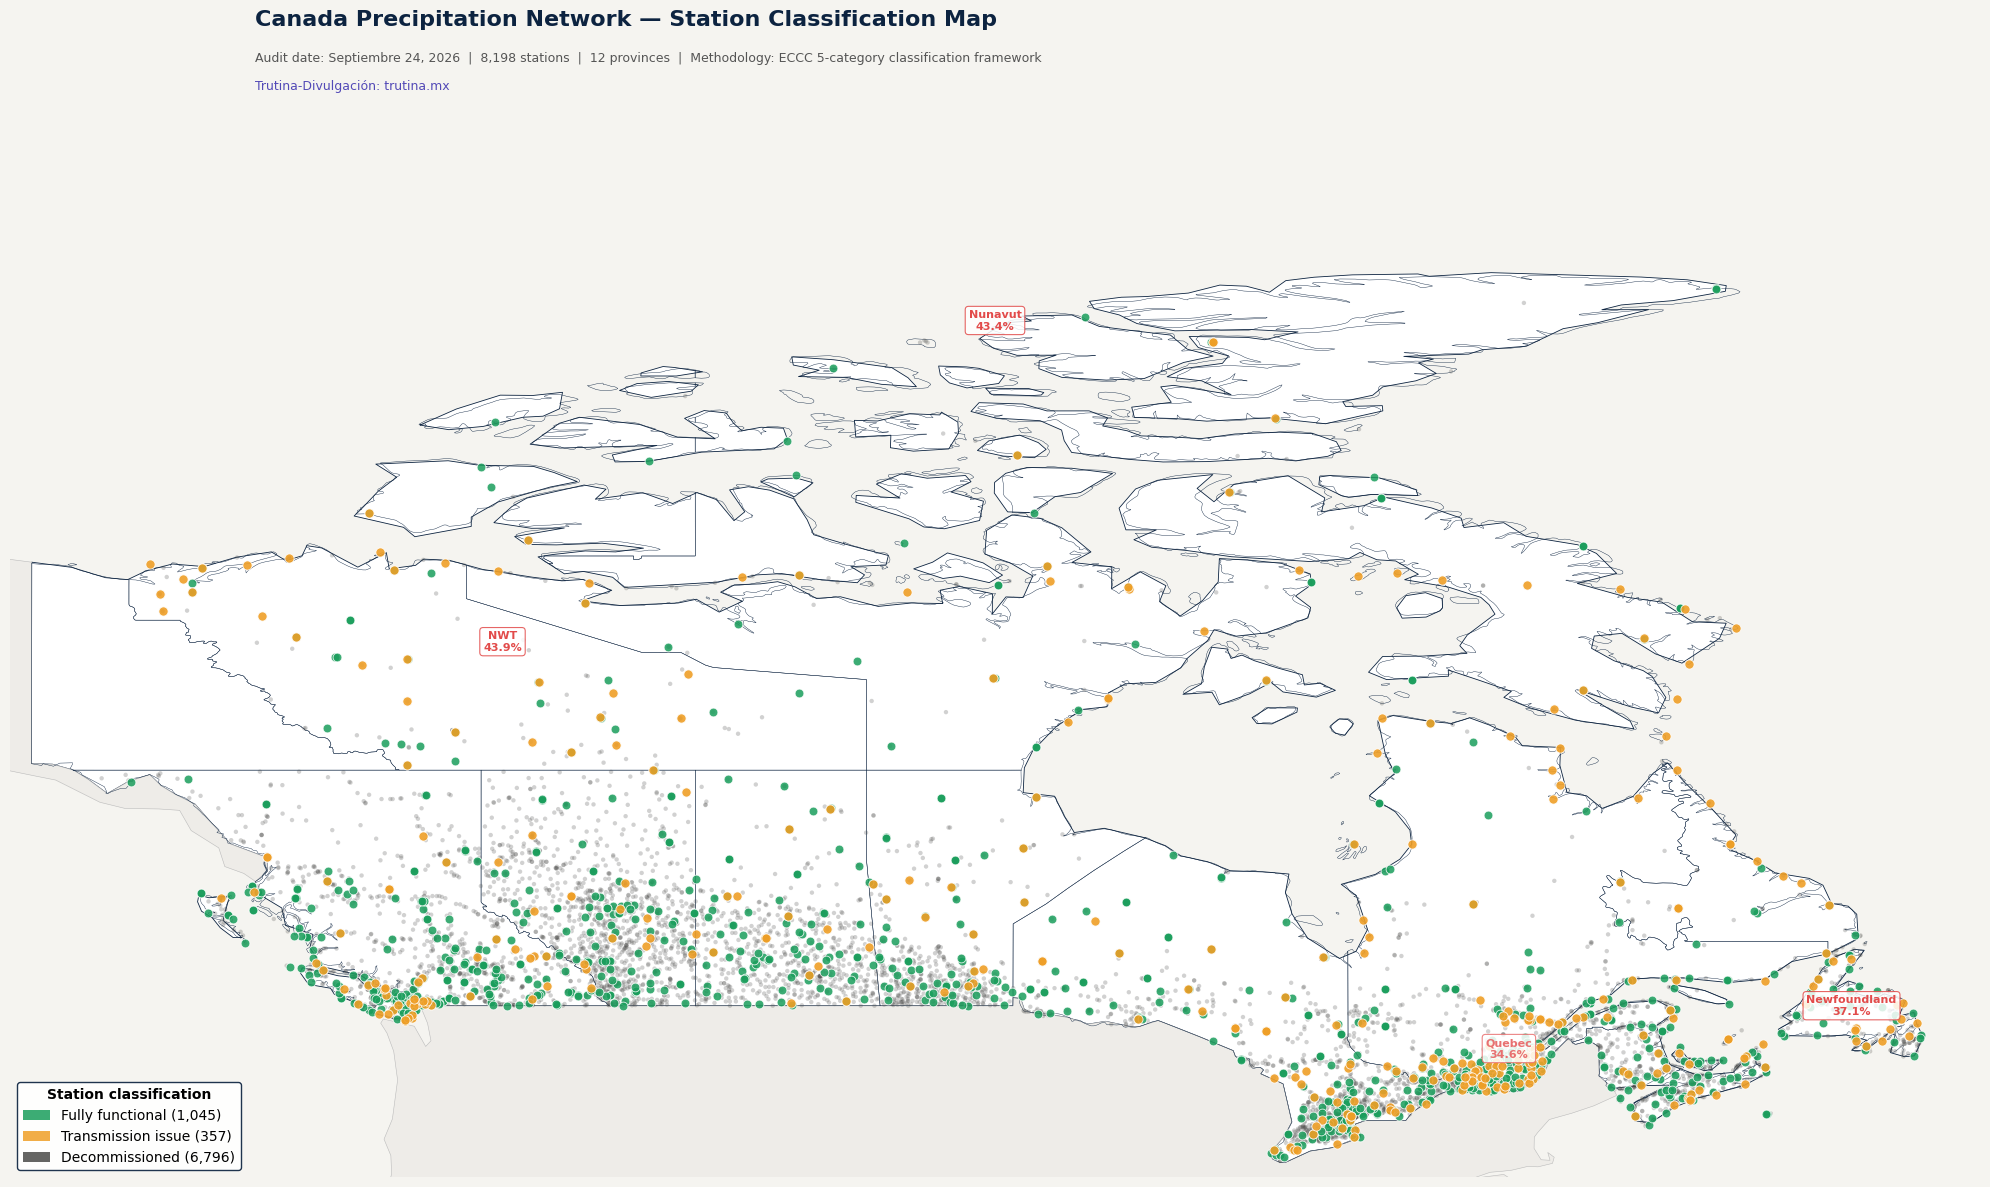

Saved: canada_precipitation_network_map.png (300 DPI)
Saved: canada_precipitation_network_map.pdf (vector, for PDF report embedding)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install geopandas matplotlib mapclassify --quiet
!pip install geodatasets --quiet   # provides Natural Earth shapes
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── 1. Load station data into a GeoDataFrame ──────────────────────────────
df = pd.DataFrame(stations)

# Filter to valid Canadian bounding box
df = df[
    (df['lat'].between(41, 84)) &
    (df['lon'].between(-141, -52))
].copy()

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
)

# ── 2. Load Natural Earth basemap — direct download ───────────────────────
import urllib.request, zipfile, io

def fetch_ne(url):
    resp = urllib.request.urlopen(url, timeout=30)
    data = io.BytesIO(resp.read())
    return gpd.read_file(data)

countries = fetch_ne('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
canada    = countries[countries['NAME'] == 'Canada']
usa       = countries[countries['NAME'] == 'United States of America']


# ── 3. Define colour palette (matches your report design system) ──────────
COLOURS = {
    'ACTIVE_FUNCTIONAL':         '#1a9e5c',   # functional green
    'ACTIVE_TRANSMISSION_ISSUE': '#EF9F27',   # signal amber
    'ACTIVE_DATA_MISSING':       '#E24B4A',   # alert red
    'NO_PRECIP_SENSOR':          '#534AB7',   # borealis violet
    'DECOMMISSIONED':            '#4A4A48',   # archive grey
    'UNKNOWN':                   '#CCCCCC',
}

SIZES = {
    'ACTIVE_FUNCTIONAL':         40,
    'ACTIVE_TRANSMISSION_ISSUE': 44,
    'ACTIVE_DATA_MISSING':       44,
    'NO_PRECIP_SENSOR':          36,
    'DECOMMISSIONED':            10,   # small and receded
    'UNKNOWN':                   10,
}

ALPHAS = {
    'ACTIVE_FUNCTIONAL':         0.85,
    'ACTIVE_TRANSMISSION_ISSUE': 0.90,
    'ACTIVE_DATA_MISSING':       0.90,
    'NO_PRECIP_SENSOR':          0.85,
    'DECOMMISSIONED':            0.25,   # recede into background
    'UNKNOWN':                   0.40,
}

ZORDERS = {
    'DECOMMISSIONED':            1,
    'ACTIVE_FUNCTIONAL':         3,
    'ACTIVE_TRANSMISSION_ISSUE': 4,
    'ACTIVE_DATA_MISSING':       5,
    'NO_PRECIP_SENSOR':          4,
    'UNKNOWN':                   2,
}

# ── 4. Set up figure ───────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(20, 14))
fig.patch.set_facecolor('#F5F4F0')       # glacier white
ax.set_facecolor('#D6E8F0')             # subtle ocean blue

# ── 5. Draw basemap ────────────────────────────────────────────────────────
canada.to_crs('EPSG:4326').plot(
    ax=ax, color='#FFFFFF', edgecolor='#0C2340',
    linewidth=0.6, zorder=0
)
usa.to_crs('EPSG:4326').plot(
    ax=ax, color='#EEECE8', edgecolor='#BBBBBB',
    linewidth=0.4, zorder=0
)

# Province boundaries — download once from Natural Earth
try:
    provinces   = fetch_ne('https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces.zip')
    ca_provinces = provinces[provinces['iso_a2'] == 'CA']
    ca_provinces.plot(
        ax=ax, color='none', edgecolor='#0C2340',
        linewidth=0.3, zorder=1
    )
except Exception as e:
    print(f"Province boundaries skipped: {e}")

# ── 6. Plot stations by classification ────────────────────────────────────
# Plot decommissioned first (bottom layer), then active on top
plot_order = [
    'DECOMMISSIONED',
    'UNKNOWN',
    'NO_PRECIP_SENSOR',
    'ACTIVE_FUNCTIONAL',
    'ACTIVE_TRANSMISSION_ISSUE',
    'ACTIVE_DATA_MISSING',
]

for cls in plot_order:
    subset = gdf[gdf['classification'] == cls]
    if len(subset) == 0:
        continue
    is_active = cls not in ('DECOMMISSIONED', 'UNKNOWN')
    subset.plot(
        ax=ax,
        color=COLOURS[cls],
        markersize=SIZES[cls],
        alpha=ALPHAS[cls],
        zorder=ZORDERS[cls],
        linewidths=0.6 if is_active else 0,
        edgecolors='white' if is_active else 'none',
    )

# ── 7. Set map extent to Canada ────────────────────────────────────────────
ax.set_xlim(-142, -50)
ax.set_ylim(41, 84)
ax.set_aspect('equal')
ax.axis('off')

# ── 8. Legend (counts + colours derived from the data actually plotted) ─────
_n = gdf['classification'].value_counts()
legend_items = [
    (f"Fully functional ({_n.get('ACTIVE_FUNCTIONAL', 0):,})",           COLOURS['ACTIVE_FUNCTIONAL'], 7),
    (f"Transmission issue ({_n.get('ACTIVE_TRANSMISSION_ISSUE', 0):,})", COLOURS['ACTIVE_TRANSMISSION_ISSUE'], 7),
    (f"Decommissioned ({_n.get('DECOMMISSIONED', 0):,})",                COLOURS['DECOMMISSIONED'], 5),
]

patches = [
    mpatches.Patch(facecolor=c, label=label, alpha=0.85)
    for label, c, _ in legend_items
]

legend = ax.legend(
    handles=patches,
    loc='lower left',
    fontsize=10,
    frameon=True,
    framealpha=0.92,
    facecolor='#FFFFFF',
    edgecolor='#0C2340',
    title='Station classification',
    title_fontsize=10,
)
legend.get_title().set_fontweight('bold')

# ── 9. Title block and annotations ────────────────────────────────────────
fig.text(0.13, 0.95,
         'Canada Precipitation Network — Station Classification Map',
         fontsize=16, fontweight='600', color='#0C2340',
         ha='left', va='top')

_n_prov = gdf['province'].nunique() if 'province' in gdf.columns else 12
fig.text(0.13, 0.92,
         f'Audit date: Septiembre 24, 2026  |  {len(gdf):,} stations  |  {_n_prov} provinces  |  '
         'Methodology: ECCC 5-category classification framework',
         fontsize=9, color='#555555', ha='left', va='top')

fig.text(0.13, 0.90,
         'Trutina-Divulgación: trutina.mx',
         fontsize=9, fontweight='500', color='#534AB7',
         ha='left', va='top')

# Thin rule under title
ax.annotate('', xy=(0.87, 0.965), xytext=(0.13, 0.965),
            xycoords='figure fraction',
            arrowprops=dict(arrowstyle='-',
                            color='#534AB7', lw=1.0))

# ── 10. Failure rate callout boxes ─────────────────────────────────────────
callouts = [
    (-96, 81,  'Nunavut\n43.4%',   '#E24B4A'),
    (-119, 66, 'NWT\n43.9%',       '#E24B4A'),
    (-56,  49, 'Newfoundland\n37.1%', '#E24B4A'),
    (-72,  47, 'Quebec\n34.6%',    '#E87070'),
]

for lon, lat, label, color in callouts:
    ax.annotate(
        label,
        xy=(lon, lat), xytext=(lon, lat),
        fontsize=8, color=color,
        fontweight='600',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor=color,
                  alpha=0.85, linewidth=0.8),
        zorder=10,
    )

# ── 11. Export ─────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.89])

plt.savefig('canada_precipitation_network_map.png',
            dpi=300, bbox_inches='tight',
            facecolor=fig.get_facecolor())

plt.savefig('canada_precipitation_network_map.pdf',
            bbox_inches='tight',
            facecolor=fig.get_facecolor())

plt.show()
print("Saved: canada_precipitation_network_map.png (300 DPI)")
print("Saved: canada_precipitation_network_map.pdf (vector, for PDF report embedding)")

from google.colab import files
files.download('canada_precipitation_network_map.png')
files.download('canada_precipitation_network_map.pdf')

# IMAGENES PARA LINKEDIN POSTS

In [ ]:
# ============================================================================
# SHARED SETUP — loads both audits, computes the comparison. Run this first.
# ============================================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- EDIT to point at your two unzipped audit folders ---
JULY_CSV = '/content/station_classification_results.csv'
SEPT_CSV = 'precipitation_audit_v2/reports/station_classification_results.csv'

jul = pd.read_csv(JULY_CSV)
sep = pd.read_csv(SEPT_CSV)

CATS   = ['ACTIVE_FUNCTIONAL', 'ACTIVE_TRANSMISSION_ISSUE', 'DECOMMISSIONED']
LABELS = {'ACTIVE_FUNCTIONAL': 'Functional',
          'ACTIVE_TRANSMISSION_ISSUE': 'Transmission\nissue',
          'DECOMMISSIONED': 'Decommissioned'}

j = jul[['Station_ID','Province','Classification']].rename(columns={'Classification':'Jul'})
s = sep[['Station_ID','Classification']].rename(columns={'Classification':'Sep'})
m = j.merge(s, on='Station_ID', how='outer', indicator=True)

both     = m[m['_merge'] == 'both']
left_ids = set(m[m['_merge'] == 'left_only']['Station_ID'])   # left the inventory
ent_ids  = set(m[m['_merge'] == 'right_only']['Station_ID'])  # entered
n_both, n_left, n_entered = len(both), len(left_ids), len(ent_ids)

# transition matrix over stations present in BOTH audits
TM = (pd.crosstab(both['Jul'], both['Sep'])
        .reindex(index=CATS, columns=CATS, fill_value=0))
print(TM, f"\n\nboth={n_both}  left={n_left}  entered={n_entered}")

# ── shared design system (Trutina-Divulgación) ──
BG, INK, MUTED, VIOLET = '#F5F4F0', '#0C2340', '#5A6B7A', '#534AB7'
GREEN, AMBER, GREY, RED, CELL_OFF = '#1a9e5c', '#EF9F27', '#4A4A48', '#E24B4A', '#E7E9EC'
def F(sz, w='normal'): return fm.FontProperties(family='DejaVu Sans', size=sz, weight=w)
ATTR = ('Adrián Hernández-del-Valle, PhD   ·   Canadian Weather-Station Audit   ·   '
        'Trutina-Divulgación · trutina.mx')

def save_and_download(fig, stem):
    png, pdf = f'{stem}.png', f'{stem}.pdf'
    fig.savefig(png, dpi=300, facecolor=BG, bbox_inches='tight')
    fig.savefig(pdf, facecolor=BG, bbox_inches='tight')
    print(f'Saved: {png} (300 DPI) + {pdf} (vector)')
    try:
        from google.colab import files
        files.download(png); files.download(pdf)
    except Exception:
        pass

Sep                        ACTIVE_FUNCTIONAL  ACTIVE_TRANSMISSION_ISSUE  \
Jul                                                                       
ACTIVE_FUNCTIONAL                       1045                          0   
ACTIVE_TRANSMISSION_ISSUE                  0                        356   
DECOMMISSIONED                             0                          0   

Sep                        DECOMMISSIONED  
Jul                                        
ACTIVE_FUNCTIONAL                       0  
ACTIVE_TRANSMISSION_ISSUE               0  
DECOMMISSIONED                       6796   

both=8197  left=136  entered=1


Saved: fig1_transition_matrix_jul_sep.png (300 DPI) + fig1_transition_matrix_jul_sep.pdf (vector)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

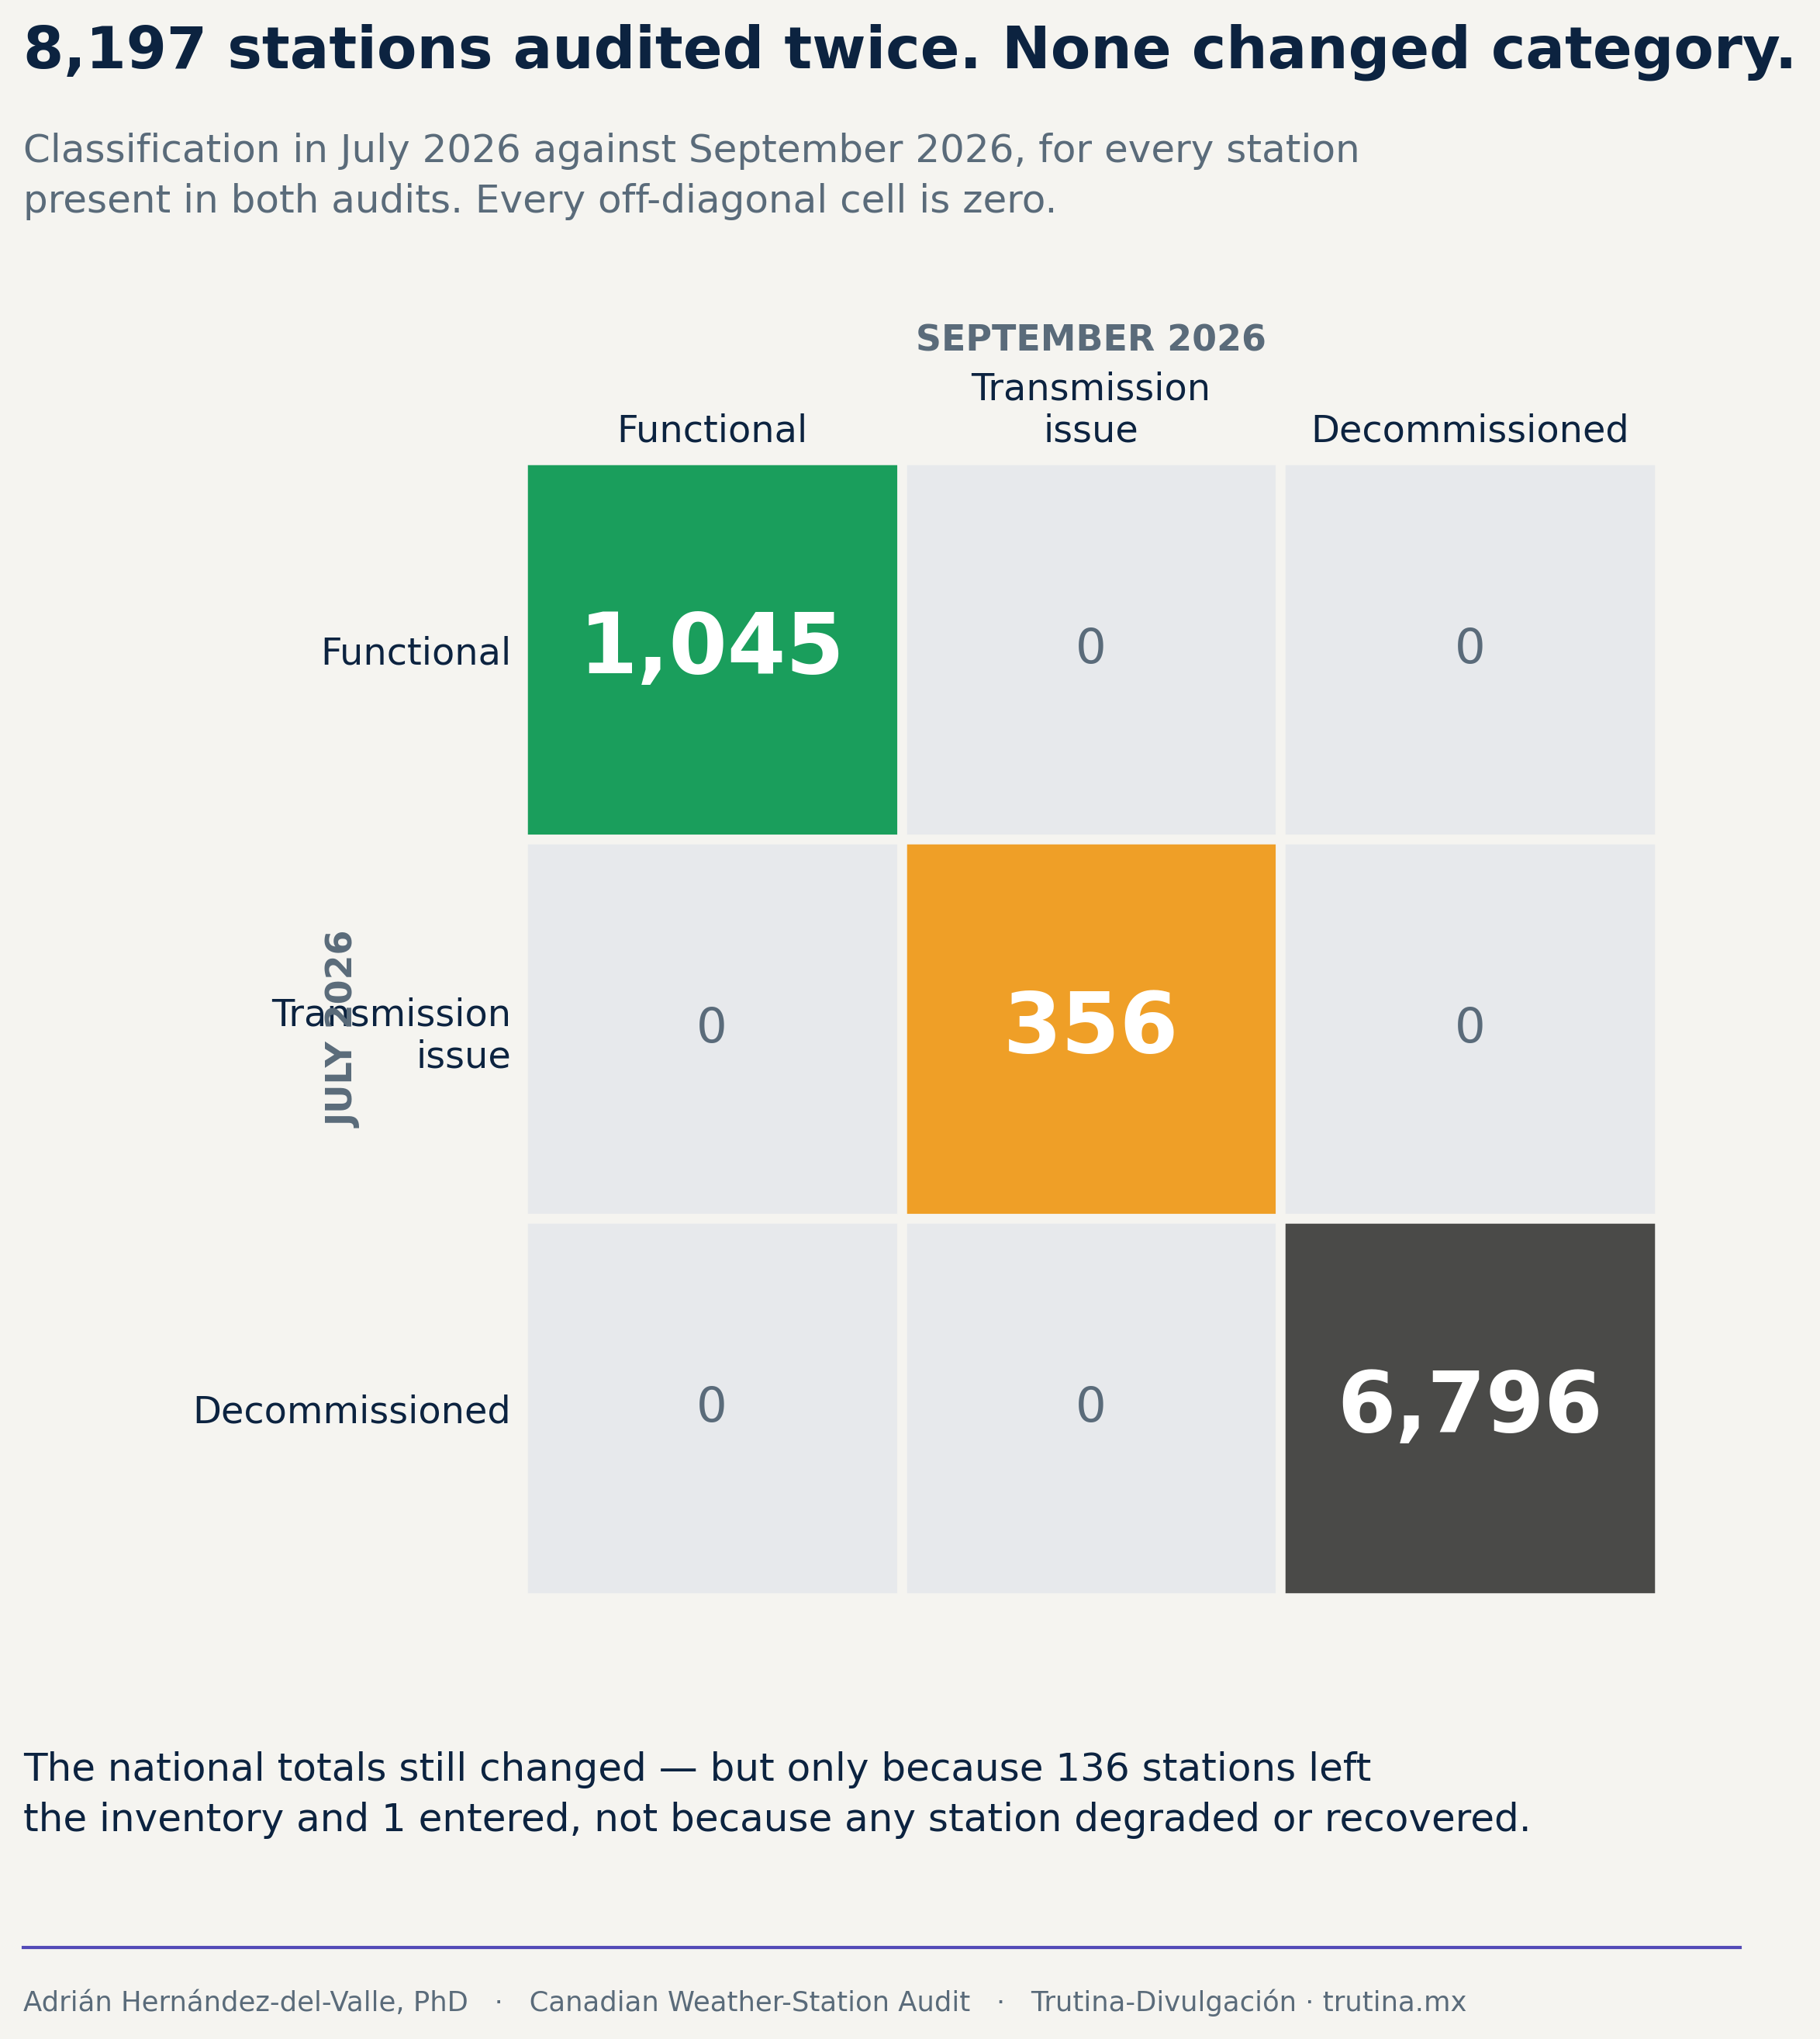

In [ ]:
DIAG = {'ACTIVE_FUNCTIONAL': GREEN, 'ACTIVE_TRANSMISSION_ISSUE': AMBER, 'DECOMMISSIONED': GREY}

fig = plt.figure(figsize=(9, 9.4), dpi=300); fig.patch.set_facecolor(BG)

fig.text(0.09, 0.955, f"{n_both:,} stations audited twice. None changed category.",
         fontproperties=F(18, 'bold'), color=INK, va='top')
fig.text(0.09, 0.905,
         "Classification in July 2026 against September 2026, for every station\n"
         "present in both audits. Every off-diagonal cell is zero.",
         fontproperties=F(12), color=MUTED, va='top', linespacing=1.45)

ax = fig.add_axes([0.30, 0.235, 0.60, 0.52])
for i, rc in enumerate(CATS):
    for k, cc in enumerate(CATS):
        on = (i == k); v = TM.loc[rc, cc]
        ax.add_patch(plt.Rectangle((k-0.5, i-0.5), 1, 1,
                     facecolor=DIAG[rc] if on else CELL_OFF, edgecolor=BG, lw=3))
        ax.text(k, i, f"{v:,}", ha='center', va='center',
                color='white' if on else MUTED,
                fontproperties=F(26 if on else 15, 'bold' if on else 'normal'))
ax.set_xlim(-0.5, 2.5); ax.set_ylim(2.5, -0.5); ax.set_aspect('equal')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([LABELS[c] for c in CATS], fontproperties=F(11.5), color=INK)
ax.set_yticklabels([LABELS[c] for c in CATS], fontproperties=F(11.5), color=INK)
ax.xaxis.set_ticks_position('top'); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)

fig.text(0.60, 0.805, 'SEPTEMBER 2026', ha='center', color=MUTED, fontproperties=F(11, 'bold'))
fig.text(0.235, 0.495, 'JULY 2026', rotation=90, va='center', color=MUTED, fontproperties=F(11, 'bold'))

fig.text(0.09, 0.165,
         f"The national totals still changed — but only because {n_left} stations left\n"
         f"the inventory and {n_entered} entered, not because any station degraded or recovered.",
         fontproperties=F(12), color=INK, va='top', linespacing=1.45)
fig.add_artist(plt.Line2D((0.09, 0.91), (0.075, 0.075), color=VIOLET, lw=1.0, transform=fig.transFigure))
fig.text(0.09, 0.05, ATTR, fontproperties=F(8.5), color=MUTED, va='center')

save_and_download(fig, 'fig1_transition_matrix_jul_sep')
plt.show()

Saved: fig2_alberta_departed.png (300 DPI) + fig2_alberta_departed.pdf (vector)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

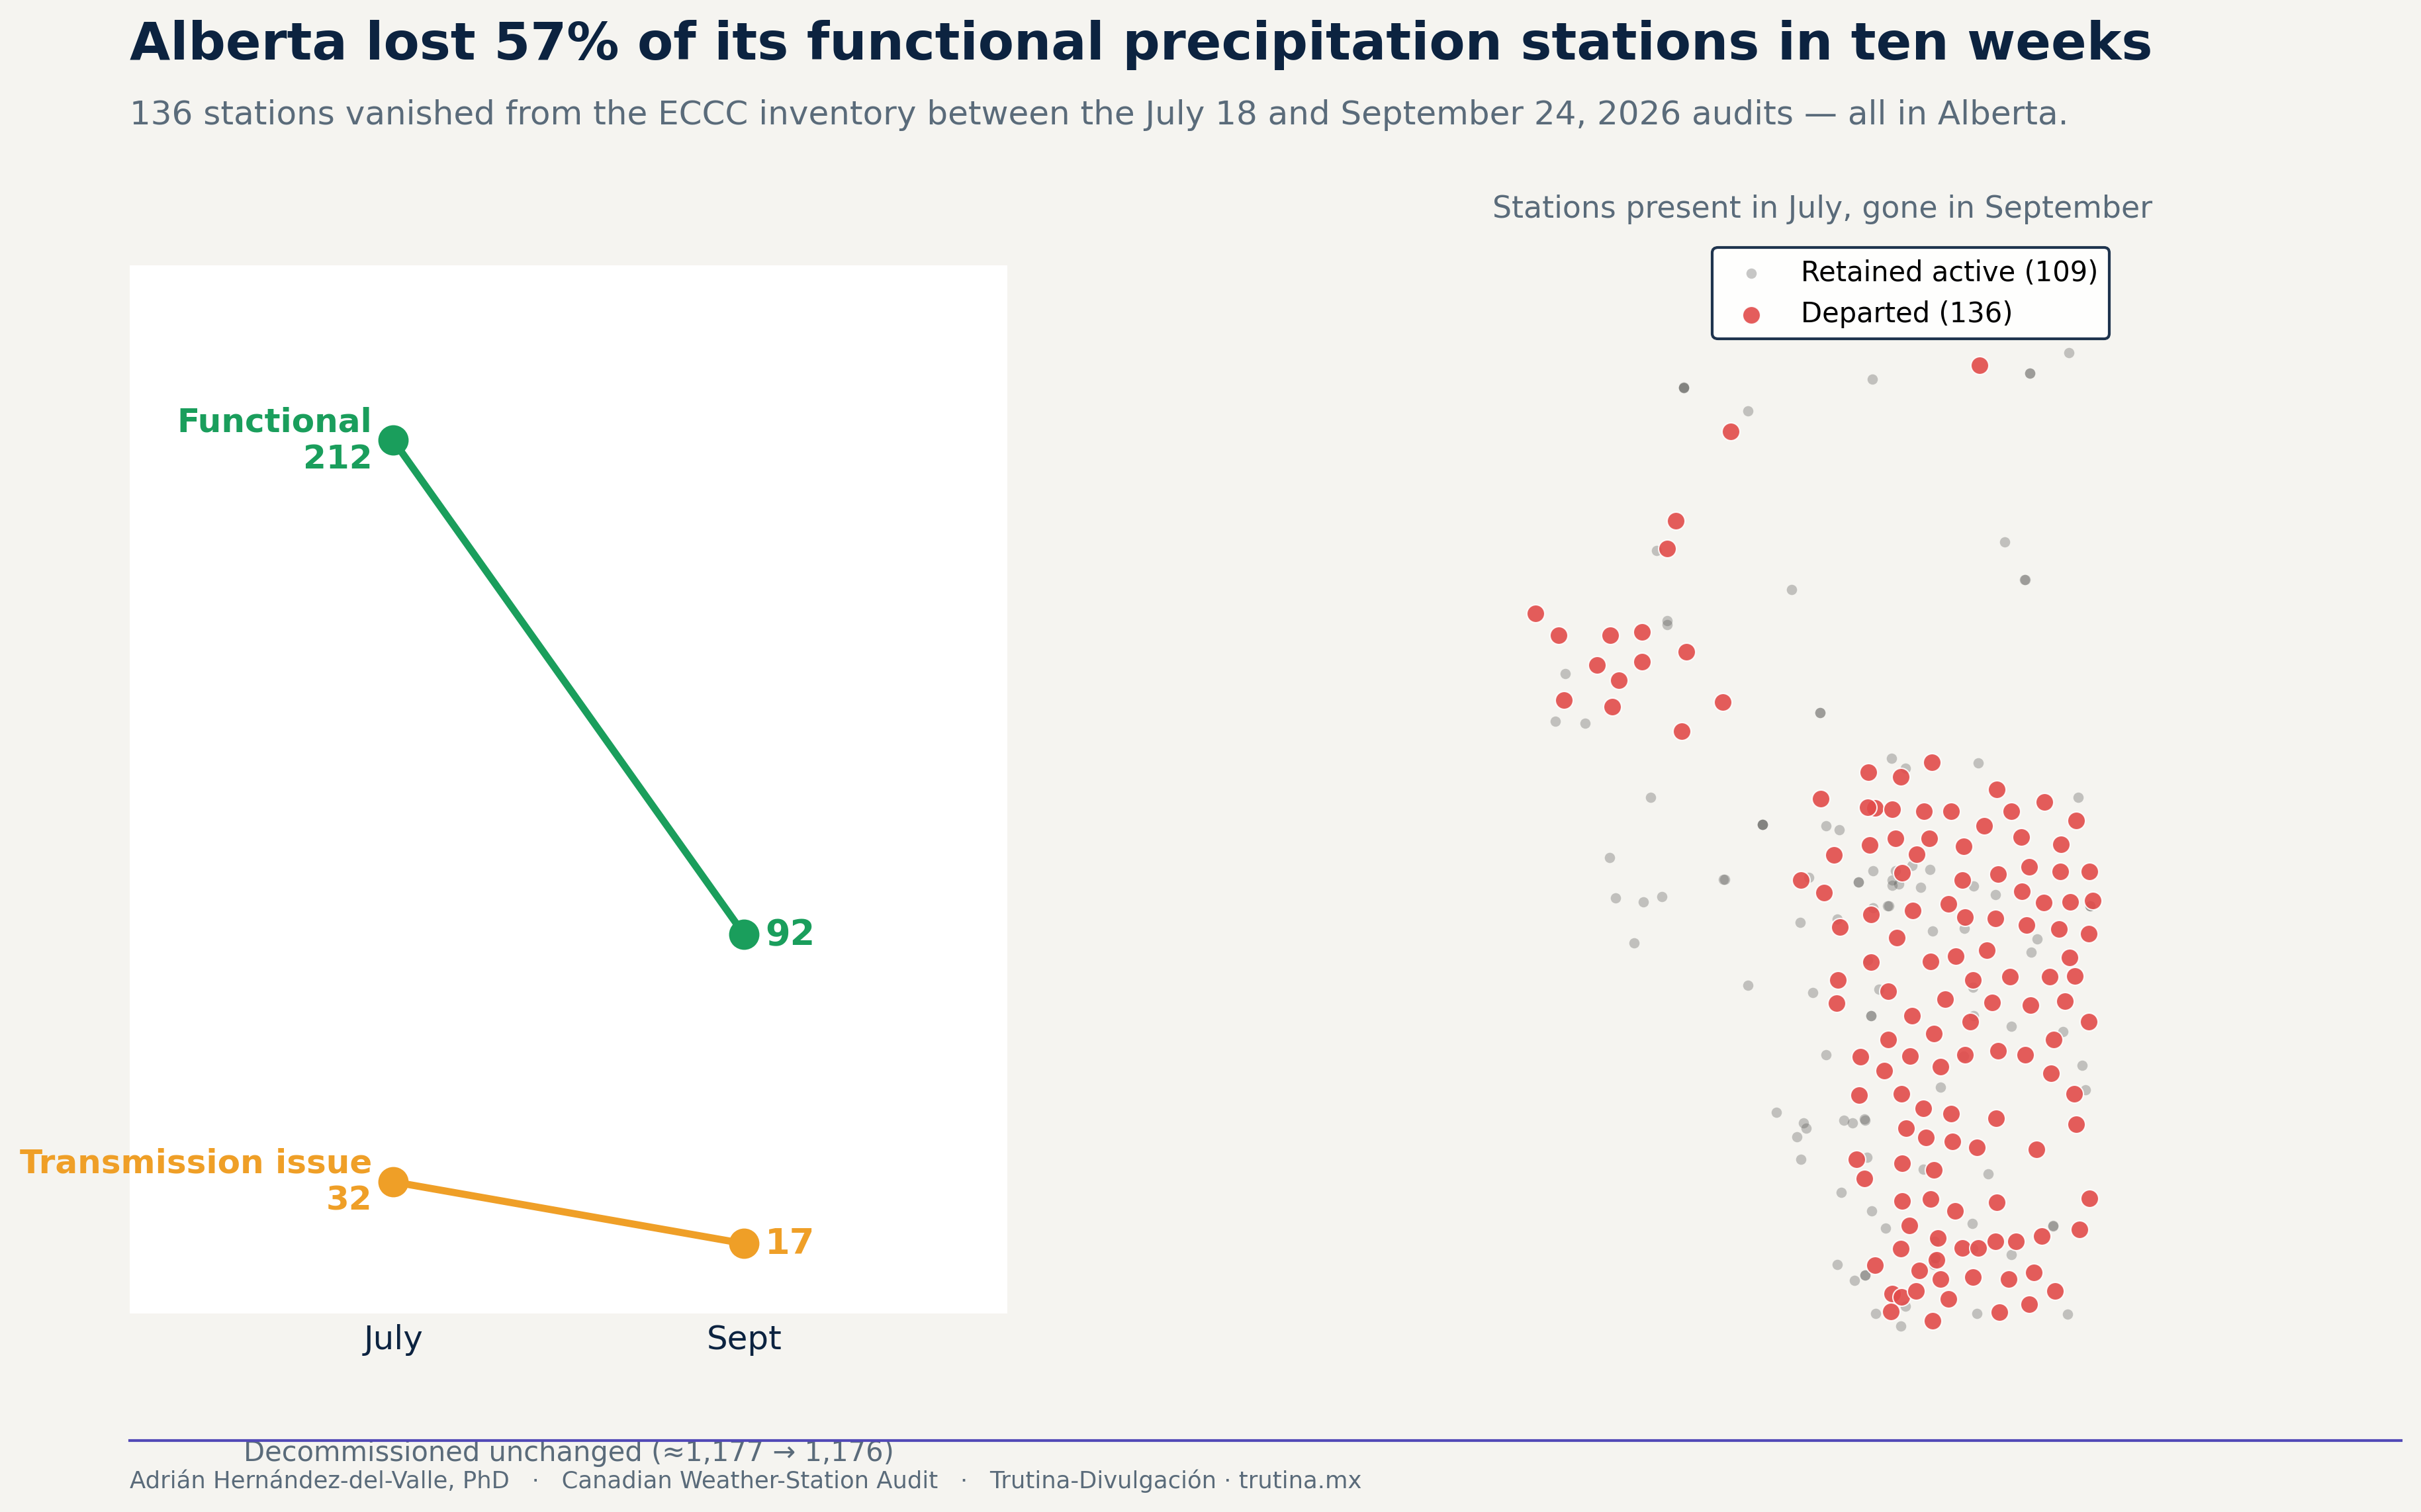

In [ ]:
ab_j = jul[jul['Province'] == 'ALBERTA']['Classification'].value_counts()
ab_s = sep[sep['Province'] == 'ALBERTA']['Classification'].value_counts()
f_j, f_s = int(ab_j.get('ACTIVE_FUNCTIONAL', 0)), int(ab_s.get('ACTIVE_FUNCTIONAL', 0))
t_j, t_s = int(ab_j.get('ACTIVE_TRANSMISSION_ISSUE', 0)), int(ab_s.get('ACTIVE_TRANSMISSION_ISSUE', 0))
pct = round((f_j - f_s) / f_j * 100)

ab = jul[jul['Province'] == 'ALBERTA'].copy()
ab['left'] = ab['Station_ID'].isin(left_ids)
dep = ab[ab['left']].dropna(subset=['Latitude', 'Longitude'])
ret = ab[~ab['left'] & ab['Classification'].isin(CATS[:2])].dropna(subset=['Latitude', 'Longitude'])

fig = plt.figure(figsize=(13, 8), dpi=300); fig.patch.set_facecolor(BG)
fig.text(0.06, 0.955,
         f"Alberta lost {pct}% of its functional precipitation stations in ten weeks",
         fontproperties=F(19, 'bold'), color=INK, va='top')
fig.text(0.06, 0.905,
         f"{n_left} stations vanished from the ECCC inventory between the July 18 and "
         f"September 24, 2026 audits — all in Alberta.",
         fontproperties=F(12), color=MUTED, va='top')

# --- left: slope chart (active network) ---
ax1 = fig.add_axes([0.06, 0.14, 0.34, 0.66])
for v0, v1, color, name in [(f_j, f_s, GREEN, 'Functional'),
                            (t_j, t_s, AMBER, 'Transmission issue')]:
    ax1.plot([0, 1], [v0, v1], color=color, lw=2.6, marker='o', ms=10, zorder=3)
    ax1.text(-0.06, v0, f"{name}\n{v0}", ha='right', va='center',
             fontproperties=F(12, 'bold'), color=color)
    ax1.text(1.06, v1, f"{v1}", ha='left', va='center',
             fontproperties=F(13, 'bold'), color=color)
ax1.set_xlim(-0.75, 1.75); ax1.set_ylim(0, max(f_j, t_j) * 1.2)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['July', 'Sept'], fontproperties=F(12), color=INK)
ax1.set_yticks([]);
for sp in ax1.spines.values(): sp.set_visible(False)
ax1.tick_params(length=0)
ax1.text(0.5, -0.14, 'Decommissioned unchanged (≈1,177 → 1,176)',
         transform=ax1.transAxes, ha='center', fontproperties=F(10), color=MUTED)

# --- right: map of departed vs retained active stations ---
ax2 = fig.add_axes([0.46, 0.12, 0.50, 0.70])
ax2.scatter(ret['Longitude'], ret['Latitude'], s=14, color=GREY, alpha=0.30,
            linewidths=0, label=f'Retained active ({len(ret)})', zorder=2)
ax2.scatter(dep['Longitude'], dep['Latitude'], s=42, color=RED, alpha=0.9,
            edgecolors='white', linewidths=0.5, label=f'Departed ({len(dep)})', zorder=3)
ax2.set_xlim(-120.5, -109.5); ax2.set_ylim(48.8, 60.2)
ax2.set_aspect(1 / np.cos(np.radians(54)))
ax2.axis('off')
ax2.legend(loc='upper right', fontsize=10, frameon=True, framealpha=0.92,
           facecolor='#FFFFFF', edgecolor=INK)
ax2.set_title('Stations present in July, gone in September',
              fontproperties=F(11), color=MUTED, loc='left')

fig.add_artist(plt.Line2D((0.06, 0.94), (0.06, 0.06), color=VIOLET, lw=1.0, transform=fig.transFigure))
fig.text(0.06, 0.035, ATTR, fontproperties=F(8.5), color=MUTED, va='center')

save_and_download(fig, 'fig2_alberta_departed')
plt.show()

In [ ]:
"""
Canadian Weather-Station Audit — three LinkedIn visuals.
Corrected build: text extents are MEASURED via the renderer, not estimated.

Output: 1080 x 1350 px PNG x3
"""
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
import textwrap
import numpy as np

# ── canvas ────────────────────────────────────────────────────────────
DPI, W_PX, H_PX = 150, 1080, 1350
FIGSIZE = (W_PX / DPI, H_PX / DPI)

L, R = 0.075, 0.925          # content margins (figure coords)
TOP = 0.962                  # flow starts here  (was 0.92 — too low)
ATTR_Y, RULE_Y = 0.030, 0.048
SOURCE_GAP = 0.030           # min clearance between body and source note

ATTRIBUTION = ("Adrián Hernández-del-Valle, PhD  |  "
               "Canadian Weather-Station Audit  |  July 2026")

# ── palette ───────────────────────────────────────────────────────────
INK, MUTED, RULE = "#12212E", "#5A6B7A", "#D8DEE4"
ACCENT, STEADY, NEUTRAL, CELL, WHITE = "#B23A34", "#2E6B52", "#9AA7B2", "#EDF1F4", "#FFFFFF"

# ── type ──────────────────────────────────────────────────────────────
def _f(size, weight="normal"):
    return fm.FontProperties(family="DejaVu Sans", weight=weight, size=size)

FONT = {
    "title":      _f(30, "bold"),
    "subtitle":   _f(15.5),
    "body":       _f(15),
    "body_bold":  _f(15, "bold"),
    "body_small": _f(14.5),
    "callout_l":  _f(46, "bold"),
    "callout_s":  _f(28, "bold"),
    "callout_tx": _f(13.5),
    "axis":       _f(13),
    "tick":       _f(12.5),
    "prov":       _f(13),
    "group":      _f(12.5, "bold"),
    "source":     _f(11.5),
    "attr":       _f(10.5),
    "bar_val":    _f(26, "bold"),
    "barh_val":   _f(12.5, "bold"),
    "mtx_on":     _f(24, "bold"),
    "mtx_off":    _f(16),
}


# ── measured text primitives ──────────────────────────────────────────
def _renderer(fig):
    fig.canvas.draw()
    return fig.canvas.get_renderer()


def measure(fig, artist):
    """True [top, bottom] of a text artist in figure fraction."""
    bb = artist.get_window_extent(renderer=_renderer(fig))
    inv = fig.transFigure.inverted()
    (_, y0), (_, y1) = inv.transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
    return max(y0, y1), min(y0, y1)


def text_block(fig, y_top, text, font, colour, wrap=None,
               leading=1.35, x=L, ha="left", gap=0.018, track=None):
    """Draw wrapped text anchored at y_top. Returns measured bottom minus gap."""
    body = textwrap.fill(text, wrap) if wrap else text
    art = fig.text(x, y_top, body, fontproperties=font, color=colour,
                   va="top", ha=ha, linespacing=leading)
    top, bot = measure(fig, art)
    if track is not None:
        track.append((f"text:{body[:28]}", top, bot))
    return bot - gap


def hairline(fig, y, track=None):
    fig.add_artist(plt.Line2D((L, R), (y, y), color=RULE, lw=1.2,
                              transform=fig.transFigure))
    if track is not None:
        track.append(("rule", y + 0.0005, y - 0.0005))
    return y - 0.030


def footer(fig, source, track=None):
    """Pin attribution + rule + source. Returns the floor body must stay above."""
    fig.text(L, ATTR_Y, ATTRIBUTION, fontproperties=FONT["attr"],
             color=NEUTRAL, va="center", ha="left")
    fig.add_artist(plt.Line2D((L, R), (RULE_Y, RULE_Y), color=RULE, lw=1.2,
                              transform=fig.transFigure))
    art = fig.text(L, RULE_Y + 0.020, textwrap.fill(source, 104),
                   fontproperties=FONT["source"], color=MUTED,
                   va="bottom", ha="left", linespacing=1.42)
    top, bot = measure(fig, art)
    if track is not None:
        track.append(("source", top, bot))
    return top + SOURCE_GAP


def axes_extent(fig, ax, track=None, label=""):
    bb = ax.get_tightbbox(renderer=_renderer(fig))
    inv = fig.transFigure.inverted()
    (_, y0), (_, y1) = inv.transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
    top, bot = max(y0, y1), min(y0, y1)
    if track is not None:
        track.append((f"axes:{label}", top, bot))
    return top, bot


def audit(track, floor, name):
    """Fail loudly on overlap, canvas overrun, or footer intrusion."""
    for lbl, top, bot in track:
        if bot < 0 or top > 1:
            raise ValueError(f"{name}: '{lbl}' off-canvas [{top:.4f},{bot:.4f}]")
        if lbl == "source":
            continue                      # the source note defines the floor
        if bot < floor - 1e-9:
            raise ValueError(f"{name}: '{lbl}' enters footer "
                             f"(bottom {bot:.4f} < floor {floor:.4f})")
    ordered = sorted(track, key=lambda t: t[1], reverse=True)
    for (l1, t1, b1), (l2, t2, b2) in zip(ordered, ordered[1:]):
        if b1 < t2 - 1e-9:
            raise ValueError(f"{name}: '{l1}' overlaps '{l2}' "
                             f"({b1:.4f} < {t2:.4f})")
    print(f"  {name}: {len(track)} elements, no overlap, floor {floor:.4f} clear")


def bare(ax):
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)


def commas(x, _):
    return f"{x:,.0f}"


# ══ IMAGE 1 ═══════════════════════════════════════════════════════════
def image_1(path):
    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor=WHITE)
    T = []
    floor = footer(fig,
        "Source: ECCC station inventory and daily precipitation records, classified using "
        "the five-category framework provided by Environment and Climate Change Canada. "
        "Audits: May 2026 and 17-18 July 2026.", T)

    y = TOP
    y = text_block(fig, y, "44 Alberta stations left the federal inventory in two months",
                   FONT["title"], INK, wrap=30, leading=1.22, gap=0.026, track=T)
    y = text_block(fig, y,
        "Stations present in the May 2026 audit and absent from the July 2026 audit. "
        "42 of the 44 were classified functional in May.",
        FONT["subtitle"], MUTED, wrap=62, leading=1.42, gap=0.044, track=T)

    PH = 0.195
    panels = [(L, (254, 212), "Alberta stations classified functional"),
              (0.545, (103, 72), "Stations carrying the AGCM designation")]
    caps = []
    for x0, vals, cap in panels:
        ax = fig.add_axes([x0, y - PH, 0.38, PH]); bare(ax)
        ax.bar([0, 1], vals, width=0.58, color=[NEUTRAL, ACCENT])
        ax.set_ylim(0, max(vals) * 1.45); ax.set_xlim(-0.62, 1.62)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["May", "July"],
                                                  fontproperties=FONT["axis"], color=INK)
        ax.set_yticks([]); ax.grid(False)
        for xx, v in zip([0, 1], vals):
            ax.text(xx, v + max(vals) * 0.05, f"{v}", ha="center",
                    fontproperties=FONT["bar_val"], color=INK)
        caps.append((x0, cap))
    _, panel_bot = axes_extent(fig, ax, T, "bars")

    cap_y = panel_bot - 0.014
    cap_bot = cap_y
    for x0, cap in caps:
        art = fig.text(x0, cap_y, cap, fontproperties=FONT["tick"],
                       color=MUTED, va="top", ha="left")
        _, cb = measure(fig, art)
        cap_bot = min(cap_bot, cb)
    T.append(("captions", cap_y, cap_bot))

    y = hairline(fig, cap_bot - 0.030, T)

    for tag, txt in [("All 44", "last reported daily data in 2024"),
                     ("31 of 44", "carry the AGCM agricultural designation"),
                     ("38 of 44", "share an identical coverage fingerprint")]:
        a1 = fig.text(L, y, tag, fontproperties=FONT["body_bold"],
                      color=ACCENT, va="top", ha="left")
        a2 = fig.text(0.265, y, txt, fontproperties=FONT["body"],
                      color=INK, va="top", ha="left")
        t1, b1 = measure(fig, a1); t2, b2 = measure(fig, a2)
        T.append((f"fact:{tag}", max(t1, t2), min(b1, b2)))
        y = min(b1, b2) - 0.026

    y = text_block(fig, y - 0.012,
        "An identical fingerprint across 38 stations points to a single "
        "inventory-level change rather than 44 separate closures.",
        FONT["body"], MUTED, wrap=64, leading=1.48, gap=0, track=T)

    audit(T, floor, "image 1")
    fig.savefig(path, dpi=DPI, facecolor=WHITE)
    plt.close(fig)


# ══ IMAGE 2 ═══════════════════════════════════════════════════════════
def image_2(path):
    DATA = [("Nunavut", 44536), ("Northwest Territories", 36381),
            ("Newfoundland and Labrador", 9209), ("Manitoba", 8997),
            ("Quebec", 8159), ("Saskatchewan", 8037), ("Ontario", 6563),
            ("British Columbia", 3920), ("Alberta", 3122),
            ("New Brunswick", 2700), ("Nova Scotia", 1286),
            ("Prince Edward Island", 708)]

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor=WHITE)
    T = []
    floor = footer(fig,
        "Source: ECCC station inventory, July 2026 audit (8,333 stations). Land areas from "
        "Statistics Canada. Newfoundland and Labrador appears as recorded in the ECCC "
        "inventory. Yukon is not included in this audit.", T)

    y = TOP
    y = text_block(fig, y, "One functional station per 44,536 km² in Nunavut",
                   FONT["title"], INK, wrap=30, leading=1.22, gap=0.026, track=T)
    y = text_block(fig, y,
        "Land area divided by the number of stations classified functional, "
        "July 2026. Lower means denser coverage.",
        FONT["subtitle"], MUTED, wrap=62, leading=1.42, gap=0.034, track=T)

    band_top = y
    CH = 0.435
    CX = 0.375                       # chart left edge, clear of callout column
    ax = fig.add_axes([CX, band_top - CH, R - CX, CH]); bare(ax)

    names = [d[0] for d in DATA][::-1]
    vals = [d[1] for d in DATA][::-1]
    cols = [ACCENT if v > 30000 else (NEUTRAL if v > 5000 else STEADY) for v in vals]
    ax.barh(range(len(vals)), vals, color=cols, height=0.66)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontproperties=FONT["prov"], color=INK)
    ax.set_xscale("log"); ax.set_xlim(500, 200000)
    ax.set_xticks([1000, 10000, 100000])
    ax.xaxis.set_major_formatter(FuncFormatter(commas))
    ax.tick_params(axis="x", labelsize=FONT["tick"].get_size(), colors=MUTED)
    ax.set_ylim(-0.7, len(vals) - 0.3)
    ax.xaxis.grid(True, color=RULE, lw=0.9); ax.set_axisbelow(True)
    for i, v in enumerate(vals):
        ax.text(v * 1.14, i, f"{v:,}", va="center",
                fontproperties=FONT["barh_val"], color=INK)
    _, chart_bot = axes_extent(fig, ax, T, "bars")

    # callout column — own vertical flow, horizontally disjoint from chart
    cy = band_top - 0.010
    a = fig.text(L, cy, "63×", fontproperties=FONT["callout_l"],
                 color=ACCENT, va="top", ha="left")
    ct, cb = measure(fig, a)
    a2 = fig.text(L, cb - 0.014,
                  textwrap.fill("the area per functional station in Nunavut "
                                "versus Prince Edward Island", 20),
                  fontproperties=FONT["callout_tx"], color=MUTED,
                  va="top", ha="left", linespacing=1.50)
    _, cb2 = measure(fig, a2)
    T.append(("callout-1", ct, cb2))

    cy = cb2 - 0.055
    a3 = fig.text(L, cy, "44.9%", fontproperties=FONT["callout_s"],
                  color=ACCENT, va="top", ha="left")
    c3t, c3b = measure(fig, a3)
    a4 = fig.text(L, c3b - 0.012,
                  textwrap.fill("of active stations above 60°N show transmission "
                                "issues, versus 21.8% below", 20),
                  fontproperties=FONT["callout_tx"], color=MUTED,
                  va="top", ha="left", linespacing=1.50)
    _, c4b = measure(fig, a4)
    T.append(("callout-2", c3t, c4b))

    cap = fig.text(CX, chart_bot - 0.022,
                   "km² per functional station  (logarithmic scale)",
                   fontproperties=FONT["axis"], color=MUTED, va="top", ha="left")
    T.append(("axis caption", *measure(fig, cap)))

    # callouts and chart share a vertical band; audit them separately
    band = [t for t in T if t[0].startswith("callout")]
    T = [t for t in T if not t[0].startswith("callout")]
    audit(T, floor, "image 2 (chart column)")
    audit(band + [("floor-probe", floor + 0.001, floor + 0.001)],
          floor, "image 2 (callout column)")

    fig.savefig(path, dpi=DPI, facecolor=WHITE)
    plt.close(fig)


# ══ IMAGE 3 ═══════════════════════════════════════════════════════════
def image_3(path):
    M = np.array([[1165, 0, 0], [0, 368, 0], [0, 0, 6797]])
    CATS = ["Functional", "Transmission\nissue", "Decommissioned"]

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor=WHITE)
    T = []
    floor = footer(fig,
        "Source: ECCC daily precipitation records, classified using the five-category "
        "framework provided by Environment and Climate Change Canada. Excludes 44 stations "
        "present only in May and 3 present only in July.", T)

    y = TOP
    y = text_block(fig, y, "8,330 stations audited twice. None changed category.",
                   FONT["title"], INK, wrap=30, leading=1.22, gap=0.026, track=T)
    y = text_block(fig, y,
        "Classification in May 2026 against classification in July 2026, "
        "for every station present in both audits.",
        FONT["subtitle"], MUTED, wrap=62, leading=1.42, gap=0.040, track=T)

    # reserve a line for the group header; its exact y is set after the
    # matrix bbox (which includes column tick labels) has been measured
    HEADER_LINE = 0.042
    y -= HEADER_LINE

    MH = 0.278
    ax = fig.add_axes([0.345, y - MH, R - 0.345, MH])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(2.5, -0.5)
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(CATS, fontproperties=FONT["tick"], color=INK)
    ax.set_yticklabels(CATS, fontproperties=FONT["tick"], color=INK)
    ax.tick_params(length=0)
    ax.xaxis.set_ticks_position("top")

    for i in range(3):
        for j in range(3):
            on = (i == j)                      # colour by POSITION, not value
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         facecolor=STEADY if on else CELL,
                         edgecolor=WHITE, lw=2.5))
            ax.text(j, i, f"{M[i, j]:,}" if on else "0",
                    ha="center", va="center",
                    fontproperties=FONT["mtx_on"] if on else FONT["mtx_off"],
                    color=WHITE if on else NEUTRAL)
    mt, mb = axes_extent(fig, ax, T, "matrix")

    grp = fig.text(0.345, mt + 0.012, "JULY 2026", fontproperties=FONT["group"],
                   color=MUTED, va="bottom", ha="left")
    T.append(("group JULY", *measure(fig, grp)))

    fig.text(0.088, (mt + mb) / 2, "MAY 2026", fontproperties=FONT["group"],
             color=MUTED, rotation=90, va="center", ha="center")

    y = hairline(fig, mb - 0.040, T)
    y = text_block(fig, y,
        "Every off-diagonal cell is zero. No station moved between categories "
        "in either direction over the two-month interval.",
        FONT["body"], INK, wrap=58, leading=1.48, gap=0.026, track=T)
    y = text_block(fig, y,
        "The national totals still changed, but only because 44 stations left the "
        "inventory and 3 entered it, not because any station degraded or recovered.",
        FONT["body_small"], MUTED, wrap=64, leading=1.48, gap=0, track=T)

    audit(T, floor, "image 3")
    fig.savefig(path, dpi=DPI, facecolor=WHITE)
    plt.close(fig)


if __name__ == "__main__":
    import os
    out = "."                       # Colab working directory
    os.makedirs(out, exist_ok=True)
    image_1(f"{out}/01_alberta_44_stations.png")
    image_2(f"{out}/02_area_per_functional_station.png")
    image_3(f"{out}/03_transition_matrix.png")
    print("all three written")

  image 1: 10 elements, no overlap, floor 0.1395 clear
  image 2 (chart column): 5 elements, no overlap, floor 0.1632 clear
  image 2 (callout column): 3 elements, no overlap, floor 0.1632 clear
  image 3: 8 elements, no overlap, floor 0.1632 clear
all three written
